# Проект: Обзор бизнес-показателей маркетплейса

## Введение

В проекте проведена аналитика быстрорастущего маркетплейса, который уже нашёл свою нишу, начал приносить прибыль. Выручка маркетплейса = 5% от total_price.
До недавнего времени здесь обходились отчётами в Excel, ориентировались на бухгалтерские сводки и интуицию. Но бизнес растёт, и стало понятно, что нужна продуктовая аналитика.

Команда хочет понять, как чувствует себя продукт: кто приходит, кто остаётся, кто платит, кто уходит. А ещё: на каких каналах держится рост, какие категории товаров приносят деньги, а какие висят мёртвым грузом.

### Цель проекта: выявить перспективные и убыточные каналы

Для данного проекта ключевой метрикой будет Выручка (Revenue)

**Построим дерево метрик** чтобы видеть какие метрики влияют на Выручку

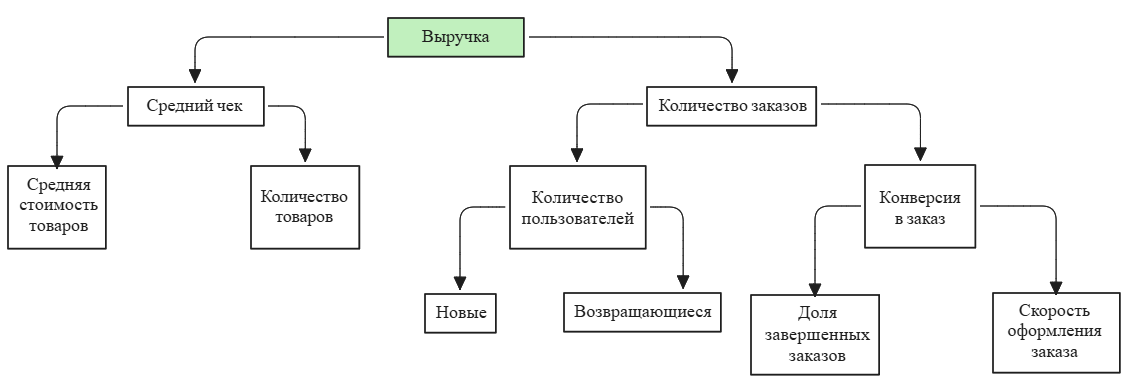

# Описание данных

Загружаем необходимые библиотеки

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import ttest_ind
from scipy.stats import mannwhitneyu

**Формируем датафреймы из csv-файлов.**

In [ ]:
pa_diploma_orders = pd.read_csv('https://.......pa_diploma_orders.csv')
pa_diploma_campaign_costs = pd.read_csv('https://......./pa_diploma_campaign_costs.csv')
pa_diploma_sessions = pd.read_csv('https://......./pa_diploma_sessions.csv')
pa_diploma_users = pd.read_csv('https://......./pa_diploma_users.csv')
pa_diploma_events = pd.read_csv('https://......./pa_diploma_events.csv')

**Выводим основную информацию и проверяем наличие пропусков и дубликатов в датафреймах**

In [ ]:
# Запишем базовую часть в переменную 
base_url = "https://......."
# Создаем список названий файлов
filenames = ['pa_diploma_orders.csv', 'pa_diploma_campaign_costs.csv', 'pa_diploma_sessions.csv', 'pa_diploma_users.csv', 'pa_diploma_events.csv']
# Создаем список датафреймов
dfs = {file: pd.read_csv(base_url + file) for file in filenames}


def lookup_datasets(dfs, filenames=None):
    """
    Выводит информацию о датасетах из списка

    Parameters:
        dfs (list of pd.DataFrame): Список датафреймов для обработки.
        filenames (list of str): Список названий файлов (имена для отображения).
    """
    if filenames is None:
        filenames = [f"df_{i + 1}" for i in range(len(dfs))]

    for df, df_name in zip(dfs, filenames):
        print('-'*10,' '*5, df_name, ' '*5, '-'*10)

        # Пропущенные значения
        missing_data = df.isna().mean()
        missing_data_result = missing_data.apply(lambda x: f'{x:.2%}' if x > 0 else "")
        missing_data_name = "Пропущено" if missing_data.sum() > 0 else ""
        missing_data_result.name = missing_data_name

        # Типы данных
        dtypes_result = df.dtypes
        dtypes_result.name = "Тип данных колонки"
        fewest_nans_row = df.iloc[1:-1].isna().sum(axis=1).idxmin()

        values_type = df.loc[fewest_nans_row].map(type).T
        values_type.name = "Тип значения"

        # Объединяем результаты и пример данных
        result = pd.concat([
            dtypes_result, # типы
            values_type, # типы значений
            missing_data_result, # пропущенные значения
            df.iloc[0, :], # первая строка
            df.loc[fewest_nans_row].T, # полная строка
            df.iloc[-1, :] # последняя строка
        ], axis=1)

        display(result)

        # Проверка на полные дубликаты
        duplicates = df.duplicated().mean()
        if duplicates > 0:
            print(f'Полных дубликатов: {duplicates:.2%}')

        print()

# Проводим автоматический осмотр данных
column_counts = lookup_datasets(dfs.values(), dfs.keys())

----------       pa_diploma_orders.csv       ----------


,Тип данных колонки,Тип значения,,0,1,31356
order_id,int64,<class 'numpy.int64'>,,1,2,31791
user_id,int64,<class 'numpy.int64'>,,3,3,44906
order_date,object,<class 'str'>,,2024-01-19 01:52:52.000,2024-01-19 01:52:52.000,2024-12-31 18:21:35.000
product_name,object,<class 'str'>,,Шуруповерт,Молоток слесарный,Скраб для тела
quantity,int64,<class 'numpy.int64'>,,2,1,1
unit_price,float64,<class 'numpy.float64'>,,5539.13,11340.38,339.0
total_price,float64,<class 'numpy.float64'>,,11078.26,11340.38,339.0
category_name,object,<class 'str'>,,Инструменты и садовый инвентарь,Инструменты и садовый инвентарь,Средства для ухода
order_week,object,<class 'str'>,,2024-01-15,2024-01-15,2024-12-30
order_month,object,<class 'str'>,,2024-01-01,2024-01-01,2024-12-01



----------       pa_diploma_campaign_costs.csv       ----------


,Тип данных колонки,Тип значения,,0,1,87
Unnamed: 0,int64,<class 'numpy.int64'>,,0,1,87
acq_channel,object,<class 'str'>,,Affiliate,Affiliate,TikTok
spend_month,object,<class 'str'>,,2024-01-01,2024-02-01,2025-01-01
budget,float64,<class 'numpy.float64'>,,179343.3875,175488.4875,1292708.624438



----------       pa_diploma_sessions.csv       ----------


,Тип данных колонки,Тип значения,,0,1,119534
session_id,int64,<class 'numpy.int64'>,,705,706,704
user_id,int64,<class 'numpy.int64'>,,160,160,160
session_start,object,<class 'str'>,,2024-01-12 02:30:37.000,2024-01-10 06:04:41.000,2024-01-15 19:52:11.000
os,object,<class 'str'>,,Windows,Windows,Windows
device,object,<class 'str'>,,mobile,mobile,mobile
region,object,<class 'str'>,,Москва,Москва,Москва
browser,object,<class 'str'>,,Safari,Safari,Safari
country,object,<class 'str'>,,Россия,Россия,Россия
entry_path,object,<class 'str'>,,/home,/home,/checkout
path_start,object,<class 'str'>,,/recommend/10,/sale/2,/sale/8



----------       pa_diploma_users.csv       ----------


,Тип данных колонки,Тип значения,,0,1,44150
user_id,int64,<class 'numpy.int64'>,,1,2,44963
registration_date,object,<class 'str'>,,2024-01-01 00:47:00.000,2024-01-01 19:01:00.000,2024-12-31 02:25:00.000
os,object,<class 'str'>,,macOS,iOS,Android
age,int64,<class 'numpy.int64'>,,35,53,21
device,object,<class 'str'>,,desktop,desktop,mobile
gender,object,<class 'str'>,,M,M,F
region,object,<class 'str'>,,Москва,Москва,Москва
browser,object,<class 'str'>,,Firefox,Edge,Edge
country,object,<class 'str'>,,Россия,Россия,Россия
acq_channel,object,<class 'str'>,,Google Ads,Email Marketing,TikTok



----------       pa_diploma_events.csv       ----------


,Тип данных колонки,Тип значения,Пропущено,0,1,785858
event_id,int64,<class 'numpy.int64'>,,3132,3133,807644
session_id,int64,<class 'numpy.int64'>,,479,479,129386
user_id,int64,<class 'numpy.int64'>,,100,100,41393
event_date,object,<class 'str'>,,2024-01-01 15:23:56,2024-01-01 15:24:01,2024-12-31 23:54:44
event_type,object,<class 'str'>,,page_view,product_view,product_view
os,object,<class 'str'>,,iOS,iOS,Windows
device,object,<class 'str'>,,mobile,mobile,tablet
event_index,int64,<class 'numpy.int64'>,,1,2,2
user_segment,object,<class 'str'>,,regular,regular,rare
product_name,object,<class 'str'>,50.91%,NaN,Шорты для тренировок,Лак для ногтей


В датафрейме `pa_diploma_orders` содержится информация о заказах

- order_id - идентификатор заказа
- user_id - идентификатор пользователя, который сделал заказ (внешний ключ на Users)
- order_date - дата и время оформления заказа. 
- product_name - наимнование продукта
- quantity - количество единиц в заказе
- unit_price - цена за одну единицу товара на момент заказа
- total_price - общая стоимость позиции в заказе (quantity × unit_price)
- category_name - наименование категории товара
- order_week - неделя заказа
- order_month - месяц заказа

Всего 31357 строк, 10 столбцов.  Столбцы с датами имеют тип ‘str’, тип данных лучше привести к дате для удобства анализа. Идентификаторы и количество единиц в звказк имеют тип ‘int’, тип данных  корректен. Цены и выручка имеют тип ‘float’, тип данных  корректен. Пропусков нет. Дубликатов нет


В датафрейме `pa_diploma_campaign_costs` содержится информация о каналах привлечения

- acq_channel - канал привлечения канал привлечения (Affiliate, Targeted Ads, Email Marketing и др.)
- spend_month - месяц, в который был потрачен бюджет, YYYY-MM (отражает период, в котором были привлечены пользователи)
- budget - маркетинговый бюджет (в денежном выражении), потраченный на данный канал в указанном месяце	

Всего 88 строк, 4 столбца. Столбец с датой имеет тип ‘str’, тип данных лучше привести к дате для удобства анализа. Остальные типы данных корректны. Пропусков нет. Дубликатов нет.

В датафрейме  `pa_diploma_sessions` содержится информация о сессиях

- session_id - идентификатор сессии
- user_id - идентификатор пользователя
- session_start - дата и время начала сессии
- os	- операционная система (например, macOS)
- device	- тип устройства, на котором началась сессия (например, desktop)
- region	-	регион или город (например, Москва)
- browser	-	браузер пользователя (например, Firefox)
- country	-	страна пользователя (например, Россия)
- entry_path - страница входа в сессию (например, /product, /promo, /checkout)
- path_start	- первая страница или путь кампании, из которой пришёл пользователь (например, /campaign/5, /sale/13, /campaign/18)
- utm_source	- источник трафика из UTM-меток (например, direct)
- screen_size	- разрешение экрана пользователя (например, 1920×1080, 1366×768) screen_size
- scroll_depth - глубина прокрутки страницы в процентах (например, 96, 80, 30)
- user_segment - сегмент пользователя (например, regular)
- utm_campaign_id	- идентификатор кампании из UTM (например, 39)
- session_week	- неделя сессии
- session_month	- месяц сессии

Всего 119535 строк, 17 столбцов. Типы данных корректны, кроме столбцов с датами. Пропусков и дубликатов нет.

В датафрейме  `pa_diploma_users` содержится информация о пользователях

- user_id - идентификатор пользователя
- registration_date - дата регистрации пользователя
- os	- операционная система (Windows, macOS, iOS, Android)
- age	- возраст
- device	- тип устройства (desktop, mobile, tablet)
- gender	- пол (M, F)
- region	- регион
- browser	- браузер (Chrome, Firefox, Safari, Edge)
- country	- страна
- acq_channel	- канал привлечения
- campaign_id - идентификатор рекламной кампании (если применимо, иначе null)
- user_segment - пользовательский сегмент (новичок, активный, VIP, спящий)
- buyer_segment	- сегмент покупателя
- cohort_week	- неделя регистрации пользователя
- cohort_month -	месяц регистрации пользователя

Всего 44151 строка, 15 столбцов. Типы данных корректны, кроме столбцов с датами. Пропусков и дубликатов нет. 

В датафрейме  `pa_diploma_events` содержится информация о событиях

- event_id	- уникальный идентификатор события
- session_id	- идентификатор сессии пользователя, во время которой произошло событие
- user_id	- уникальный идентификатор пользователя
- event_date	- время и дата события
- event_type	- тип события (например, вход пользователя, просмотр страницы, просмотр товара, добавление в корзину)
- os	- операционная система (macOS, Windows, iOS, Android и другие)
- device	- тип устройства, на котором произошло событие
- event_index	-  порядковый номер события в текущей сессии
- user_segment	- сегмент пользователя (например, новичок, активный, VIP и т. п.), для которого может строиться персонализация или сегментация поведения
- product_name	- наименование продукта
- event_week	- неделя события
- event_month - месяц события

Описание событий (столбец event_type)

- page_view	- открытие любой страницы сайта или приложения пользователем.
- product_view - просмотр страницы конкретного товара.
- product_click	- клик по товару (например, из списка товаров или на баннере).
- add_to_cart	- добавление товара в корзину.
- remove_from_cart	- удаление товара из корзины.
- search - выполнение поиска по сайту или приложению.
- filter_apply	- применение фильтра (например, по цене, бренду, категории).
- checkout_start	- начало оформления заказа (переход к оформлению корзины).
- checkout_complete	- завершение оформления заказа (не гарантирует покупку, покупка зависит от факта оплаты).
- user_login	- вход пользователя в личный кабинет или аккаунт.
- user_logout	- выход пользователя из аккаунта.
- wishlist_add	- добавление товара в список желаемого (wishlist).
- category_view	- просмотр страницы категории товаров.
- banner_click	- клик по рекламному баннеру на сайте или в приложении.
- promo_view	- просмотр промо-акции или специального предложения.


Всего 785859 строк, 12 столбцов. . Типы данных корректны, кроме столбцов с датами. Пропуски в столбце `product_name` - 50.91%. Дубликатов нет.

**Проводим предобработку данных**

Проверим диапазоны дат в таблицах

In [ ]:
# Выведем период анализа данных заказов
print(pa_diploma_orders['order_date'].min())
print(pa_diploma_orders['order_date'].max())

2024-01-01 08:03:45.000
2024-12-31 23:00:53.000


In [ ]:
# Выведем период анализа данных по каналам привлечения
print(pa_diploma_campaign_costs['spend_month'].min())
print(pa_diploma_campaign_costs['spend_month'].max())

2024-01-01
2025-01-01


In [ ]:
# Выведем период анализа данных по сессиям
print(pa_diploma_sessions['session_start'].min())
print(pa_diploma_sessions['session_start'].max())

2024-01-01 08:34:27.000
2024-12-31 23:49:43.000


In [ ]:
# Выведем период анализа данных пользователей
print(pa_diploma_users['registration_date'].min())
print(pa_diploma_users['registration_date'].max())

2024-01-01 00:07:00.000
2024-12-31 23:44:00.000


In [ ]:
# Выведем период анализа событий
print(pa_diploma_events['event_date'].min())
print(pa_diploma_events['event_date'].max())

2024-01-01 15:23:56
2024-12-31 23:54:44


Диапазон дат соответствует периоду анализа данных.

**Преобразуем формат дат**

In [ ]:
# Преобразуем время событий в формат date для анализа данных 
pa_diploma_orders['order_date'] = pd.to_datetime(pa_diploma_orders['order_date'])
pa_diploma_orders['order_week'] = pd.to_datetime(pa_diploma_orders['order_week'])
pa_diploma_orders['order_month'] = pd.to_datetime(pa_diploma_orders['order_month'])

pa_diploma_campaign_costs['spend_month'] = pd.to_datetime(pa_diploma_campaign_costs['spend_month'])

pa_diploma_sessions['session_start'] = pd.to_datetime(pa_diploma_sessions['session_start'])
pa_diploma_sessions['session_week'] = pd.to_datetime(pa_diploma_sessions['session_week'])
pa_diploma_sessions['session_month'] = pd.to_datetime(pa_diploma_sessions['session_month'])

pa_diploma_users['registration_date'] = pd.to_datetime(pa_diploma_users['registration_date'])
pa_diploma_users['cohort_week'] = pd.to_datetime(pa_diploma_users['cohort_week'])
pa_diploma_users['cohort_month'] = pd.to_datetime(pa_diploma_users['cohort_month'])

pa_diploma_events['event_date'] = pd.to_datetime(pa_diploma_events['event_date'])
pa_diploma_events['event_week'] = pd.to_datetime(pa_diploma_events['event_week'])
pa_diploma_events['event_month'] = pd.to_datetime(pa_diploma_events['event_month'])

**Проверим распределение данных в столбцах `unit_price` и `total_price`**

In [ ]:
display(pa_diploma_orders['unit_price'].describe())

count    31357.000000
mean      6986.909334
std       8170.131920
min        339.000000
25%       2155.370000
50%       4406.630000
75%       9395.950000
max      63932.380000
Name: unit_price, dtype: float64

Text(0.5, 0, 'Выручка')

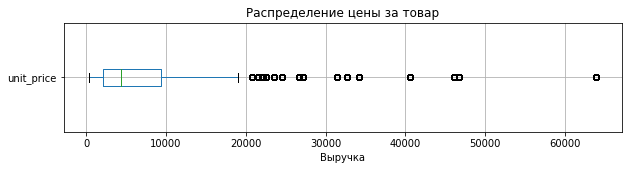

In [ ]:
# Проверим данные на выбросы
# Построим boxplot для оценки данных по цене товаров
boxplot = pa_diploma_orders.boxplot(column='unit_price',
                     vert=False, 
                     figsize=(10, 2))
plt.title('Распределение цены за товар')
plt.xlabel('Выручка')

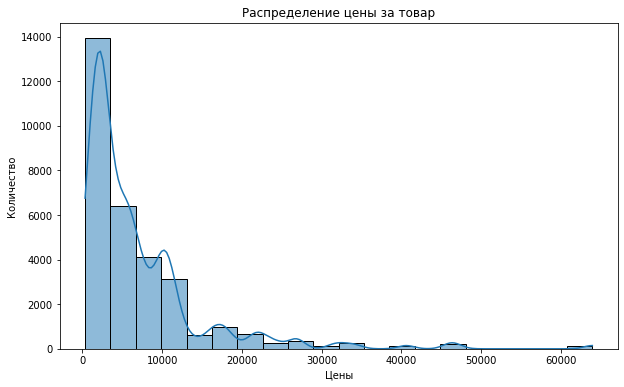

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(pa_diploma_orders['unit_price'], bins=20, alpha=0.5, edgecolor='black', kde=True)
plt.title('Распределение цены за товар')
plt.xlabel('Цены')
plt.ylabel('Количество');

Данные распределены не симметрично. Есть длинный "хвост" справа из небольшоего количества высоких цен. Проверим эти цены на адекватность.

In [ ]:
orders_max_unit_price = pa_diploma_orders[pa_diploma_orders['unit_price'] >= 60000]

In [ ]:
display(orders_max_unit_price)

,order_id,user_id,order_date,product_name,quantity,unit_price,total_price,category_name,order_week,order_month
118,119,100,2024-01-17 08:10:57,Диван угловой,3,63932.38,191797.14,Мебель для дома,2024-01-15,2024-01-01
127,128,100,2024-02-24 01:25:44,Диван угловой,1,63932.38,63932.38,Мебель для дома,2024-02-19,2024-02-01
605,606,451,2024-01-25 10:10:17,Диван угловой,3,63932.38,191797.14,Мебель для дома,2024-01-22,2024-01-01
688,689,533,2024-01-31 16:46:18,Диван угловой,2,63932.38,127864.76,Мебель для дома,2024-01-29,2024-01-01
907,908,855,2024-02-24 07:46:37,Диван угловой,1,63932.38,63932.38,Мебель для дома,2024-02-19,2024-02-01
...,...,...,...,...,...,...,...,...,...,...
29963,30106,37227,2024-12-16 16:31:45,Диван угловой,2,63932.38,127864.76,Мебель для дома,2024-12-16,2024-12-01
30423,30601,38899,2024-11-28 01:10:04,Диван угловой,2,63932.38,127864.76,Мебель для дома,2024-11-25,2024-11-01
30480,30663,39141,2024-12-31 10:20:52,Диван угловой,3,63932.38,191797.14,Мебель для дома,2024-12-30,2024-12-01
30604,30795,39738,2024-12-24 06:03:52,Диван угловой,3,63932.38,191797.14,Мебель для дома,2024-12-23,2024-12-01


Высокие цены у крупногабаритных товаров (диван). Цены адекватны.

In [ ]:
# Проверим разброс цен за заказ
display(pa_diploma_orders['total_price'].describe())

count     31357.000000
mean      14030.175560
std       18667.398146
min         339.000000
25%        3776.740000
50%        7554.640000
75%       17657.460000
max      191797.140000
Name: total_price, dtype: float64

Максимальная цена за заказ соответствует максимальной цене за товар. Данные адекватны.

**Проверим данные на неявные дубликаты**

In [ ]:
# Проверим на неявные дубликаты таблицу с сессиями
pa_diploma_sessions.duplicated(subset=['user_id', 'session_id', 'session_start']).sum()

0

Дублирующихся сессий нет

In [ ]:
# Проверим на неявные дубликаты таблицу с покупками
pa_diploma_orders.duplicated(subset=['user_id', 'order_id']).sum()

0

Дублирующихся заказов нет

**Проверим по всем ли пользователям, совершившим покупки, есть данные в таблице `users`**

In [ ]:
orders_users = pa_diploma_orders['user_id'].nunique()
users_users = pa_diploma_users['user_id'].nunique()

print(f"Пользователей в orders: {orders_users}")
print(f"Пользователей в users: {users_users}")

Пользователей в orders: 8922
Пользователей в users: 44151


In [ ]:
# Множества user_id
orders_user_ids = set(pa_diploma_orders['user_id'].unique())
users_user_ids = set(pa_diploma_users['user_id'].unique())

# Разница: пользователи с покупками, которых нет в users
missing_users = orders_user_ids - users_user_ids

print(f"Пользователи из orders, отсутствующие в users: {len(missing_users)}")

Пользователи из orders, отсутствующие в users: 268


In [ ]:
# Выведем id этих пользователей
missing_users_list = list(missing_users)
print(missing_users_list[:10])

[16897, 26117, 44039, 7177, 3082, 4618, 7691, 38925, 8204, 11279]


In [ ]:
# Посмотрим информацию о заказах этих пользователей
orders_missing = pa_diploma_orders[pa_diploma_orders['user_id'].isin(missing_users)]
orders_missing.head(10)

,order_id,user_id,order_date,product_name,quantity,unit_price,total_price,category_name,order_week,order_month
33,34,20,2024-01-05 03:55:21,Кардиган вязаный,2,9268.87,18537.74,Женская одежда,2024-01-01,2024-01-01
34,35,20,2024-01-05 03:55:21,Термос стальной,2,16469.18,32938.36,Товары для туризма,2024-01-01,2024-01-01
35,36,20,2024-01-05 03:55:21,Пальто зимнее,2,2401.55,4803.10,Женская одежда,2024-01-01,2024-01-01
36,37,20,2024-01-05 03:55:21,Спальный мешок,1,16542.45,16542.45,Товары для туризма,2024-01-01,2024-01-01
466,467,368,2024-01-24 05:25:26,Мука пшеничная,1,2179.75,2179.75,Продукты питания,2024-01-22,2024-01-01
467,468,368,2024-01-24 05:25:26,Тумба ТВ,1,46071.21,46071.21,Мебель для дома,2024-01-22,2024-01-01
640,641,487,2024-01-06 11:49:20,Витамины комплекс,1,3449.51,3449.51,Медицинские товары,2024-01-01,2024-01-01
641,642,487,2024-01-06 11:49:20,Костюм деловой,1,7895.47,7895.47,Мужская одежда,2024-01-01,2024-01-01
834,835,773,2024-01-26 19:59:34,Коврики салонные,3,2955.93,8867.79,Автотовары,2024-01-22,2024-01-01
835,836,773,2024-01-26 19:59:34,Лопата штыковая,2,11384.43,22768.86,Инструменты и садовый инвентарь,2024-01-22,2024-01-01


Заказы пользователей выглядят адекватно. Посчитаем долю этих пользователей от всех совершивших покупки.

In [ ]:
# Посчитаем долю покупающих пользователей без информации
share_paying_users = len(missing_users) / len(orders_user_ids)
print(f"Доля покупающих пользователей без информации: {share_paying_users:.2%}")

Доля покупающих пользователей без информации: 3.00%


Доля пропущеных данных не велика. Так как, из-за отсутвствия о них информации в таблице pa_diploma_users, их сложно будет сегментировать, то можно их удалить.

In [ ]:
# Очистим таблицу от этих пользователей
valid_user_ids = set(pa_diploma_users['user_id'])

# Фильтруем pa_diploma_orders, оставляя только тех пользователей, которые есть в pa_diploma_users
pa_diploma_orders = pa_diploma_orders[pa_diploma_orders['user_id'].isin(valid_user_ids)]

Период анализа данных с 2024-01-01 по 2025-01-01.

В ходе предобработки данных изменены типы данных в столбцах с датами. Данные очищены проверены на пропуски, дубликаты и выбросы.

Данные хорошего качества и подготовлены к работе.

# Расчет метрик

### 2. Проведем обзор ключевых метрик

На этом этапе вам выполним верхнеуровневую оценку состояния продукта с помощью собранных витрин. Бизнес просит просто оценить текущее состояние — без глубокой сегментации и оценки сложных метрик. 

Выручка бизнеса — 5% комиссии от стоимости любой продажи.

Посмотрим на общую динамику ключевых метрик: Revenue, ARPU/ARPPU, MAU, WAU, DAU, AOV, Retention, CTR, CR в заказ. 

Wель — быстро получить общую картину, не применяя сегментацию и не рассматривая глубокие срезы. Определим, соответствует ли продукт базовым ожиданиям, виден ли рост, есть ли тревожные сигналы и аномалии.

В результате сделаем вывод о динамике основных продуктовых метрик. 

Построим обзор ключевых метрик - Revenue, MAU, WAU, DAU, Stickiness, Retention, CR.

**Revenue**

In [ ]:
# Посчитаем Revenue по неделям
revenue_week = pa_diploma_orders.groupby('order_week')['total_price'].sum().reset_index()
revenue_week['revenue_week'] = revenue_week['total_price']*0.05

# Посчитаем Revenue по месяцам
revenue_month = pa_diploma_orders.groupby('order_month')['total_price'].sum().reset_index()
revenue_month['revenue_month'] = revenue_month['total_price']*0.05

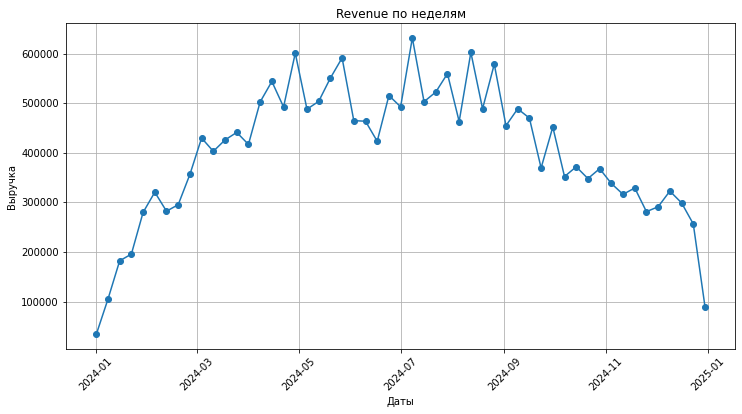

In [ ]:
# Строим график Revenue по неделям
plt.figure(figsize=(12,6))
plt.plot(revenue_week['order_week'], revenue_week['revenue_week'], marker='o')
plt.title('Revenue по неделям')
plt.xticks(rotation=45)
plt.grid(True)
plt.xlabel('Даты')
plt.ylabel('Выручка');

С начала года Revenue растет. До мая рост более плавный, далее скачками. В июне есть просадка, далее метрика восстановилась, но с сентября появилось стабильное снижение до февральских значений.

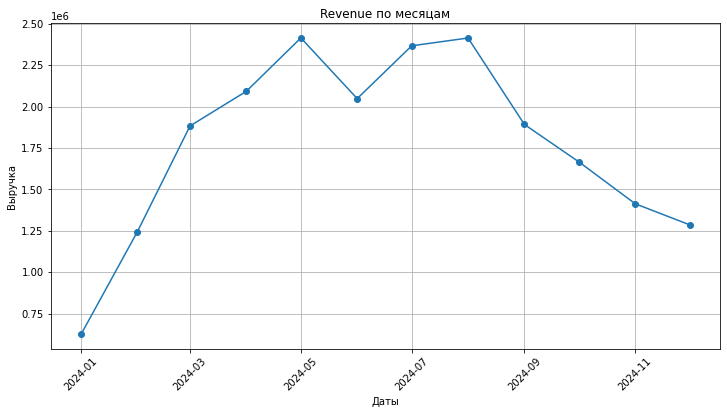

In [ ]:
# Строим график Revenue по месяцам
plt.figure(figsize=(12,6))
plt.plot(revenue_month['order_month'], revenue_month['revenue_month'], marker='o')
plt.title('Revenue по месяцам')
plt.xticks(rotation=45)
plt.grid(True)
plt.xlabel('Даты')
plt.ylabel('Выручка');

Revenue по месяцам стабильно росла с начала года,, был небольшой спад в июне. После августа выручка стабильно снижается.

Посмотрим, что происходит с количеством пользователей на маркетплейсе.

**MAU, WAU, DAU**

In [ ]:
# Посчитаем основные метрики взаимодействия уникальных пользователей с сайтом или приложением маркетплейса
# Преобразуем время событий в формат date для анализа данных 
pa_diploma_events['event_day'] = pa_diploma_events['event_date'].dt.date

# Посчитаем DAU (по дням)
DAU = pa_diploma_events.groupby('event_day')['user_id'].nunique().reset_index(name='DAU')

# Посчитаем WAU (по неделям)
WAU = pa_diploma_events.groupby('event_week')['user_id'].nunique().reset_index(name='WAU')

# Посчитаем MAU (по месяцам)
MAU = pa_diploma_events.groupby('event_month')['user_id'].nunique().reset_index(name='MAU')

# Добавим поле 'event_month' в DAU
DAU['event_month'] = pd.to_datetime(DAU['event_day']).dt.to_period('M')

In [ ]:
# Среднее DAU по каждому месяцу
avg_DAU_per_month = DAU.groupby('event_month')['DAU'].mean().round().reset_index(name='avg_DAU')


In [ ]:
MAU['event_month'] = MAU['event_month'].dt.to_period('M')

# Объединяем с MAU
metrics_df = pd.merge(avg_DAU_per_month, MAU, on='event_month')

# Вычисляем stickiness
metrics_df['stickiness'] = (metrics_df['avg_DAU'] / metrics_df['MAU']).round(4)

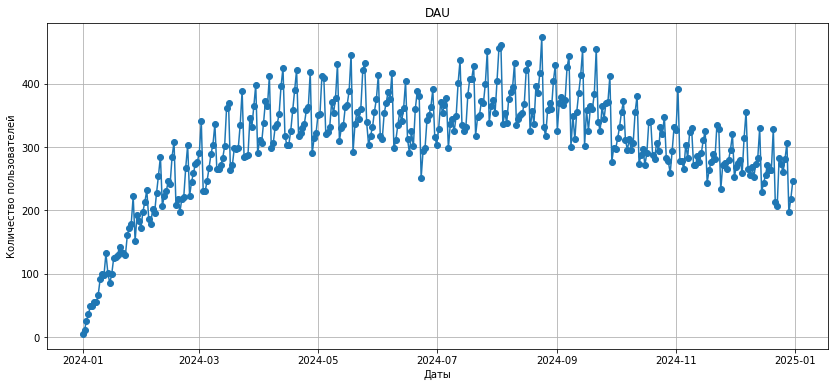

In [ ]:
# Строим график DAU
plt.figure(figsize=(14,6))
plt.plot(DAU['event_day'], DAU['DAU'], marker='o')
plt.title('DAU')
plt.grid(True)
plt.xlabel('Даты')
plt.ylabel('Количество пользователей');

В графике DAU есть явная цикличность, скорее всего связанная с поведением пользователей по дням недели. График показывает рост с начала года, небольшую просадку в середине года и к концу года довольно сильный спад.

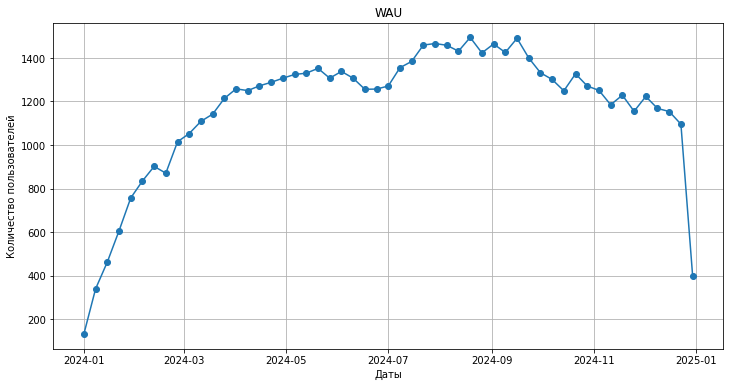

In [ ]:
# Строим график WAU
plt.figure(figsize=(12,6))
plt.plot(WAU['event_week'], WAU['WAU'], marker='o')
plt.title('WAU')
plt.grid(True)
plt.xlabel('Даты')
plt.ylabel('Количество пользователей');

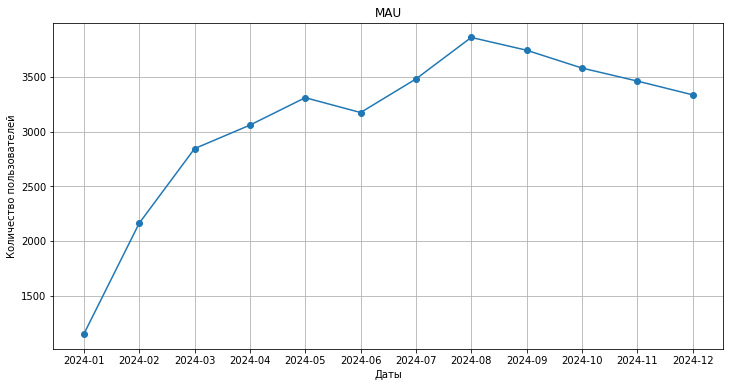

In [ ]:
MAU['event_month'] = MAU['event_month'].astype(str)

# Строим график MAU
plt.figure(figsize=(12,6))
plt.plot(MAU['event_month'], MAU['MAU'], marker='o')
plt.title('MAU')
plt.grid(True)
plt.xlabel('Даты')
plt.ylabel('Количество пользователей');

**Stickiness**

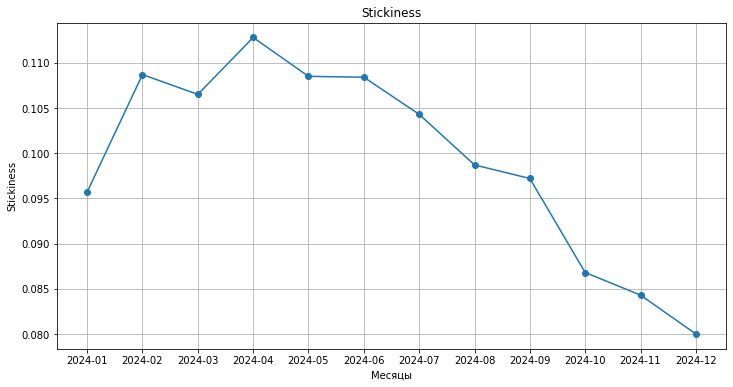

In [ ]:
metrics_df['event_month'] = metrics_df['event_month'].astype(str)

# Строим график Stickiness
plt.figure(figsize=(12,6))
plt.plot(metrics_df['event_month'], metrics_df['stickiness'], marker='o')
plt.title('Stickiness')
plt.grid(True)
plt.xlabel('Месяцы')
plt.ylabel('Stickiness');

Количество пользователей стабильно росло с начала года, был небольшой спад в июне, затем снова рост. С августа происходит снижение количестав пользователей.

Волеченность пользователей росла с начала года и также сильно снижается начиная с мая.

**Посмотрим, как меняется количество платящих пользователей**

In [ ]:
# Стчитаем количество платящих пользователей по неделям
paying_users = pa_diploma_orders.groupby('order_week')['user_id'].nunique().reset_index(name='paying_users')

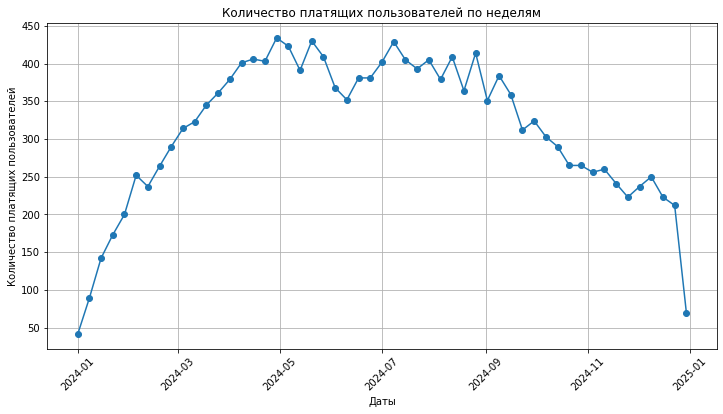

In [ ]:
# Строим график количества платящих пользователей по неделям
plt.figure(figsize=(12,6))
plt.plot(paying_users['order_week'], paying_users['paying_users'], marker='o')
plt.title('Количество платящих пользователей по неделям')
plt.xticks(rotation=45)
plt.grid(True)
plt.xlabel('Даты')
plt.ylabel('Количество платящих пользователей');

График количества платящих пользоватей очень похож на график общего количества пользователей. Так же стабильный рост с начала года, небольшой спад в июне, затем подъем. И с августа стабильный спад.

**Посмотрим, как меняется количество регистрирующихся пользователей**

In [ ]:
# Стчитаем количество регистрирующихся пользователей по неделям
reg_users = pa_diploma_users.groupby('cohort_week')['user_id'].nunique().reset_index(name='reg_users')

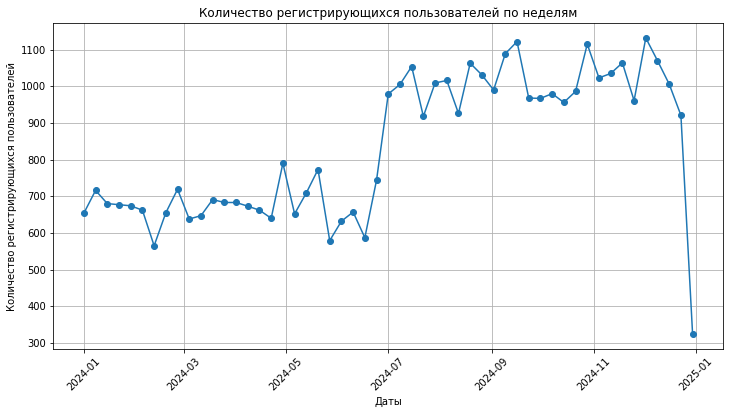

In [ ]:
# Строим график количества регистрирующихся пользователей по неделям
plt.figure(figsize=(12,6))
plt.plot(reg_users['cohort_week'], reg_users['reg_users'], marker='o')
plt.title('Количество регистрирующихся пользователей по неделям')
plt.xticks(rotation=45)
plt.grid(True)
plt.xlabel('Даты')
plt.ylabel('Количество регистрирующихся пользователей');

Количество новых пользователей не равномерно по неделям, есть всплески и просадки. Начиная с июля количество пользователей резко удвоилось по сравнению с первым полугодием и до конца года осталось на высоком уровне.

Возможно, такой прирост в пользователях произошел из-за маркетинговой компании. Поскольку в платящих пользователях количество не изменилсь, а наоборот начало снижаться, можно предположить, что привлечена нецелевая аудитория. Это объясняет снижение вовлеченности.

Посмотрим на удержание пользователей по месяцам для когорт регистрации.

**Retention**

Активность пользователей определим через события: просмотр стрницы товара, добавление товара в корзину, начало оформления заказа, завершение оформления заказа.

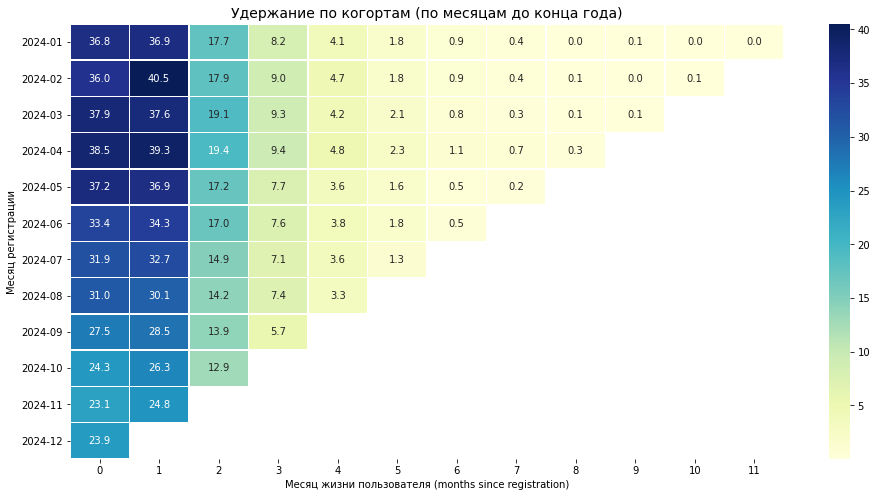

In [ ]:
# Фильтруем ключевые события
key_events = pa_diploma_events[
    pa_diploma_events['event_type'].isin([
        'product_view', 'add_to_cart', 'checkout_start', 'checkout_complete'
    ])
]

# Присоединяем к событиям дату регистрации и когорту
users = pa_diploma_users[['user_id', 'registration_date']].copy()
users['cohort_month'] = users['registration_date'].dt.to_period('M')
key_events = key_events.merge(users, on='user_id', how='left')

# Приводим даты к периодам
key_events['cohort_month'] = key_events['registration_date'].dt.to_period('M')
key_events['event_month'] = key_events['event_date'].dt.to_period('M')

# Считаем номер месяца с момента регистрации
key_events['months_since'] = (key_events['event_month'] - key_events['cohort_month'])
key_events = key_events[key_events['months_since'].notna()]  # удалим строки с NaT
key_events['months_since'] = key_events['months_since'].apply(lambda x: x.n)


# Считаем уникальных активных пользователей по когорте и месяцу жизни
cohort_activity = key_events.groupby(['cohort_month', 'months_since'])['user_id'].nunique().reset_index()

# Размеры когорт
cohort_sizes = users.groupby('cohort_month')['user_id'].nunique().reset_index()
cohort_sizes.rename(columns={'user_id': 'cohort_size'}, inplace=True)

# Объединяем активность с размерами когорт и считаем retention
retention = cohort_activity.merge(cohort_sizes, on='cohort_month')
retention['retention'] = retention['user_id'] / retention['cohort_size']

# Поворот таблицы для визуализации
retention_pivot = retention.pivot(index='cohort_month', columns='months_since', values='retention').sort_index()

# Визуализация
plt.figure(figsize=(16, 8))
sns.heatmap(retention_pivot * 100, annot=True, fmt=".1f", cmap='YlGnBu', linewidths=.5)
plt.title('Удержание по когортам (по месяцам до конца года)', fontsize=14)
plt.xlabel('Месяц жизни пользователя (months since registration)')
plt.ylabel('Месяц регистрации')
plt.yticks(rotation=0)
plt.show()

В ранних когортах с января по май удержание выше — как в день регистрации, так и в последующие дни.

С июня по октябрь удержание постепенно снижается. В октябре в 2 раза ниже, чем было в январе.

В поздних когортах ноябрь, декабрь удержание изначально низкое.

Посмотрим, как меняется конверсия в заказ.

**CR**

In [ ]:
# Присоединяем дату регистрации к заказам
orders_with_users = pd.merge(pa_diploma_orders, pa_diploma_users[['user_id', 'cohort_month']], on='user_id', how='left')

# Размер каждой когорты
cohort_sizes = pa_diploma_users.groupby('cohort_month')['user_id'].nunique().reset_index()
cohort_sizes.rename(columns={'user_id': 'cohort_size'}, inplace=True)

# Сколько пользователей из каждой когорты сделали хотя бы один заказ
converted_users = orders_with_users.groupby('cohort_month')['user_id'].nunique().reset_index()
converted_users.rename(columns={'user_id': 'paying_users'}, inplace=True)

# Считаем конверсию
conversion = pd.merge(cohort_sizes, converted_users, on='cohort_month', how='left')
conversion['conversion_rate'] = conversion['paying_users'] * 100 / conversion['cohort_size']


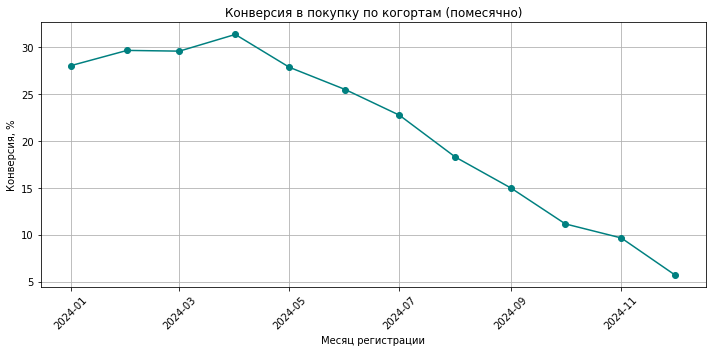

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(conversion['cohort_month'], conversion['conversion_rate'], marker='o', color='teal')
plt.title('Конверсия в покупку по когортам (помесячно)')
plt.xlabel('Месяц регистрации')
plt.ylabel('Конверсия, %')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

В начале года конверсия в покупку около 30%. С мая начинается устойчивое снижение до 6% к декабрю.

Судя по основным метрикам в продукте есть проблема. Выручка и количество пользователей сильно снижается  с августа, падает вовлеченность пользователей, возвращаемость низкая. 

Похоже, что пользователи, пришедшие с мая по декабрь покупают гораздо хуже, тех, кто был привлечен в первое полугодие.

Продолжим расчитывать метрики монетизации. По возможности, было бы полезно узнать о маркетинговых компаниях и технических изменениях в продукте с мая по август.

### 3. Оценка метрик монетизации и юнит-экономики

Выполним анализ монетизации. Определим, сколько зарабатывает продукт и сколько тратит на привлечение. 

Оценим как агрегированные метрики (ARPU, AOV), так и показатели эффективности (CAC, ROI, Payback Period).

Сформулируем первые выводы по результатам анализа метрик.

Выполним анализ монетизации. Поситаем метрики: ARPPU, ARPU, LTV,CAC, ROI.

**ARPPU — средняя выручка с платящего пользователя**

In [ ]:
# Добавим колонку с доходом маркетплейса (5% от суммы заказа)
pa_diploma_orders['revenue'] = pa_diploma_orders['total_price'] * 0.05

# Число уникальных платящих пользователей по месяцам
paying_users_month = pa_diploma_orders.groupby('order_month')['user_id'].nunique().reset_index(name='paying_users')

# Общая выручка по месяцам
total_price_month = pa_diploma_orders.groupby('order_month')['revenue'].sum().reset_index(name='total_price_month')

# ARPPU — средняя выручка с одного платящего пользователя
arppu = pd.merge(total_price_month, paying_users_month, on='order_month')
arppu['ARPPU'] = arppu['total_price_month'] / arppu['paying_users']

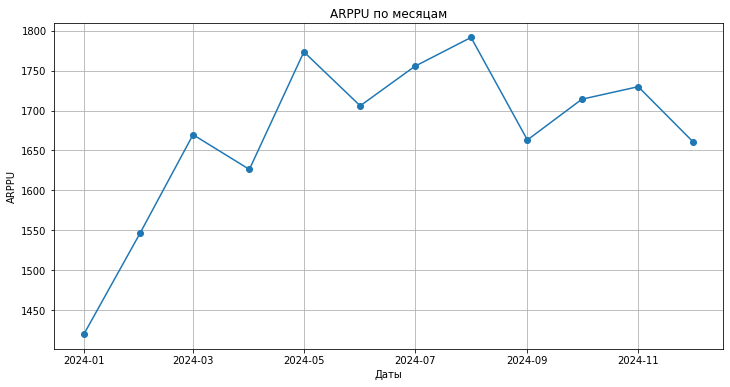

In [ ]:
# Строим график средней выручки по месяцам
plt.figure(figsize=(12,6))
plt.plot(arppu['order_month'], arppu['ARPPU'], marker='o')
plt.title('ARPPU по месяцам')
plt.grid(True)
plt.xlabel('Даты')
plt.ylabel('ARPPU');

ARPPU — средняя выручка с платящего пользователя неравномерна. С начала года росла, была просадка в апреле, июне, сентябре и декабре.

**Cредняя выручка с заказа  по месяцам**

In [ ]:
# Общее число заказов по месяцам продаж
monthly_count_orders = pa_diploma_orders.groupby('order_month')['order_id'].nunique().reset_index(name='orders_total')

# Общая выручка по месяцам продаж
monthly_revenue_total = pa_diploma_orders.groupby('order_month')['revenue'].sum().reset_index(name='revenue_total')

# Объединяем 
avg_revenue_orders = pd.merge(monthly_count_orders, monthly_revenue_total, on='order_month', how='left')
avg_revenue_orders['avg_revenue'] = avg_revenue_orders['revenue_total'] / avg_revenue_orders['orders_total']

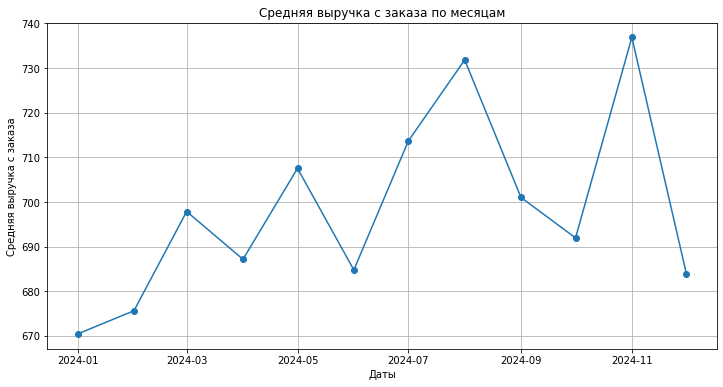

In [ ]:
# Строим график средней выручки по месяцам
plt.figure(figsize=(12,6))
plt.plot(avg_revenue_orders['order_month'], avg_revenue_orders['avg_revenue'], marker='o')
plt.title('Cредняя выручка с заказа по месяцам')
plt.grid(True)
plt.xlabel('Даты')
plt.ylabel('Cредняя выручка с заказа');

Cредняя выручка с заказа по месяцам не стабильна. Есть тенденция к росту, но диапазон значений увеличивается. В сентябре, октябре сильный спад, в ноябре максимум за год, в декабре спад до июньских значений.

**LTV**

In [ ]:
# Добавим колонку с доходом маркетплейса (5% от суммы заказа)
pa_diploma_orders['revenue'] = pa_diploma_orders['total_price'] * 0.05

# Добавим месяц регистрации в заказы
orders_with_cohort = pd.merge(pa_diploma_orders, pa_diploma_users[['user_id', 'cohort_month']], on='user_id')

# Считаем выручку по каждой когорте
cohort_revenue = orders_with_cohort.groupby('cohort_month')['revenue'].sum().reset_index()

# Считаем число уникальных пользователей в когорте
cohort_users = pa_diploma_users.groupby('cohort_month')['user_id'].nunique().reset_index(name='users')

# Считаем LTV 
ltv = pd.merge(cohort_revenue, cohort_users, on='cohort_month')
ltv['LTV'] = ltv['revenue'] / ltv['users']

**CAC**

In [ ]:
# Считаем общий бюджет по месяцам
monthly_budget = pa_diploma_campaign_costs.groupby('spend_month', as_index=False)['budget'].sum()

# Объединяем с числом пользователей
cac = pd.merge(monthly_budget, cohort_users, left_on='spend_month', right_on='cohort_month', how='inner')
cac['CAC'] = cac['budget'] / cac['users']

**ROI**

In [ ]:
# Объединяем ltv и cac
roi = pd.merge(ltv[['cohort_month', 'LTV']], cac[['cohort_month', 'CAC']], on='cohort_month')

# ROI = (LTV - CAC) / CAC
roi['ROI'] = (roi['LTV'] - roi['CAC']) / roi['CAC']

In [ ]:
# Полная таблица эффективности по когортам
cohort_metrics = pd.merge(ltv[['cohort_month', 'LTV']], cac[['cohort_month', 'CAC']], on='cohort_month')
cohort_metrics['ROI'] = (cohort_metrics['LTV'] - cohort_metrics['CAC']) / cohort_metrics['CAC']

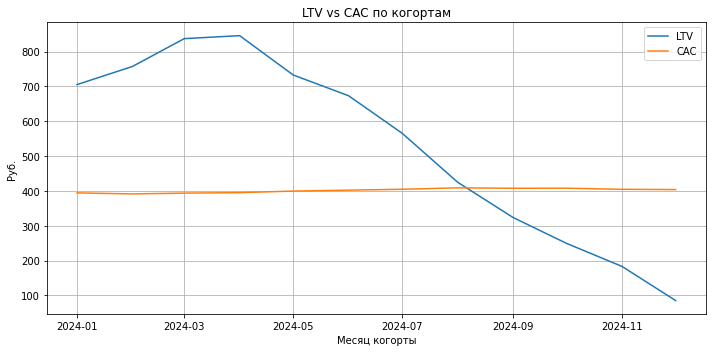

In [ ]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=cohort_metrics, x='cohort_month', y='LTV', label='LTV')
sns.lineplot(data=cohort_metrics, x='cohort_month', y='CAC', label='CAC')
plt.title('LTV vs CAC по когортам')
plt.xlabel('Месяц когорты')
plt.ylabel('Руб.')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

LTV рос равномерно до апреля, в апреле максимум 850. Дальше стал стабильно снижаться до конца года. С августа стал меньше CAC, к декабрю примерно 50. 

САС стабилен в течение всего года, около 400.

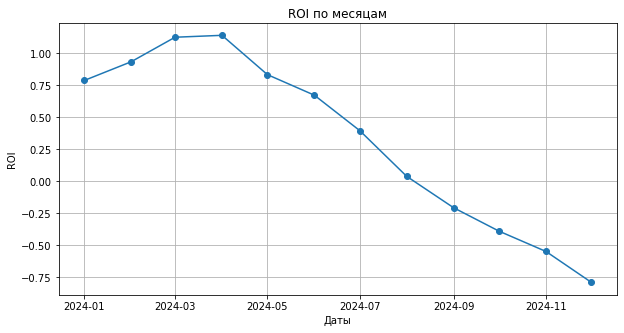

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(cohort_metrics['cohort_month'], cohort_metrics['ROI'], marker='o')
plt.title('ROI по месяцам')
plt.grid(True)
plt.xlabel('Даты')
plt.ylabel('ROI');

ROI повторяет форму графика LTV. С августа ROI отрицательный.

## Выводы по результатам первичного анализа

Представьте ключевые выводы в текстовом виде здесь или приложите ссылку на документ с презентацией.

Не забудьте предоставить доступ на просмотр и комментирование документа.

**Выручка**

С начала года выручка стабильно росла. До мая — плавно, затем скачками. В июне — заметная просадка, в июле восстановление, после чего — уверенное снижение с сентября до уровня начала года.

**Пользователи**

Общее количество пользователей росло до августа, далее пошло на спад.

Платящие пользователи повторяют ту же динамику: рост до августа, затем устойчивое снижение.

DAU демонстрирует недельную цикличность и годовой тренд: рост — до середины года, затем спад.

Количество новых пользователей начиная с июля резко удвоилось по сравнению с первым полугодием и до конца года осталось на высоком уровне. 

Вовлечённость — устойчивый рост в начале года, затем снижение с мая.

В начале года конверсия в покупку около 30%. С мая начинается устойчивое снижение до 6% к декабрю.

**Монетизация**

ARPPU росло до лета, в июне — просадка, затем рост до пика в ноябре, после чего — спад к значению весны.

ARPU — средняя выручка на всех пользователей, которые зарегистрированы стабильно идет вниз с февраля.

LTV растет равномерно до апреля, дальше стал стабильно снижаться до конца года.

**Retention**

С июня по октябрь удержание постепенно снижается. В октябре в 2 раза ниже, чем было в январе.

Большинство пользователей не возвращаются после первой недели.

**Расходы и рентабельность**

САС стабилен в течение всего года.

ROI растет равномерно до апреля, дальше стал стабильно снижается до конца года. С августа отрицателен.

**Выводы**

Во всех ключевых метриках наблюдается перелом:
рост в первом полугодии сменяется затяжным спадом с августа.

Особенно тревожны:

- Падение выручки — несмотря на рост новых пользователей.

- Резкое снижение конверсии в покупку на фоне удвоившегося притока новых пользователей.

- Снижающийся LTV и ARPU при стабильном CAC.

- Отрицательный ROI с августа.

Продукт, вероятно, теряет ценность для пользователей или маркетинг начал привлекать нецелевую аудиторию. 

Для дальнейшего анализа требуется:

- Сегментация пользователей (по каналам, регионам, устройствам и т.п.).

- Анализ причин низкой конверсии и удержания.

## 4. Поиск инсайтов, точек роста и сегментация


### Цель дальнейшего анализа - сформировать обоснованные гипотезы:

* какие сегменты работают лучше остальных
* какие сегменты работают хуже остальных
* на каких этапах воронки теряются пользователи
* какие группы можно или нужно масштабировать
* куда стоит инвестировать больше внимания или ресурсов

Проверим данные по таким сегментам: каналы привлечения, устройства, платформы, страны.

По каналам привлечения проверим: выручку, количество пользователей, количество платящих пользователей, ARPU, ARPPU

**Выручка по каналам привлечения и когортам регистрации**

In [ ]:
# Проверим выручку по каналам привлечения и когортам
# Соединим выручку и пользователей
orders_users = pd.merge(pa_diploma_orders, pa_diploma_users, on='user_id')

In [ ]:
# Проверим выручку по каналам привлечения и когортам (месяцам)
# Выручка по когортам и каналам
revenue_cohort_acq = orders_users.groupby(['cohort_month', 'acq_channel'])['revenue'].sum().reset_index()

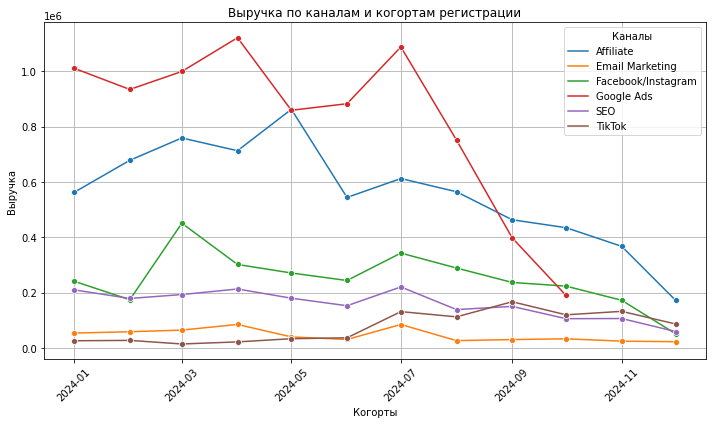

In [ ]:
# Строим график
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=revenue_cohort_acq,
    x='cohort_month',
    y='revenue',
    hue='acq_channel',
    marker='o'
)

plt.title('Выручка по каналам и когортам регистрации')
plt.xlabel('Когорты')
plt.ylabel('Выручка')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend(title='Каналы')
plt.tight_layout()
plt.show()

Выручка в канале Google Ads самая высокая, график падения повторяет форму графика общей выручки. Вклад канала Google Ads в общуюю выручку очень значительный.

В канале Affiliate также высокая выручка. Значительно ниже в каналах: SEO, TikTok, Facebook/Instagram. В декабре по всем каналам выручка снижается.

На графике видно с августа резкое падение выручки в канале Google Ads. Данных за ноябрь и декабрь в этом канале нет (график обрывается). В канале Affiliate более плавное, то тоже значительное падение с июня. В каналах Facebook/Instagram, SEO, Email Marketing снижение выручки почти незначительное. В канале Tik Tok рост выручки с июля.

Во всех каналах есть падение выручки от новых пользователей в декабре.

**Выручка по каналам привлечения и месяцам продаж**

In [ ]:
# Проверим выручку по каналам привлечения и месяцам продаж
# Выручка по когортам и каналам
revenue_orders_month_acq = orders_users.groupby(['order_month', 'acq_channel'])['revenue'].sum().reset_index()

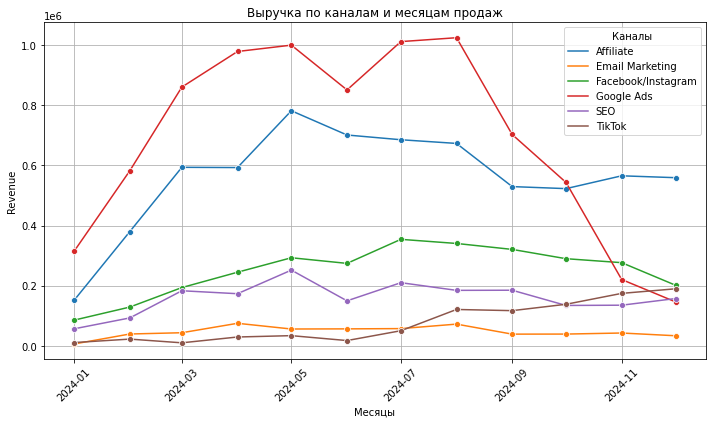

In [ ]:
# Строим график
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=revenue_orders_month_acq,
    x='order_month',
    y='revenue',
    hue='acq_channel',
    marker='o'
)

plt.title('Выручка по каналам и месяцам продаж')
plt.xlabel('Месяцы')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend(title='Каналы')
plt.tight_layout()
plt.show()

Выручка в канале Google Ads самая высокая, график падения повторяет форму графика общей выручки. Вклад канала Google Ads в общуюю выручку очень значительный.

В канале Affiliate также высокая выручка. Значительно ниже в каналах: SEO, TikTok, Facebook/Instagram. В декабре  выручка в каналах Google Ads, Affiliate, Facebook/Instagram снижается.

На графике видно с августа резкое падение выручки в канале Google Ads. Данных за ноябрь и декабрь в этом канале нет (график обрывается). В канале Affiliate более плавное, то тоже значительное падение с июня. В каналах Facebook/Instagram, SEO, Email Marketing снижение выручки почти незначительное. В канале Tik Tok рост выручки с июля.

Падение выручки по месяцам более плавное, чем по когортам регистрации. Это говорит о том что продолжают покупать пользователи из когорт регистрации первого полугодия.

Проверим как меняется количество заказов и средний чек в этих каналах по когортам регистрации.

**Средний чек по каналам привлечения**

In [ ]:
# Выведем общие значения среднего чека по каналам
aov_acq = orders_users.groupby('acq_channel')['total_price'].describe()
display(aov_acq)

,count,mean,std,min,25%,50%,75%,max
acq_channel,,,,,,,,
Affiliate,9668.0,13934.246538,18223.581127,339.00,3680.11,7513.170,17610.39,191797.14
Email Marketing,793.0,14015.100643,17194.277005,390.65,3776.74,7036.850,17930.16,140290.31
Facebook/Instagram,3978.0,15084.237006,21974.174116,339.00,3449.51,7293.280,17803.47,191797.14
Google Ads,11896.0,13847.949289,18150.692081,339.00,3891.76,7629.360,17657.46,191797.14
SEO,2803.0,13627.789843,17638.251074,339.00,3777.32,7609.350,16638.87,191797.14
TikTok,1308.0,13921.226384,17954.558856,339.00,3633.61,7616.045,17791.27,191797.14


- Средние значения средних чеков по каналам Affiliate, Google Ads, SEO, TikTok довольно близки 13934 - 13627.
- Среднее значение среднего чека по каналу Email Marketing - 14015
- Средние значения среднего чека по каналам Facebook/Instagram - 15084


- Минимальные значения среднего чека по каналам Affiliate, Google Ads, SEO, TikTok, Facebook/Instagram - около 339
- Минимальные значения среднего чека по каналу Email Marketing	- 390


- Максимальные значения среднего чека по каналам Affiliate, Google Ads, SEO, TikTok, Facebook/Instagram - 191797
- Максимальные значения среднего чека по каналу Email Marketing	- 140290

Совпадающие минимальные и максимальные значения средних чеков  в разных каналах логичны, так как это, вероятно, продажи одних и тех же самых дорогих и самых дешевых товаров через разные каналы.

Посмотрим, как каспределяются значения средних чеков в течение года

**Средний чек по каналам привлечения и когортам регистрации**

In [ ]:
# Посчитаем средний чек по каналам и когортам регистрации
aov_acq_cohort = orders_users.groupby(['cohort_month', 'acq_channel'])['total_price'].mean().reset_index(name='aov_acq')

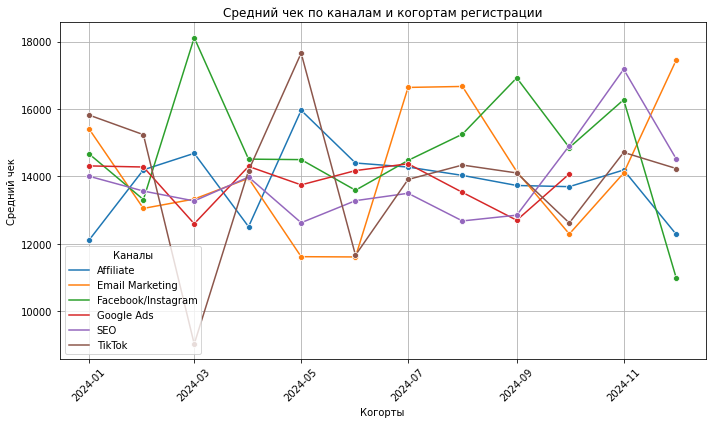

In [ ]:
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=aov_acq_cohort,
    x='cohort_month',
    y='aov_acq',
    hue='acq_channel',
    marker='o',
    ci=68
)

plt.title('Средний чек по каналам и когортам регистрации')
plt.xlabel('Когорты')
plt.ylabel('Средний чек')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend(title='Каналы')
plt.tight_layout()
plt.show()

Средние чеки не имеют теденции к уменьшению или увеличению. Разброс значений самый большой в канале Tik Tok, самый маленький в Google Ads. Во всех каналах, кроме Email Marceting, в декабре средний чек снизился.

Разброс значений средних чеков на протяжении года:
- Affiliate: от 12000 до 16000
- Email Marceting: от 11500 до 16500
- Facebook/Instagram: 13500 до 18000
- Google Ads: 12500 до 14500
- SEO: от 12500 до 17000
- Tik Tok: 9000 до 17500

Похоже, падение выручки с середины года не связано с поведением средних чеков по каналам.

**Количество заказов по каналам привлечения и когортам регистрации**

In [ ]:
# Считаем количество заказов по каналам привлечения и когортам регистрации
orders_acq_cohort = orders_users.groupby(['cohort_month', 'acq_channel'])['order_id'].nunique().reset_index(name='orders_acq_cohort')

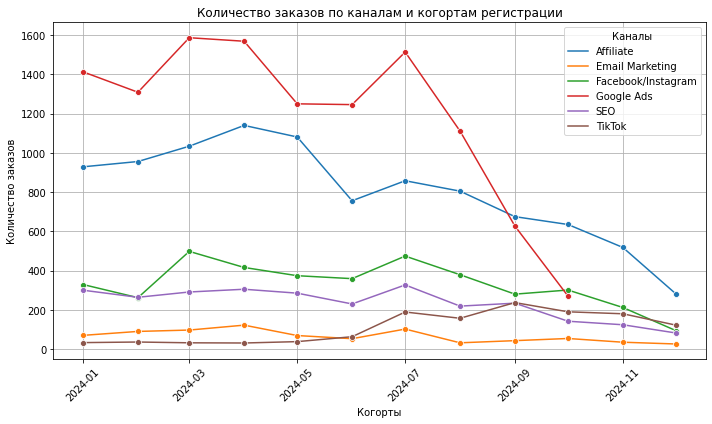

In [ ]:
# Строим график
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=orders_acq_cohort,
    x='cohort_month',
    y='orders_acq_cohort',
    hue='acq_channel',
    marker='o'
)

plt.title('Количество заказов по каналам и когортам регистрации')
plt.xlabel('Когорты')
plt.ylabel('Количество заказов')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend(title='Каналы')
plt.tight_layout()
plt.show()

Количество заказов по каналам повторяет график выручки по каналам. Порядок графиков совпадает с порядком графиков с выручкой. Заказов больше в каналах, где выручка больше.

Количество заказов в канале Google Ads самое высокое, график падения повторяет форму графика общей выручки. Вклад канала Google Ads в общее число заказов очень значительный.

В канале Affiliate также большое число заказов. Значительно ниже в каналах: SEO, TikTok, Facebook/Instagram. В декабре по всем каналам количество заказов снижается.

На графике видно с августа резкое падение количества заказов в канале Google Ads. Данных за ноябрь и декабрь в этом канале нет (график обрывается). В каналах Affiliate, Facebook/Instagram более плавное, то тоже значительное падение с июня. В каналах SEO, Email Marketing снижение количества заказов почти незначительное. В канале Tik Tok рост выручки с июля.

Во всех каналах падение числа заказов среди новых пользователей в декабре.

Проверим, зависит ли изменение общего количества заказов от среднего количества заказов на пользователя или от количества пользователей.

**Среднее количество заказов на пользователя по каналам привлечения и когортам регистрации**

In [ ]:
# Считаем количество заказов на пользователя по каналам привлечения и когортам регистрации
count_orders_acq_cohort = orders_users.groupby(['user_id', 'cohort_month', 'acq_channel'])['order_id'].nunique().reset_index(name='count_orders')

# Среднее количество заказов на пользователя по каналам привлечения и когортам регистрации
avg_orders_acq_cohort = count_orders_acq_cohort.groupby(['user_id', 'cohort_month', 'acq_channel'])['count_orders'].mean().reset_index(name='avg_orders_acq_cohort')

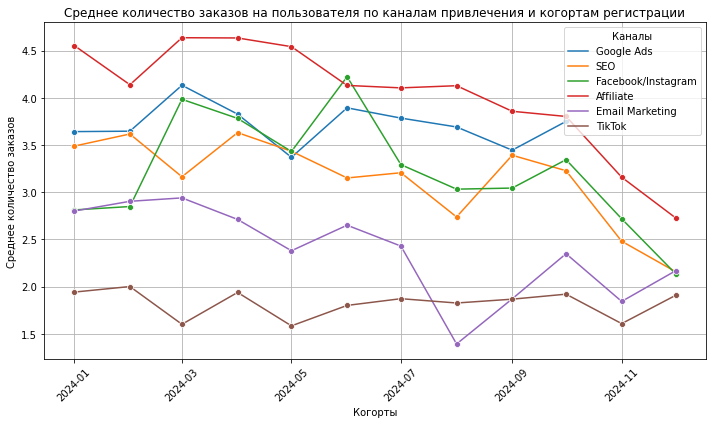

In [ ]:
# Строим график
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=avg_orders_acq_cohort,
    x='cohort_month',
    y='avg_orders_acq_cohort',
    hue='acq_channel',
    marker='o',
    ci=None # убираем отображение доверительного интервала для чистоты графика
)

plt.title('Среднее количество заказов на пользователя по каналам привлечения и когортам регистрации')
plt.xlabel('Когорты')
plt.ylabel('Среднее количество заказов')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend(title='Каналы')
plt.tight_layout()
plt.show()

- В канале Affiliate самое большое количество заказов на одного пользователя. В мае спад и стабилизация на уровне февраля. С сентября спад до конца года. 
- В канале Google Ads количество более стабильно, есть спад в мае и сентябре. Тенденции к уменьшению количества заказов почти нет. Данные за ноябрь, декабрь отсутствуют. 
- В канале SEO есть спады в мае и августе. Есть тенденция к уменьшению количества заказов. К концу года резкий спад. 
- В каналах Facebook/Instagram есть всплеск в марте и июне. Есть спад в мае. После подъема в июне количество платящих пользователей снижается до минимальных значений к декабрю. 
- В канале Email Marketing есть тенденция к снижению количества заказов. Спады в мае и резкий спад в августе.
- В канале Tik Tok количество заказов меньше, чем в других каналах. Количество заказов практически стабильно в течение года.

Тенденции в количестве заказов на пользователя не повторяют явно тенденции общего количества заказов и выручки. В канале Google Ads количество заказов на пользователя почти не меняется, но выручка и общее количество заказов резко падает.

В канале Tik Tok количество заказов на пользователя не меняется, но выручка и общее количество заказо растет.

Проверим связаны ли выручка и общее количество заказов с количеством пользователей когортах регистрации.

**Количество платящих пользователей по каналам привлечения и когортам регистрации**

In [ ]:
# Считаем количество заказов по каналам и когортам регистрации
paying_acq_cohort = orders_users.groupby(['cohort_month', 'acq_channel'])['user_id'].nunique().reset_index(name='paying_acq_cohort')

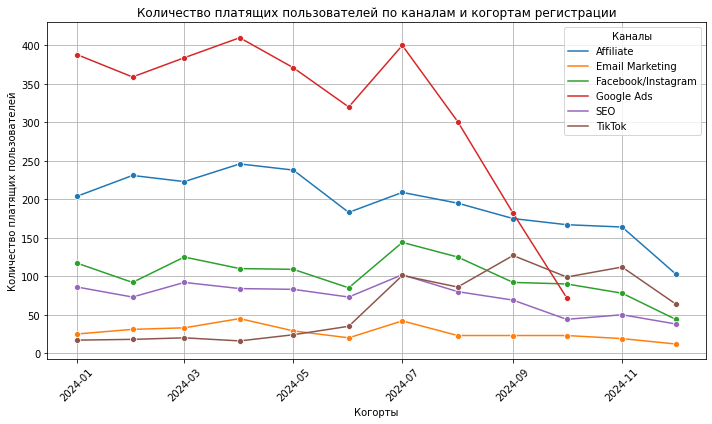

In [ ]:
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=paying_acq_cohort,
    x='cohort_month',
    y='paying_acq_cohort',
    hue='acq_channel',
    marker='o'
)

plt.title('Количество платящих пользователей по каналам и когортам регистрации')
plt.xlabel('Когорты')
plt.ylabel('Количество платящих пользователей')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend(title='Каналы')
plt.tight_layout()
plt.show()

Количество платящих пользователей также повторяет график выручки по каналам и когортам привлечения.

- С августа резкое падение количества платящих пользователей в канале Google Ads. Данных за ноябрь и декабрь в этом канале нет (график обрывается). 
- В канале Affiliate более плавное, то тоже значительное падение с июня. 
- В каналах Facebook/Instagram есть всплеск в июле, затем количество платящих пользователей нижается до минимальных значений к декабрю. 
- SEO, Email Marketing снижение количества платящих пользователей есть, но не такое незначительное. 
- В канале Tik Tok рост количества платящих пользователей с июня.

Количество платящих пользователей в канале Google Ads самоя высокое, график падения повторяет форму графика общего количества платящих пользователей. Вклад канала Google Ads в общее количество платящих пользователей очень значительный.

К концу года во всех каналах снижено количество новых пользователей.

Проверим как менялось количество платящих пользователей по каналам и когортам регистрации.

**Количество новых пользователей по каналам привлечения и когортам регистрации**

In [ ]:
# Посчитаем новых пользователей по каналам и когортам регистрации
new_user_acq = pa_diploma_users.groupby(['cohort_month', 'acq_channel'])['user_id'].nunique().reset_index(name='new_user_acq')

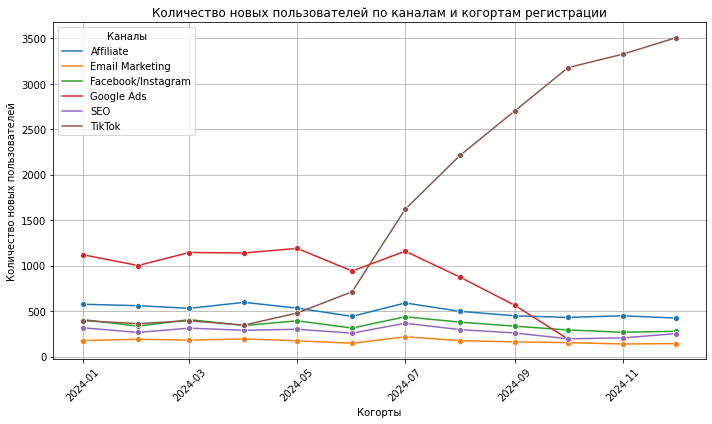

In [ ]:
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=new_user_acq,
    x='cohort_month',
    y='new_user_acq',
    hue='acq_channel',
    marker='o'
)

plt.title('Количество новых пользователей по каналам и когортам регистрации')
plt.xlabel('Когорты')
plt.ylabel('Количество новых пользователей')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend(title='Каналы')
plt.tight_layout()
plt.show()

С августа резкое падение количества новых пользователей в канале Google Ads. Данных за ноябрь и декабрь в этом канале нет (график обрывается). В каналах Affiliate, Facebook/Instagram, SEO, Email Marketing есть незначительное снижение количества новых пользователей. В канале Tik Tok резкий кратный (в семь раз) рост количества новых пользователей с июня.

Похоже, что падение выручки может быть связано с падением количества пользователей в канале Google Ads и привлечением нецелевой аудитории в канале Tik Tok

Посмотрим, что происходит с конверсией в покупку в этих каналах

**Конверсия в покупку по каналам привлечения и когортам регистрации**

In [ ]:
# Посчитаем новых пользователей по каналам и когортам регистрации
new_user_cohort_acq = pa_diploma_users.groupby(['cohort_month', 'acq_channel'])['user_id'].nunique().reset_index(name='new_user_acq')

# Посчитаем количество покупающих пользователей по каналам и когортам регистрации
paying_users_acq = orders_users.groupby(['cohort_month', 'acq_channel'])['user_id'].nunique().reset_index(name='paying_users_acq')

convertion_paying = pd.merge(new_user_cohort_acq, paying_users_acq, on=['cohort_month', 'acq_channel'])

convertion_paying['convertion_paying'] = convertion_paying['paying_users_acq'] * 100 / convertion_paying['new_user_acq']

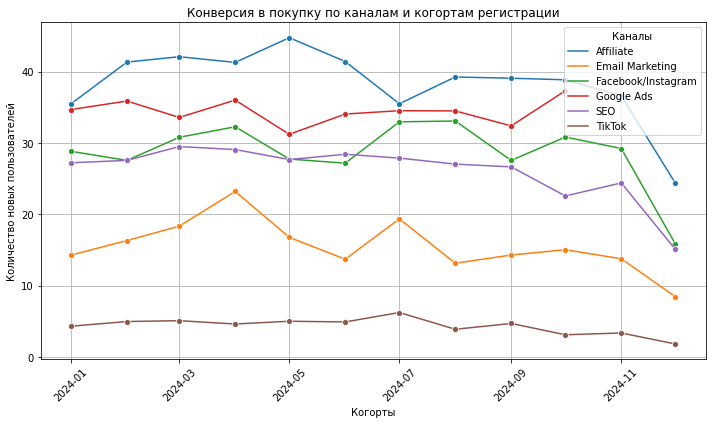

In [ ]:
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=convertion_paying,
    x='cohort_month',
    y='convertion_paying',
    hue='acq_channel',
    marker='o'
)

plt.title('Конверсия в покупку по каналам и когортам регистрации')
plt.xlabel('Когорты')
plt.ylabel('Количество новых пользователей')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend(title='Каналы')
plt.tight_layout()
plt.show()

- В канале Google Ads конверсия в покупку довольно стабильна. В мае и сентябре был спад, между спадами конверсия была ниже, чем в начале года. В октябре значение конверсии максимальное. За ноябрь и декабрь нет данных.

- В канале Tik Tok конверсия самая низкая. В июле был небольшой подъем, а далее плавный спад до конца года. На фоне сильного роста количества новых пользователей, это может говорить о том, что новые пользователи не являются целевой аудиторией, а основную часть заказов делают старые пользователи.

- В канале Affilaite конверсия в покупку самая высокая, росла до июля. В июле был спад до февральского уровня. Далее конверсия немного восстановилась. В декабре сильный спад.

- В каналах Facebook/Instagram конверсия не очень стабильна. В мае, июне и сентябре спад. В июле и агусте рост до максимальных значений. В декабре резкий спад.

- В канале SEO конверсия без резких скачков, но плавный спад до сентября. В декабре резкий спад.

- В канале Email Marketing конверсия не стабильна. Росла до максимума в апреле, далее спад в июне и августе. В декабре спад до минимальных значений.

Во всех каналах в декабре спад до минимального уровня, значительно меньшего, чем в начале года.

**Конверсия в покупку по каналам и месяцу с момента регистрации**

In [ ]:
# Присоединяем к заказам когорты и каналы
orders_with_cogort = pa_diploma_orders.merge(pa_diploma_users[['user_id', 'cohort_month', 'acq_channel']], on='user_id')

In [ ]:
#Считаем номер месяца с момента регистрации
orders_with_cogort['months_since'] = (
    (orders_with_cogort['order_month'].dt.year - orders_with_cogort['cohort_month'].dt.year) * 12 +
    (orders_with_cogort['order_month'].dt.month - orders_with_cogort['cohort_month'].dt.month))

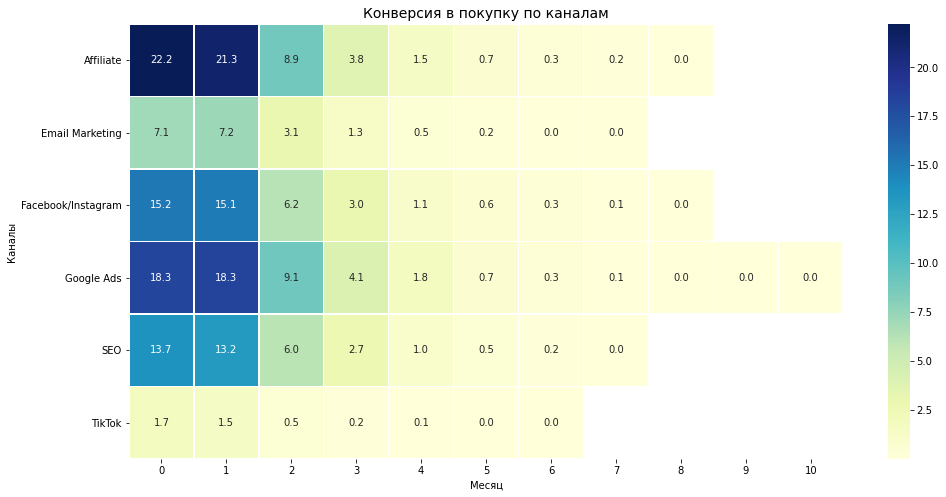

In [ ]:
# Сколько пользователей из каждого канала сделали хотя бы один заказ
converted_users_month = orders_with_cogort.groupby(['acq_channel', 'months_since'])['user_id'].nunique().reset_index()
converted_users_month.rename(columns={'user_id': 'paying_users'}, inplace=True)

# Количество пользователей по каналам
cohort_sizes_month = pa_diploma_users.groupby('acq_channel')['user_id'].nunique().reset_index()
cohort_sizes_month.rename(columns={'user_id': 'cohort_size'}, inplace=True)

# Считаем конверсию
conversion_month = pd.merge(cohort_sizes_month, converted_users_month, on='acq_channel', how='left')
conversion_month['conversion_rate'] = conversion_month['paying_users'] * 100 / conversion_month['cohort_size']

# Поворот таблицы для визуализации
conversion_month_pivot = conversion_month.pivot(index='acq_channel', columns='months_since', values='conversion_rate').sort_index()

# Визуализация
plt.figure(figsize=(16, 8))
sns.heatmap(conversion_month_pivot, annot=True, fmt=".1f", cmap='YlGnBu', linewidths=.5)
plt.title('Конверсия в покупку по каналам', fontsize=14)
plt.xlabel('Месяц')
plt.ylabel('Каналы')
plt.yticks(rotation=0)
plt.show()


Самая высокая конверсия в покупку в каналах Affilaite и Google Ads. Самая низкая в Tik Tok. Активнее всего пользователи покупают в течение первых 2-3 месяцев после регистрации.

**Конверсия в покупку по когортам регистрации  месяцу с момента регистрации**

In [ ]:
# Присоединяем к заказам когорты
orders_with_cogort = pa_diploma_orders.merge(pa_diploma_users[['user_id', 'cohort_month']], on='user_id')

In [ ]:
#Считаем номер месяца с момента регистрации
orders_with_cogort['months_since'] = (
    (orders_with_cogort['order_month'].dt.year - orders_with_cogort['cohort_month'].dt.year) * 12 +
    (orders_with_cogort['order_month'].dt.month - orders_with_cogort['cohort_month'].dt.month))

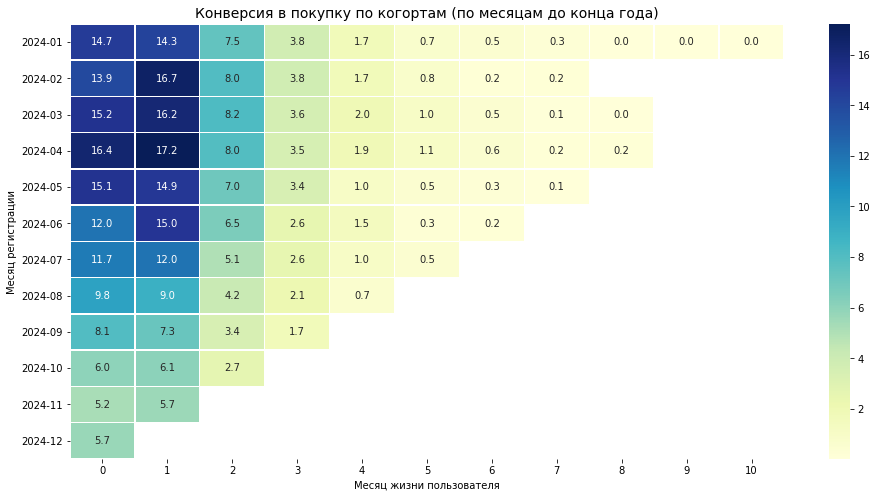

In [ ]:
# Сколько пользователей из каждой когорты сделали хотя бы один заказ
converted_users_month = orders_with_cogort.groupby(['cohort_month', 'months_since'])['user_id'].nunique().reset_index()
converted_users_month.rename(columns={'user_id': 'paying_users'}, inplace=True)

# Размер каждой когорты
cohort_sizes_month = pa_diploma_users.groupby('cohort_month')['user_id'].nunique().reset_index()
cohort_sizes_month.rename(columns={'user_id': 'cohort_size'}, inplace=True)

# Считаем конверсию
conversion_month = pd.merge(cohort_sizes_month, converted_users_month, on='cohort_month', how='left')
conversion_month['conversion_rate'] = conversion_month['paying_users'] * 100 / conversion_month['cohort_size']

conversion_month['cohort_month'] = conversion_month['cohort_month'].dt.to_period('M')

# Поворот таблицы для визуализации
conversion_month_pivot = conversion_month.pivot(index='cohort_month', columns='months_since', values='conversion_rate').sort_index()

# Визуализация
plt.figure(figsize=(16, 8))
sns.heatmap(conversion_month_pivot, annot=True, fmt=".1f", cmap='YlGnBu', linewidths=.5)
plt.title('Конверсия в покупку по когортам (по месяцам до конца года)', fontsize=14)
plt.xlabel('Месяц жизни пользователя')
plt.ylabel('Месяц регистрации')
plt.yticks(rotation=0)
plt.show()


В когортах первого полугодия конверсия значительно выше. С июня снижается. Пользователи активнее покупают в первые 2-3 месяца после регистрации.

Посмотрим как меняестя выручка с одного плятящего пользователя

**ARPPU — средняя выручка с одного платящего пользователя по каналам привлечения и когортам регистрации**

In [ ]:
# Число уникальных платящих пользователей по каналам и когортам регистрации
paying_users_month_acq = orders_users.groupby(['cohort_month', 'acq_channel'])['user_id'].nunique().reset_index(name='paying_users_acq')

# Общая выручка по неделям
total_price_month_acq = orders_users.groupby(['cohort_month', 'acq_channel'])['revenue'].sum().reset_index(name='total_price_month_acq')

# ARPPU — средняя выручка с одного платящего пользователя
arppu_acq = pd.merge(total_price_month_acq, paying_users_month_acq, on=['cohort_month', 'acq_channel'])
arppu_acq['ARPPU'] = arppu_acq['total_price_month_acq'] / arppu_acq['paying_users_acq']

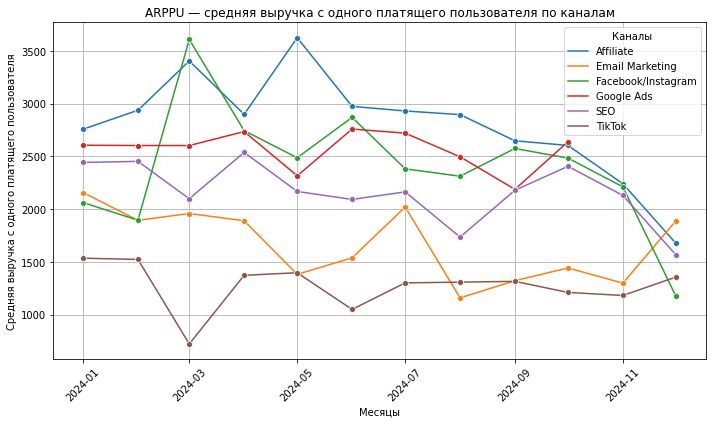

In [ ]:
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=arppu_acq,
    x='cohort_month',
    y='ARPPU',
    hue='acq_channel',
    marker='o'
)

plt.title('ARPPU — средняя выручка с одного платящего пользователя по каналам')
plt.xlabel('Месяцы')
plt.ylabel('Средняя выручка с одного платящего пользователя')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend(title='Каналы')
plt.tight_layout()
plt.show()

- В канале Google Ads средняя выручка с одного платящего пользователя просела мае и сентябре был спад, между спадами средняя выручка снижалась от максимума в июне до минимумасентябре. В октябре значение средней выручки как в начале года. За ноябрь и декабрь нет данных.

- В канале Tik Tok средняя выручка с одного платящего пользователя самая низкая. В марте средняя выручка была минимальной. В июне спад, далее выручка стабилизировалась на уровне ниже начала года. В январе средняя выручка была максимальной. В октябре, ноябре немного снизилась и подросла к декабрю.

- В канале Affilaite средняя выручка с одного платящего пользователя самая высокая, росла до марта. В марте был спад, в мае подъем. Далее спад до февральских значений и стабильный спад до конца года. В декабре сильный спад.

- В каналах Facebook/Instagram средняя выручка с одного платящего пользователя резко выросла в марте до максимального значения. Далее нестабильна, спад в мае и августе и плавный спад к концу года. В декабре резкий спад.

- В канале SEO средняя выручка с одного платящего пользователя также нестабильна, есть тенденция к снижению, есть спады в марте и августе. В декабре резкий спад.

- В канале Email Marketing  средняя выручка с одного платящего пользователя также нестабильна, есть тенденция к снижению, есть спады в мае и августе. В декабре резкий подъем.

В каналах Google Ads, Affilaite, SEO, Facebook/Instagram в декабре спад до минимального уровня, значительно меньшего, чем в начале года.

В канале Tik Tok и Email Marketing в декабре подъем, но уровень ниже чем в начале года

**Пока можно предположить такие причины падения выручки:**
- в каналах Google Ads и Affilaite  в июле были проведены маркетинговые компании, которые привели к резкому снижению количества пользователей
- в канале Google Ads в июле возникли технические неполадки, которые мешают пользователям в процессе оформления заказа
- в канал Google Ads перестали поступать даннные за ноябрь и декабрь, либо данные перестали собираться из-за технических проблем
- в канале Tik Tok с июня была проведена маркетинговая компания, которая привлекла большое количество непокупающих пользователей

**Посмотрим LTV, CAC и ROI каналов привлечения**

**LTV**

In [ ]:
# Считаем выручку по каналам и когортам 
cohort_revenue_acq = orders_users.groupby(['cohort_month', 'acq_channel'])['revenue'].sum().reset_index()

# Считаем число уникальных пользователей в когорте
cohort_users_acq = pa_diploma_users.groupby(['cohort_month', 'acq_channel'])['user_id'].nunique().reset_index(name='users')

# Считаем LTV 
ltv_acq = pd.merge(cohort_revenue_acq, cohort_users_acq, on=['cohort_month', 'acq_channel'])
ltv_acq['LTV'] = ltv_acq['revenue'] / ltv_acq['users']

**CAC**

In [ ]:
# Считаем общий бюджет по месяцам
monthly_budget_acq = pa_diploma_campaign_costs.groupby(['spend_month', 'acq_channel'])['budget'].sum().reset_index()

# Объединяем с числом пользователей
cac_acq = pd.merge(monthly_budget_acq, cohort_users_acq, left_on=['spend_month', 'acq_channel'], right_on=['cohort_month', 'acq_channel'], how='inner')
cac_acq['CAC'] = cac_acq['budget'] / cac_acq['users']

**ROI**

In [ ]:
# Объединяем ltv и cac
roi_acq = pd.merge(ltv_acq[['cohort_month', 'acq_channel', 'LTV']], cac_acq[['cohort_month', 'CAC']], on='cohort_month')

# ROI = (LTV - CAC) / CAC
roi_acq['ROI'] = (roi_acq['LTV'] - roi_acq['CAC']) / roi_acq['CAC']

In [ ]:
# Полная таблица эффективности по когортам
cohort_metrics_acq = pd.merge(ltv_acq[['cohort_month', 'acq_channel', 'LTV']], cac_acq[['cohort_month', 'CAC']], on='cohort_month')
cohort_metrics_acq['ROI'] = (cohort_metrics_acq['LTV'] - cohort_metrics_acq['CAC']) / cohort_metrics_acq['CAC']

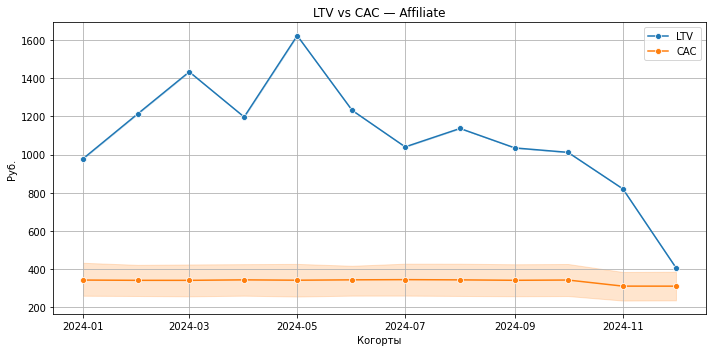

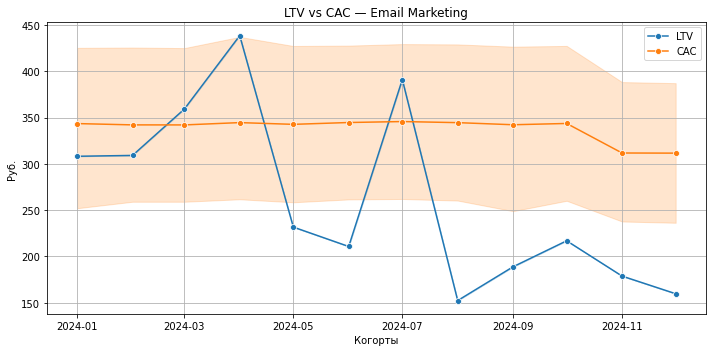

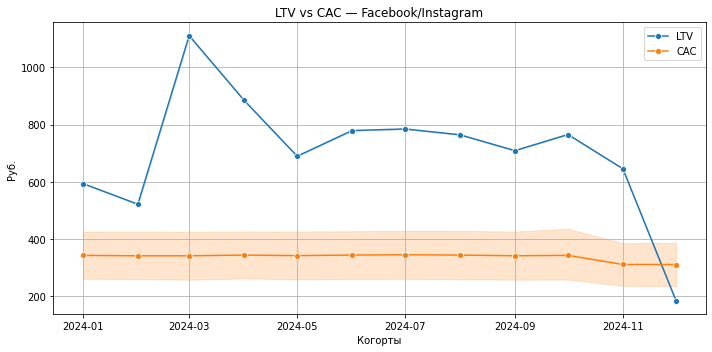

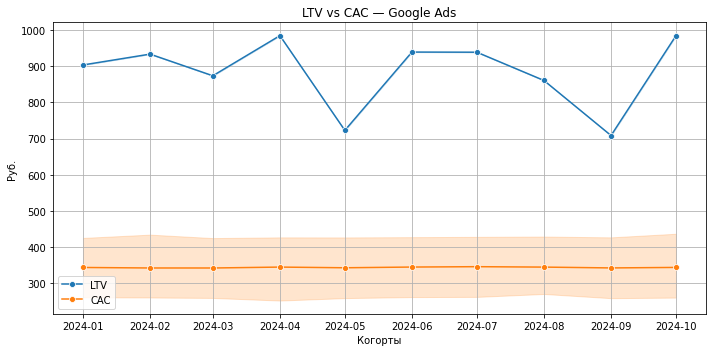

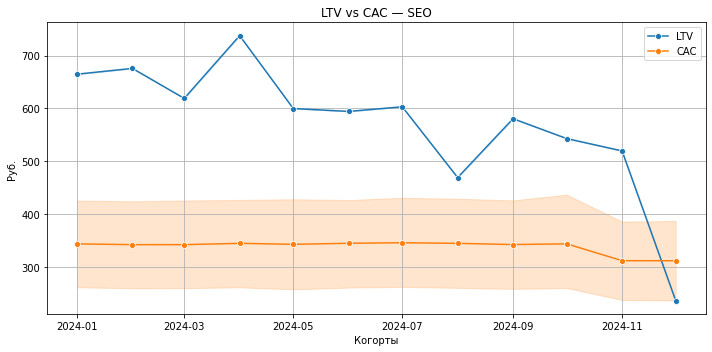

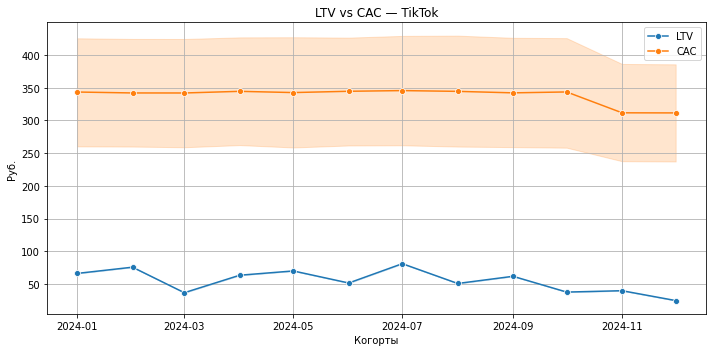

In [ ]:
channels = cohort_metrics_acq['acq_channel'].unique()

for channel in channels:
    data = cohort_metrics_acq[cohort_metrics_acq['acq_channel'] == channel]
    
    plt.figure(figsize=(10, 5))
    sns.lineplot(data=data, x='cohort_month', y='LTV', label='LTV', marker='o')
    sns.lineplot(data=data, x='cohort_month', y='CAC', label='CAC', marker='o')
    plt.title(f'LTV vs CAC — {channel}')
    plt.xlabel('Когорты')
    plt.ylabel('Руб.')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

- Канал Affilaite полностью окупается LTV значительно выше CAC, но есть сдад в LTV в апреле и к концу года LTV снижается пости до уровня САС в декабре
- В канале Email Marketing LTV неравномерный, выше САС только в марте, апреле и июле
- В канале Google Ads LTV более стабильный, всегда выше САС. Есть спады в мае и сентябре. Информации за ноябрь и декабрь нет
- В канале SEO LTV выше САС, есть подъем в апреле и спад в августе. С сентября тенденция к снижению, в декабре LTV ниже САС
- В канале Tik Tok LTV стабильный, но значительно ниже САС на протяжении всего года. Канал не окупается.

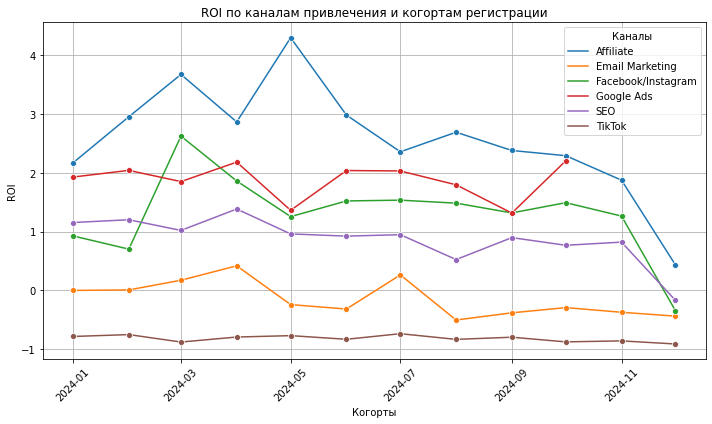

In [ ]:
# Строим график ROI
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=cohort_metrics_acq,
    x='cohort_month',
    y='ROI',
    hue='acq_channel',
    marker='o',
    ci=None
)
plt.title('ROI по каналам привлечения и когортам регистрации')
plt.xlabel('Когорты')
plt.ylabel('ROI')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend(title='Каналы')
plt.tight_layout()
plt.show()

- В канале Affilaite самый высокий ROI, но есть спад в апреле и к концу года LTV снижается пости до минимальной отметки, ниже начала года
- В канале Email Marketing ROI более равномерныйесть тенденция к снижению
- В канале Google Ads ROI более стабильный. Есть спад в мае и сентябре. В октябре максимальное значение. Информации за ноябрь и декабрь нет
- В канале SEO ROI стабильный, есть подъем в апреле и спад в августе. В декабре снижение до минимального уровня
- В канале Tik Tok ROI стабильный, но самый низкий из всех каналов

**Посмотрим данные по другим сегментам**

**Выручка по регионам и когортам привлечения**

In [ ]:
# Проверим выручку по регионам и когортам привлечения
revenue_region_month = orders_users.groupby(['cohort_month', 'region'])['revenue'].sum().reset_index(name='revenue_region')

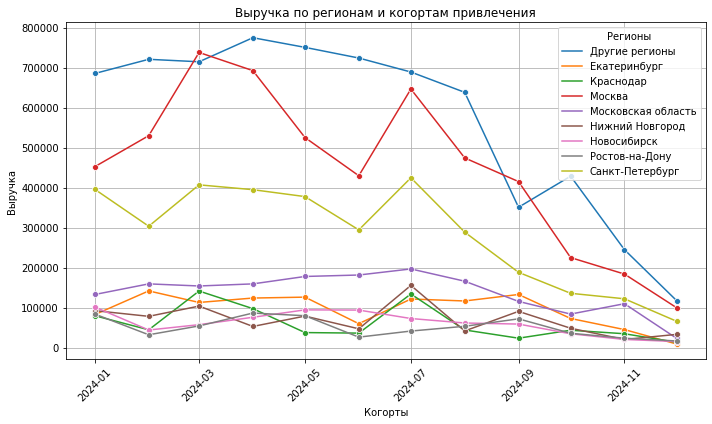

In [ ]:
# Строим график
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=revenue_region_month,
    x='cohort_month',
    y='revenue_region',
    hue='region',
    marker='o'
)

plt.title('Выручка по регионам и когортам привлечения')
plt.xlabel('Когорты')
plt.ylabel('Выручка')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend(title='Регионы')
plt.tight_layout()
plt.show()

Самая высокая выручка в регионах Москва, Санкт-Петербург и Московская область.

- В регионах Москва и Санкт-Петербург спад в июне, восстановление метрики в июле. Далее стабильный спад в несколько раз до минимальных значений к концу года.
- В Московской области выручка без резких колебаний, но также значительный спад в когортах конца года
- В регионах Нижний Новгород, Краснодар, Екатеринбург, Ростов на Дону в июне просадка выручки и плавное снижение к концу года до минимальных значений
- В регионах Новосибирск и Московская область выручка без резких колебаний, но также снижается до минимума к концу года

**Выручка по возрастным группам и когортам регистрации**

In [ ]:
# Выделим возрастные группы
def age_group(age):
    if age <= 20:
        return '18–20'
    elif age <= 25:
        return '21–25'
    elif age <= 35:
        return '26–35'
    elif age <= 50:
        return '36–50'
    elif age <= 60:
        return '51–60'
    elif age <= 70:
        return '61–70'
    else:
        return '70+'

orders_users['age_group'] = orders_users['age'].apply(age_group)

In [ ]:
# Считаем выручку по возрастным группам и когортам регистрации
revenue_by_age_group = orders_users.groupby(['cohort_month', 'age_group'])['revenue'].sum().reset_index()

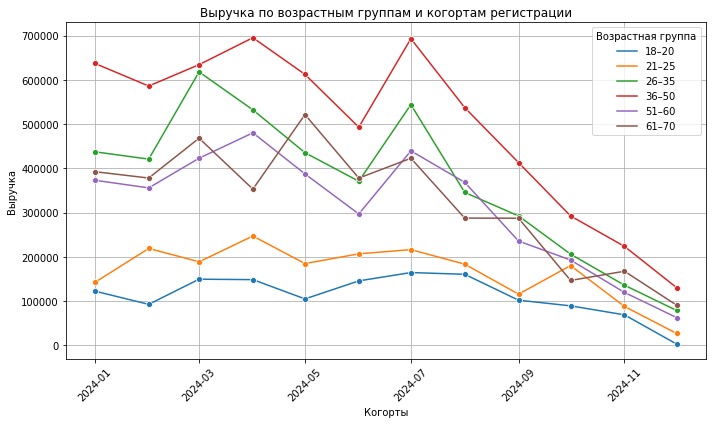

In [ ]:
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=revenue_by_age_group,
    x='cohort_month',
    y='revenue',
    hue='age_group',
    marker='o'
)

plt.title('Выручка по возрастным группам и когортам регистрации')
plt.xlabel('Когорты')
plt.ylabel('Выручка')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend(title='Возрастная группа')
plt.tight_layout()
plt.show()


Самая высокая выручка в возрастной группе 36-50 лет. До 50 лет, чем "моложе" группа, тем меньше выручка. Старше 50 выручка также снижается.

Во всех возрастных группах виден тот же резкий спад выручки, начиная с августа. Меньше всего спад выражен в группах 18-20 и 21-25.

Во всех возрастных группах выучка в когортах второго полугодия идет вниз до минимальных значений в декабре.

**Выручка по сегментам покупателей и когортам регистрации**

In [ ]:
# Проверим выручку по сегментам покупателей и когортам регистрации
revenue_buyer_segment_month = orders_users.groupby(['cohort_month', 'buyer_segment'])['revenue'].sum().reset_index()

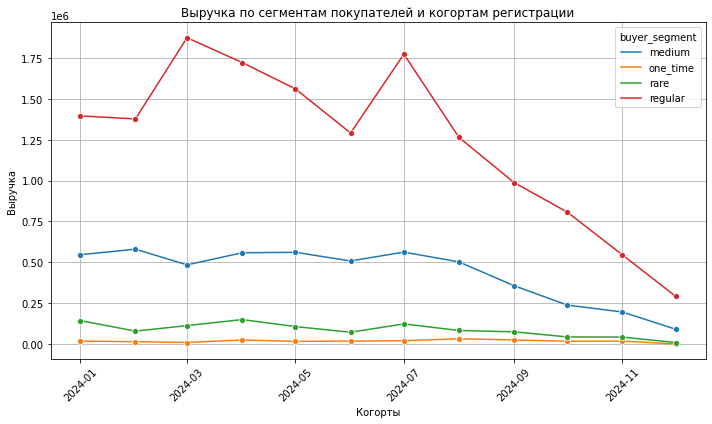

In [ ]:
# Строим график
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=revenue_buyer_segment_month,
    x='cohort_month',
    y='revenue',
    hue='buyer_segment',
    marker='o'
)

plt.title('Выручка по сегментам покупателей и когортам регистрации')
plt.xlabel('Когорты')
plt.ylabel('Выручка')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend(title='buyer_segment')
plt.tight_layout()
plt.show()

Наибольшую выручку приносят регулярно покупающие пользователи. Выручка именно этой группы имеет просадку в июне и сильнее всего посела после августа до конца года. Похожая тенденция в группе medium, но изменения более плавные. В группах с редкими и одиночными покупками ищзменения почти не видны.

**Выручка по категории товара и когортам регистрации**

In [ ]:
# Проверим выручку по категории товара и когортам регистрации
revenue_category_name_month = orders_users.groupby(['cohort_month', 'category_name'])['revenue'].sum().reset_index()
#revenue_category_name_month = revenue_category_name_month[revenue_category_name_month['revenue'] > 150000]

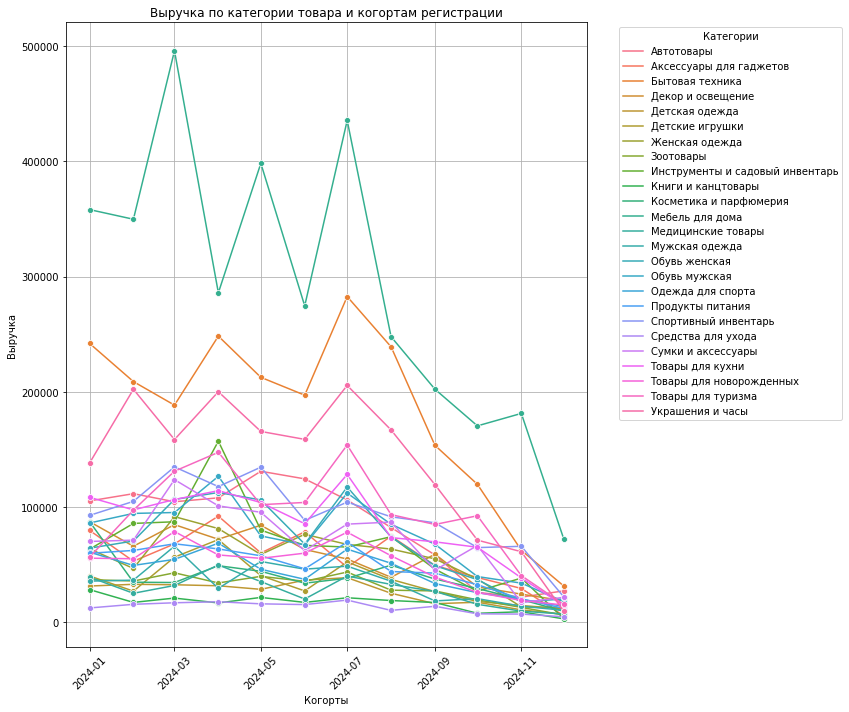

In [ ]:
# Строим график
plt.figure(figsize=(12, 10))
sns.lineplot(
    data=revenue_category_name_month,
    x='cohort_month',
    y='revenue',
    hue='category_name',
    marker='o'
)

plt.title('Выручка по категории товара и когортам регистрации')
plt.xlabel('Когорты')
plt.ylabel('Выручка')
plt.xticks(rotation=45)
plt.grid(True)
# Легенда справа от графика
plt.legend(title='Категории', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Наибольшую выручку приносят категории дорогих товаров: бытовая техника, мебельдля дома, украшения и часы

**Выручка по браузерам и когортам регистрации**

In [ ]:
# Проверим выручку по браузерам и когортам регистрации
revenue_browser_month = orders_users.groupby(['cohort_month', 'browser'])['revenue'].sum().reset_index()

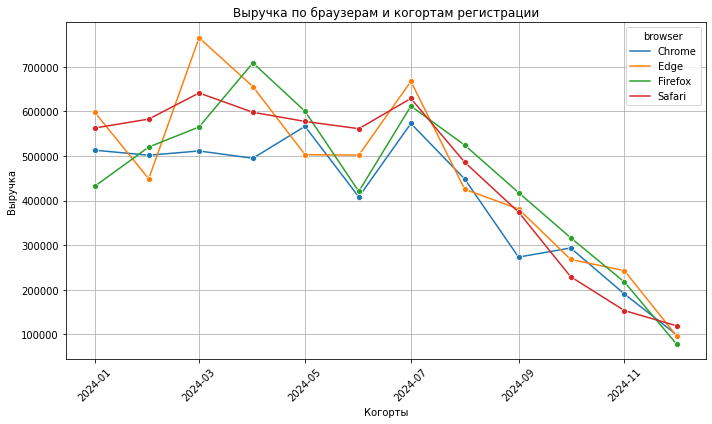

In [ ]:
# Строим график
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=revenue_browser_month,
    x='cohort_month',
    y='revenue',
    hue='browser',
    marker='o'
)

plt.title('Выручка по браузерам и когортам регистрации')
plt.xlabel('Когорты')
plt.ylabel('Выручка')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend(title='browser')
plt.tight_layout()
plt.show()

По всем браузерам выручка распределяется схожим образом - со спадом начиная с августа

В сегментах `device`, `os`, `user_segment`, `gender` выручка распределяется одинаково с таким же спадом с августа

**Посмотрим как распределяется по сегментам число заказов**

**Количество заказов по регионам и когортам регистрации**

In [ ]:
# Считаем количество заказов по регионам и когортам регистрации
orders_region = orders_users.groupby(['cohort_month', 'region'])['order_id'].nunique().reset_index(name='count_orders')

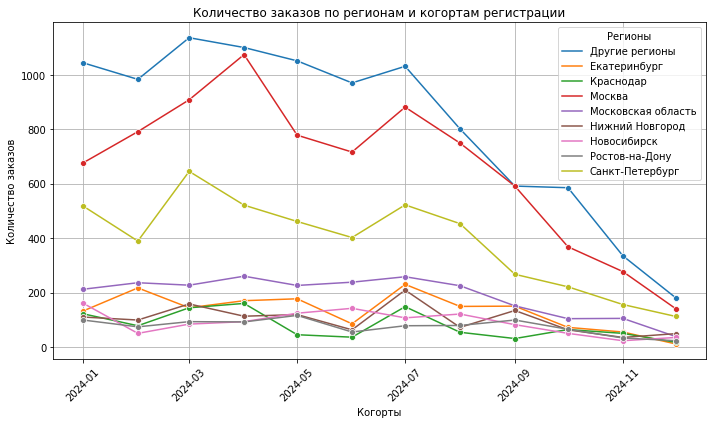

In [ ]:
# Строим график
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=orders_region,
    x='cohort_month',
    y='count_orders',
    hue='region',
    marker='o'
)

plt.title('Количество заказов по регионам и когортам регистрации')
plt.xlabel('Когорты')
plt.ylabel('Количество заказов')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend(title='Регионы')
plt.tight_layout()
plt.show()

Наибольшее количество заказов в Москве и Санкт-Петербурге. Просадка в июне и спад с августа в этих регионах повтряется. В  Московской области и других регионах график более плавный, без резких колебаний, спад небольшой.

**Количество заказов по возрастам и когортам привлечения**

In [ ]:
# Считаем количество заказов по возрастам и когортам привлечения
orders_by_age_group = orders_users.groupby(['cohort_month', 'age_group'])['order_id'].nunique().reset_index(name='count_orders')

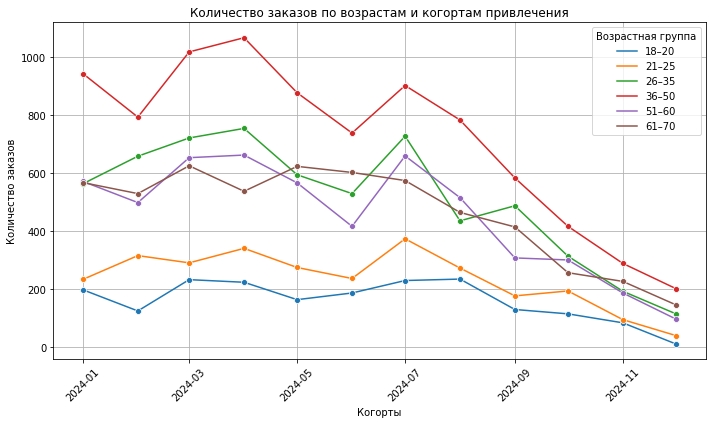

In [ ]:
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=orders_by_age_group,
    x='cohort_month',
    y='count_orders',
    hue='age_group',
    marker='o'
)

plt.title('Количество заказов по возрастам и когортам привлечения')
plt.xlabel('Когорты')
plt.ylabel('Количество заказов')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend(title='Возрастная группа')
plt.tight_layout()
plt.show()

Самое высокое количество заказов в возрастной группе 36-50 лет. До 50 лет, чем "моложе" группа, тем меньше количество заказов. Старше 50 количество заказов также снижается.

Во всех возрастных группах виден тот же резкий спад количества заказов, начиная с августа. Меньше всего спад выражен в группах 18-20 и 21-25.

Во всех возрастных группах количество заказов в когортах второго полугодия идет вниз до минимальных значений в декабре.

**Количество заказов по сегментам покупателей и когортам регистрации**

In [ ]:
# Считаем количество заказов по сегментам покупателей и когортам регистрации
orders_buyer_segment = orders_users.groupby(['cohort_month', 'buyer_segment'])['order_id'].nunique().reset_index(name='count_orders')

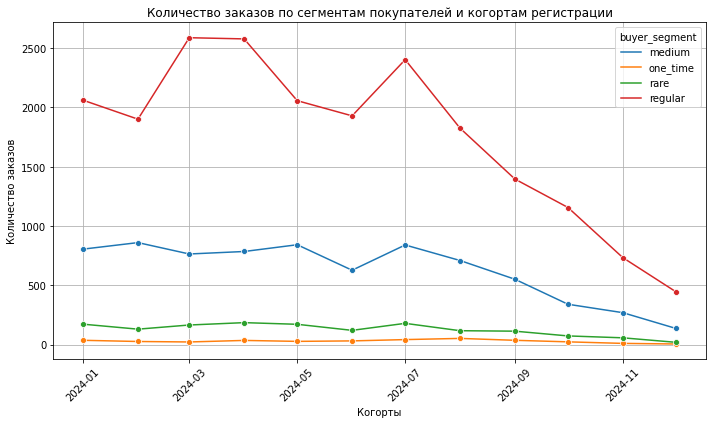

In [ ]:
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=orders_buyer_segment,
    x='cohort_month',
    y='count_orders',
    hue='buyer_segment',
    marker='o'
)

plt.title('Количество заказов по сегментам покупателей и когортам регистрации')
plt.xlabel('Когорты')
plt.ylabel('Количество заказов')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend(title='buyer_segment')
plt.tight_layout()
plt.show()

Наибольшее количество заказов приносят регулярно покупающие пользователи. Количество заказов именно этой группы имеет просадку в июне и сильнее всего просела после августа до конца года. Похожая тенденция в группе medium, но изменения более плавные. В группах с редкими и одиночными покупками изменения почти не видны.

**Количество заказов по категории товара и когортам регистрации**

In [ ]:
# Считаем количество заказов по категории товара и когортам регистрации
orders_category_name = orders_users.groupby(['cohort_month', 'category_name'])['order_id'].nunique().reset_index(name='count_orders')
#orders_category_name = orders_category_name[orders_category_name['count_orders'] < 200]

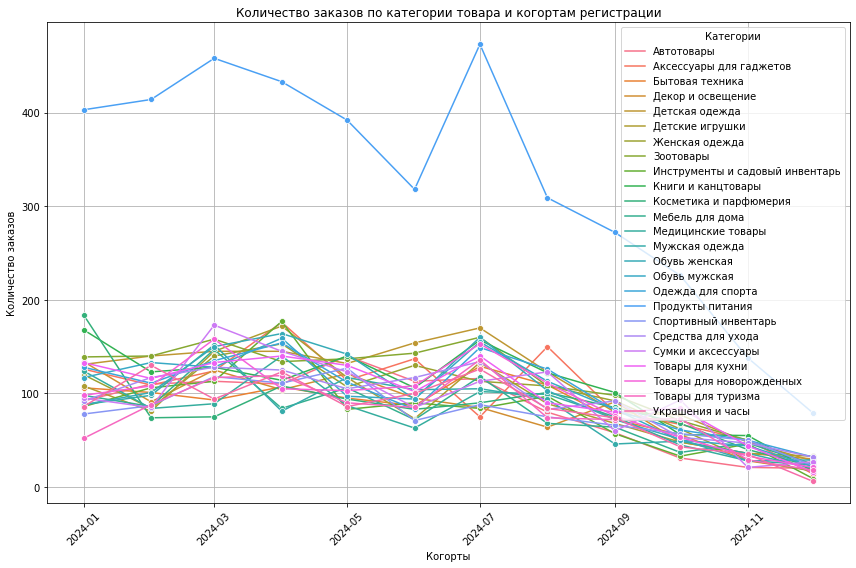

In [ ]:
plt.figure(figsize=(12, 8))
sns.lineplot(
    data=orders_category_name,
    x='cohort_month',
    y='count_orders',
    hue='category_name',
    marker='o'
)

plt.title('Количество заказов по категории товара и когортам регистрации')
plt.xlabel('Когорты')
plt.ylabel('Количество заказов')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend(title='Категории')
plt.tight_layout()
plt.show()

Количество заказов в категории Продукты питания в 3-4 раза выше, чем в других категориях. Именнно в этой категории сильно выражена просадка в июне и спад, начиная с августа.

В сегментах `device`, `os`, `user_segment`, `gender`, `browser` количество заказов распределяется одинаково с таким же спадом с августа

**Конверсия в покупку по регионам и когортам регистрации**

In [ ]:
# Присоединяем дату регистрации и каналы к заказам
orders_with_users_cogort_region = pd.merge(pa_diploma_orders, pa_diploma_users[['user_id', 'cohort_month', 'region']], on='user_id', how='left')

In [ ]:
# Размер каждой когорты
cohort_sizes_region = pa_diploma_users.groupby(['cohort_month', 'region'])['user_id'].nunique().reset_index()
cohort_sizes_region.rename(columns={'user_id': 'cohort_size'}, inplace=True)

# Сколько пользователей из каждой когорты сделали хотя бы один заказ
converted_users_region = orders_with_users_cogort_region.groupby(['cohort_month', 'region'])['user_id'].nunique().reset_index()
converted_users_region.rename(columns={'user_id': 'paying_users'}, inplace=True)

# Считаем конверсию по регионам и когортам регистрации
conversion_region = pd.merge(cohort_sizes_region, converted_users_region, on=['cohort_month', 'region'], how='left')
conversion_region['conversion_region'] = conversion_region['paying_users'] * 100 / conversion_region['cohort_size']

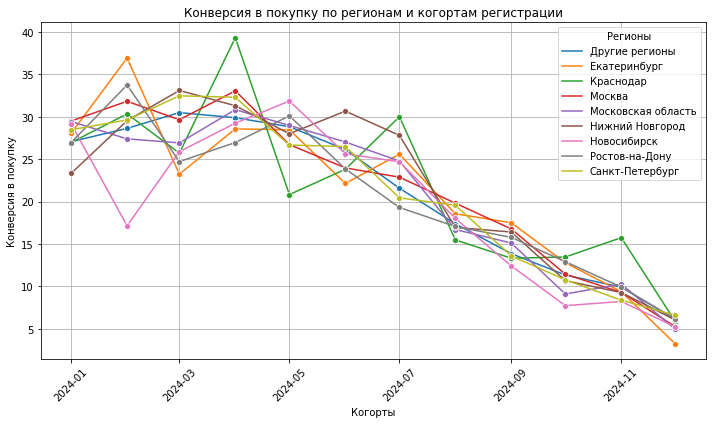

In [ ]:
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=conversion_region,
    x='cohort_month',
    y='conversion_region',
    hue='region',
    marker='o'
)

plt.title('Конверсия в покупку по регионам и когортам регистрации')
plt.xlabel('Когорты')
plt.ylabel('Конверсия в покупку')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend(title='Регионы')
plt.tight_layout()
plt.show()

Конверсия в покупку по регионам практически не отличается. В Екатеринбурге, Новосибирске и Краснодаре больший разброс значений. Резкого спада в июле и августе нет. Есть равномерный сильный спад к концу года с июня.

**Конверсия в покупку по возрастам и когортам регистрации**

In [ ]:
# Выделим возрастные группы
pa_diploma_users['age_group'] = pa_diploma_users['age'].apply(age_group)

In [ ]:
# Размер каждой когорты
cohort_sizes_age = pa_diploma_users.groupby(['cohort_month', 'age_group'])['user_id'].nunique().reset_index()
cohort_sizes_age.rename(columns={'user_id': 'cohort_size'}, inplace=True)

# Сколько пользователей из каждой когорты сделали хотя бы один заказ
converted_users_age = orders_users.groupby(['cohort_month', 'age_group'])['user_id'].nunique().reset_index()
converted_users_age.rename(columns={'user_id': 'paying_users'}, inplace=True)

# Считаем конверсию по регионам и когортам регистрации
conversion_age = pd.merge(cohort_sizes_age, converted_users_age, on=['cohort_month', 'age_group'], how='left')
conversion_age['conversion_age'] = conversion_region['paying_users'] * 100 / conversion_region['cohort_size']

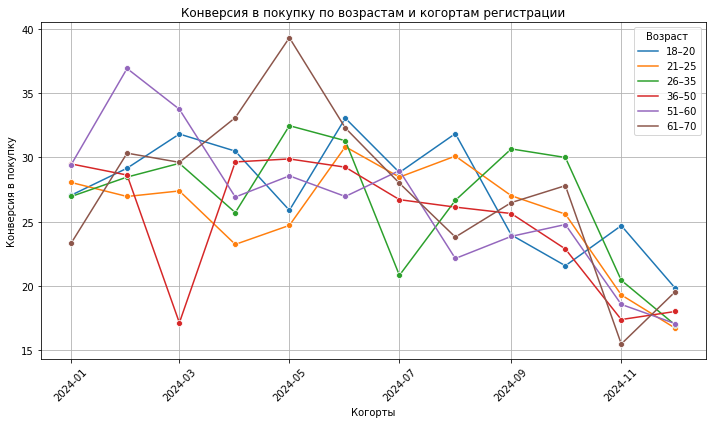

In [ ]:
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=conversion_age,
    x='cohort_month',
    y='conversion_age',
    hue='age_group',
    marker='o'
)

plt.title('Конверсия в покупку по возрастам и когортам регистрации')
plt.xlabel('Когорты')
plt.ylabel('Конверсия в покупку')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend(title='Возраст')
plt.tight_layout()
plt.show()

Конверсия в покупку по возрастам неравномерна, есть разброс. Сильная просадка в марте  у группы 36-50, подъем в мае в группе 61-70. В целом категоии ведут себя схожим образом. Спада в июле и августе нет. Есть спад к ноябрю во всех группах, кроме 18-20.

**Конверсия в покупку по браузерам и когортам регистрации**

In [ ]:
# Присоединяем дату регистрации и браузеры к заказам
orders_with_users_cogort_browser = pd.merge(pa_diploma_orders, pa_diploma_users[['user_id', 'cohort_month', 'browser']], on='user_id', how='left')

In [ ]:
# Размер каждой когорты
cohort_sizes_browser = pa_diploma_users.groupby(['cohort_month', 'browser'])['user_id'].nunique().reset_index()
cohort_sizes_browser.rename(columns={'user_id': 'cohort_size'}, inplace=True)

# Сколько пользователей из каждой когорты сделали хотя бы один заказ
converted_users_browser = orders_with_users_cogort_browser.groupby(['cohort_month', 'browser'])['user_id'].nunique().reset_index()
converted_users_browser.rename(columns={'user_id': 'paying_users'}, inplace=True)

# Считаем конверсию по регионам и когортам регистрации
conversion_browser = pd.merge(cohort_sizes_browser, converted_users_browser, on=['cohort_month', 'browser'], how='left')
conversion_browser['conversion_browser'] = conversion_region['paying_users'] * 100 / conversion_region['cohort_size']

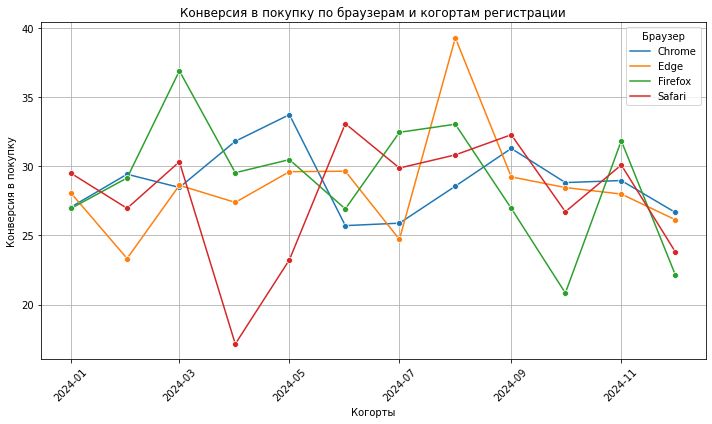

In [ ]:
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=conversion_browser,
    x='cohort_month',
    y='conversion_browser',
    hue='browser',
    marker='o'
)

plt.title('Конверсия в покупку по браузерам и когортам регистрации')
plt.xlabel('Когорты')
plt.ylabel('Конверсия в покупку')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend(title='Браузер')
plt.tight_layout()
plt.show()

Конверсия в покупку в целом схожа в разных браузерах. В Safari сильная просадка в мае, в Firefox просадка в октябре. Скачок в Firefox в марте и в Edge в августе.

**Конверсия в покупку по сегментам покупателей и когортам регистрации**

In [ ]:
# Присоединяем дату регистрации и сегменты покупателей к заказам
orders_with_users_cogort_buyer_segment = pd.merge(pa_diploma_orders, pa_diploma_users[['user_id', 'cohort_month', 'buyer_segment']], on='user_id', how='left')

In [ ]:
# Размер каждой когорты
cohort_sizes_buyer_segment = pa_diploma_users.groupby(['cohort_month', 'buyer_segment'])['user_id'].nunique().reset_index()
cohort_sizes_buyer_segment.rename(columns={'user_id': 'cohort_size'}, inplace=True)

# Сколько пользователей из каждой когорты сделали хотя бы один заказ
converted_users_buyer_segment = orders_with_users_cogort_buyer_segment.groupby(['cohort_month', 'buyer_segment'])['user_id'].nunique().reset_index()
converted_users_buyer_segment.rename(columns={'user_id': 'paying_users'}, inplace=True)

# Считаем конверсию по регионам и когортам регистрации
conversion_buyer_segment = pd.merge(cohort_sizes_buyer_segment, converted_users_buyer_segment, on=['cohort_month', 'buyer_segment'], how='left')
conversion_buyer_segment['conversion_buyer_segment'] = conversion_buyer_segment['paying_users'] * 100 / conversion_buyer_segment['cohort_size']

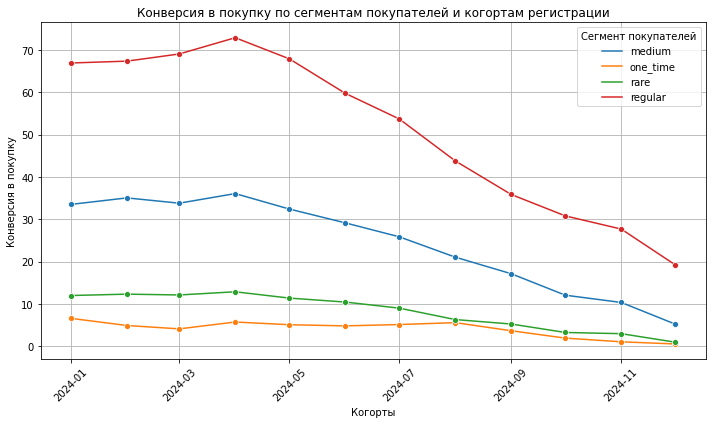

In [ ]:
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=conversion_buyer_segment,
    x='cohort_month',
    y='conversion_buyer_segment',
    hue='buyer_segment',
    marker='o'
)

plt.title('Конверсия в покупку по сегментам покупателей и когортам регистрации')
plt.xlabel('Когорты')
plt.ylabel('Конверсия в покупку')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend(title='Сегмент покупателей')
plt.tight_layout()
plt.show()

Конверсия по сегментам покупателей сильно отличается. Наибольшая конверсия у регулярно покупающих пользователей, в два раза меньше у сегмента medium. В этих сегментах наибольшая тенденция к спаду с апреля до конца года. В остальных сегментах конверсия более стабильна, с небольшим спадом.

В сегментах `device`, `os`, `user_segment`, `gender`, `browser` конверсия распределяется практически одинаково. В сегментах `os`, `user_segment` с таким же спадом с августа. В сегментах `device`, `gender`, `browser` спад равномерный с апреля.

**Средний чек по категорям товаров и когортам регистрации**

In [ ]:
# Посчитаем средний чек по категорям товаров и когортам регистрации
aov_category_name = orders_users.groupby(['cohort_month', 'category_name'])['total_price'].mean().reset_index(name='aov_category_name')
#aov_category_name = aov_device[aov_device['aov_category_name'] > 30000]

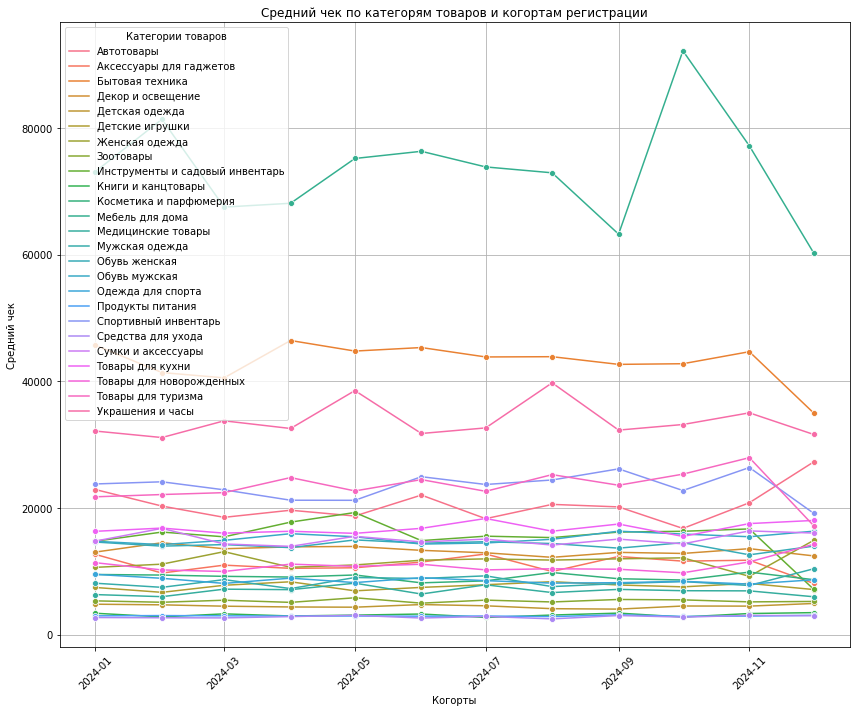

In [ ]:
plt.figure(figsize=(12, 10))
sns.lineplot(
    data=aov_category_name,
    x='cohort_month',
    y='aov_category_name',
    hue='category_name',
    marker='o'
)

plt.title('Средний чек по категорям товаров и когортам регистрации')
plt.xlabel('Когорты')
plt.ylabel('Средний чек')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend(title='Категории товаров')
plt.tight_layout()
plt.show()

Самый высокий средний чек в категориях с дорогими товарами: Домашняя мебель, Бытовая техника, Украшения и часы. В течение года средние чеки довольно стабильны. В категории Домашняя мебель есть спад в сентябре и подъем в октябре.

Средние чеки по другим сегментам ведут себя практически одинаково. Характерных изменений не выявлено.

**Можно дальше исследовать конверсию и посмотреть воронку оформления заказа, чтобы понять на каком этапе покупки возникают сложности**

Посмотрим, через сколько дней после регистрации пользователи оформляют заказ.

Посчитаем среднее время от регистрации до завершения оформления заказа.

In [ ]:
# Отфильтруем события checkout_complete
filtered_event = pa_diploma_events[pa_diploma_events['event_type'] == 'checkout_complete']

# Присоединяем дату регистрации
filtered_event = filtered_event.merge(pa_diploma_users[['user_id', 'registration_date', 'acq_channel', 'cohort_month']], on='user_id')

# Вычисляем разницу в днях между checkout_complete и регистрацией
filtered_event['diff_days'] = (filtered_event['event_date'] - filtered_event['registration_date']).dt.days
filtered_event = filtered_event[filtered_event['diff_days'] >= 0]  # оставляем только положительные разницы

# Среднее время до оформления заказа по каналам привлечения
avg_checkout_acq = filtered_event.groupby(['cohort_month', 'acq_channel'])['diff_days'].mean().reset_index(name='avg_checkout_acq')

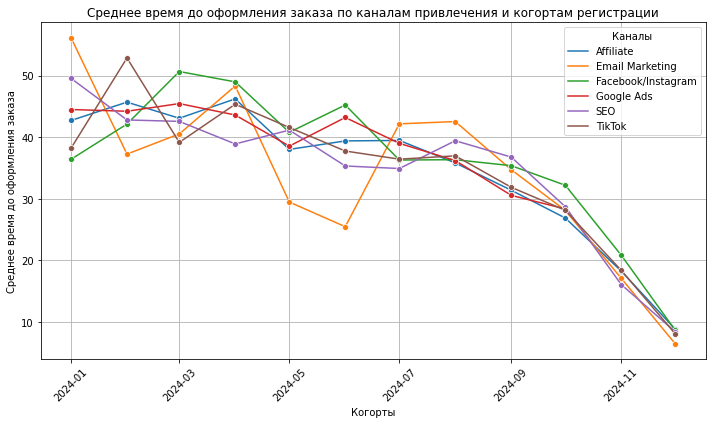

In [ ]:
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=avg_checkout_acq,
    x='cohort_month',
    y='avg_checkout_acq',
    hue='acq_channel',
    marker='o'
)

plt.title('Среднее время до оформления заказа по каналам привлечения и когортам регистрации')
plt.xlabel('Когорты')
plt.ylabel('Среднее время до оформления заказа')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend(title='Каналы')
plt.tight_layout()
plt.show()

In [ ]:
# Среднее время до оформления заказа по сегментам пользователей
avg_checkout_user_segment = filtered_event.groupby(['cohort_month', 'user_segment'])['diff_days'].mean().reset_index(name='avg_checkout_user_segment')

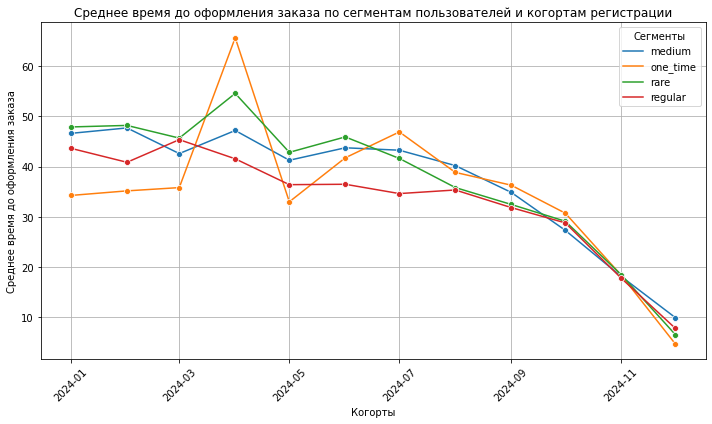

In [ ]:
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=avg_checkout_user_segment,
    x='cohort_month',
    y='avg_checkout_user_segment',
    hue='user_segment',
    marker='o'
)

plt.title('Среднее время до оформления заказа по сегментам пользователей и когортам регистрации')
plt.xlabel('Когорты')
plt.ylabel('Среднее время до оформления заказа')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend(title='Сегменты')
plt.tight_layout()
plt.show()

По каналам и сегментам пользователи ведут себя практически одинаково. Больший разброс у канала Email Marketing  и сегмента one_time.

В среднем пользователи оформляют первый заказ через 35-50 дней после регистрации. Это довольно много для маркетплейса.

<div class="alert alert-info">
<b>Комментарий студента (после принятия проекта)</b> 
    
Посмотрим, через сколько дней после регистрации пользователи совершают первую покупку. Дополнила выводы.
    
</div>

In [ ]:
# Вычислим дату первого заказа
orders_users_filtered = orders_users.copy()
orders_users_filtered['first_order_date'] = orders_users_filtered.groupby('user_id')['order_date'].min()

In [ ]:
# Вычисляем разницу в днях между совершением покупки и регистрацией
orders_users_filtered['diff_days'] = (orders_users_filtered['first_order_date'] - orders_users_filtered['registration_date']).dt.days
orders_users_filtered = orders_users_filtered[orders_users_filtered['diff_days'] >= 0]  # оставляем только положительные разницы

# Среднее время до первой покупки по каналам привлечения
avg_purschace_acq = orders_users_filtered.groupby(['cohort_month', 'acq_channel'])['diff_days'].mean().reset_index(name='avg_purschace_acq')

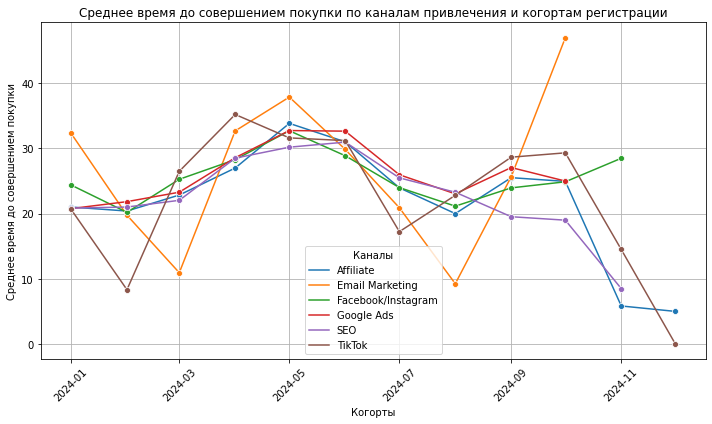

In [ ]:
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=avg_purschace_acq,
    x='cohort_month',
    y='avg_purschace_acq',
    hue='acq_channel',
    marker='o'
)

plt.title('Среднее время до совершением покупки по каналам привлечения и когортам регистрации')
plt.xlabel('Когорты')
plt.ylabel('Среднее время до совершением покупки')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend(title='Каналы')
plt.tight_layout()
plt.show()

In [ ]:
# Среднее время до первой покупки по сегментам пользователей
avg_purschace_user_segment = orders_users_filtered.groupby(['cohort_month', 'user_segment'])['diff_days'].mean().reset_index(name='avg_purschace_user_segment')

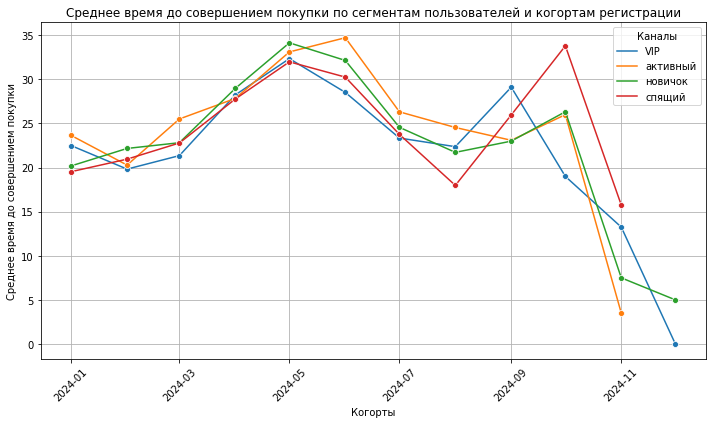

In [ ]:
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=avg_purschace_user_segment,
    x='cohort_month',
    y='avg_purschace_user_segment',
    hue='user_segment',
    marker='o'
)

plt.title('Среднее время до совершением покупки по сегментам пользователей и когортам регистрации')
plt.xlabel('Когорты')
plt.ylabel('Среднее время до совершением покупки')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend(title='Каналы')
plt.tight_layout()
plt.show()

**Построим воронку по шагам: product_view, add_to_cart, checkout_start, checkout_complete**

In [ ]:
# Добавим регистрацию к событиям
registration_events = pa_diploma_users[['user_id', 'registration_date']].copy()
registration_events['event_type'] = 'registration'
registration_events.rename(columns={'registration_date': 'event_date'}, inplace=True)

# Добавим оплату заказа из таблицы с заказами
payment_events = pa_diploma_orders[['user_id', 'order_date']].copy()
payment_events['event_type'] = 'payment'
payment_events.rename(columns={'order_date': 'event_date'}, inplace=True)

# Приводим к одному формату с pa_diploma_events
event_columns = ['user_id', 'event_date', 'event_type']
registration_events = registration_events[event_columns]
payment_events = payment_events[event_columns]
events_reg_pay = pd.concat([pa_diploma_events[event_columns], registration_events, payment_events], ignore_index=True)

In [ ]:
# Задаём порядок шагов в воронке
funnel_steps = ['registration', 'product_view', 'add_to_cart', 'checkout_start', 'checkout_complete', 'payment']

# Фильтруем датасет, оставляя только нужные шаги воронки
funnel_df_steps = events_reg_pay[events_reg_pay['event_type'].isin(funnel_steps)]

# Считаем число уникальных пользователей на каждом шаге
funnel_counts = funnel_df_steps.groupby('event_type')['user_id'].nunique().reindex(funnel_steps)

# Собираем таблицу воронки
funnel_df = pd.DataFrame({
    'step': funnel_steps,
    'users': funnel_counts.values
})
# Добавляем конверсии и округляем до 1 знака после запятой
funnel_df['conversion_from_first_%'] = (funnel_df['users'] / funnel_df['users'].iloc[0] * 100).round(1)
funnel_df['conversion_from_previous_%'] = (funnel_df['users'] / funnel_df['users'].shift(1) * 100).round(1)

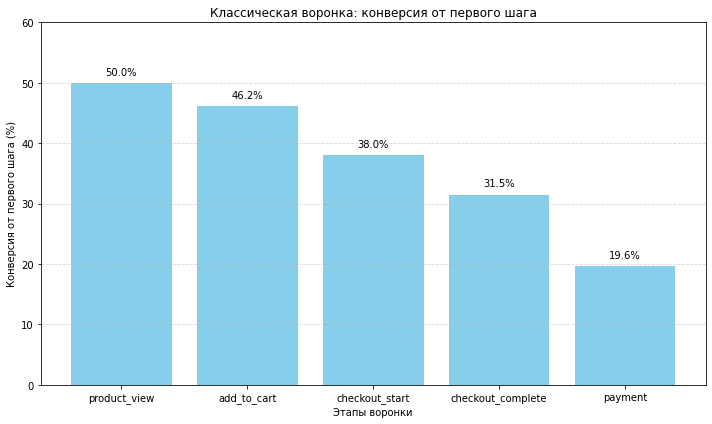

In [ ]:
# Визуализируем данные, кроме первого шага, чтобы не выводить NaN
plt.figure(figsize=(10, 6))

# Строим barplot
bars = plt.bar(funnel_df['step'][1:], funnel_df['conversion_from_first_%'][1:], color='skyblue')

# Добавляем подписи значений на каждый столбец
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,   # координата X — центр столбца
        height + 1,                          # немного выше столбца
        f'{height:.1f}%',                    # значение с 1 знаком после запятой
        ha='center', va='bottom', fontsize=10
    )

plt.title('Классическая воронка: конверсия от первого шага')
plt.ylabel('Конверсия от первого шага (%)')
plt.xlabel('Этапы воронки')
plt.ylim(0, max(funnel_df['conversion_from_first_%'][1:]) + 10)  # немного увеличим верхнюю границу
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

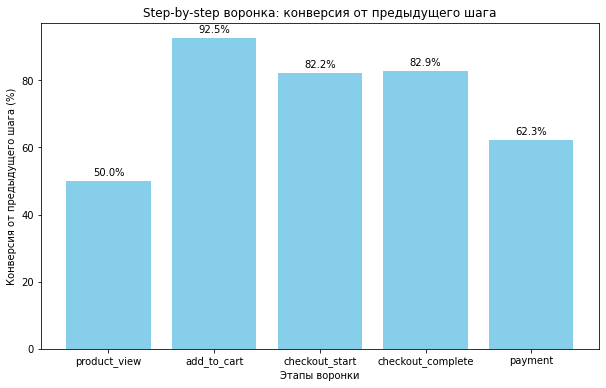

In [ ]:
# Визуализируем данные, кроме первого шага, чтобы не выводить NaN
plt.figure(figsize=(10, 6))
# Строим barplot

# Строим barplot
bars = plt.bar(funnel_df['step'][1:], funnel_df['conversion_from_previous_%'][1:], color='skyblue')

# Добавляем подписи значений на каждый столбец
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,   # координата X — центр столбца
        height + 1,                          # немного выше столбца
        f'{height:.1f}%',                    # значение с 1 знаком после запятой
        ha='center', va='bottom', fontsize=10
    )

plt.title('Step-by-step воронка: конверсия от предыдущего шага')
plt.ylabel('Конверсия от предыдущего шага (%)')
plt.xlabel('Этапы воронки')
plt.show()

В `Классической воронке` из регистрации в просмотр страницы товара переходит 50% пользователей. Убывание числа пользователей равномерное при прохождении всех этапов.

В воронке `Step-by-step` наибольшее число пользователей теряется при переходе со страницы регистрации на просмотр страницы товара, а также из окончания оформления заказа в оплату заказа.

Половина пользователей не взаимодействует с товарами.
Только 50% зарегистрированных пользователей просмотрели хотя бы один товар.

Возможно:
- интерфейс не вовлекает сразу после регистрации
- нет персональных рекомендаций
- слабый онбординг
- регистрация была случайной/принудительной

Высокая конверсия с просмотра товара до корзины (92,5%).
Из тех, кто смотрит товар, почти все добавляют его в корзину.

Значит:
- товары релевантны
- пользователи замотивированы
- возможно, сравнивают товары в корзине или используют её как «избранное»

Потери на этапе оплаты (−38%)
Из checkout_complete в payment конверсия падает. 37,7% — не платят:

Возможные причины:
- сложности с оплатой (технические ошибки, неудобная оплата)
- высокая итоговая стоимость, например, из-за доставки
- накрутки, мошеннические/фейковые заказы

Проверим, возникает ли эта проблема на всех типах устройств

In [ ]:
# Получим первое устройство каждого пользователя (по дате)
first_device = pa_diploma_events.sort_values(by='event_date').groupby('user_id')['device'].first().reset_index()

# Добавим device к регистрации
registration_events = registration_events.merge(first_device, on='user_id', how='left')

# Добавим device к оплате
payment_events = payment_events.merge(first_device, on='user_id', how='left')

# Объединяем все события, включая регистрации и оплаты с device
events_reg_pay = pd.concat(
    [pa_diploma_events[event_columns + ['device']],
     registration_events[event_columns + ['device']],
     payment_events[event_columns + ['device']]],
    ignore_index=True
)

In [ ]:
# Получим всех user_id, у кого есть регистрация
registered_users = events_reg_pay[events_reg_pay['event_type'] == 'registration']['user_id'].unique()

# Оставим в events_reg_pay только зарегистрированных
events_reg_pay = events_reg_pay[events_reg_pay['user_id'].isin(registered_users)]

In [ ]:
# Разделим данные по устройствам
mobile_df = events_reg_pay[events_reg_pay['device'] == 'mobile']
desktop_df = events_reg_pay[events_reg_pay['device'] == 'desktop']
tablet_df = events_reg_pay[events_reg_pay['device'] == 'tablet']

# Фильтруем датасет, оставляя только нужные шаги воронки для desktop
counts_desktop = desktop_df[desktop_df['event_type'].isin(funnel_steps)]

# Считаем количество клиентов на каждом шаге 
counts_desktop_agg = counts_desktop.groupby('event_type')['user_id'].nunique().reindex(funnel_steps)
# Считаем конверсию для desktop и округляем значение до 1 знака после запятой
desktop_funnel = (counts_desktop_agg / counts_desktop_agg.shift(1) * 100).round(1)

# Повторяем шаги для mobile
counts_mobile = mobile_df[mobile_df['event_type'].isin(funnel_steps)]
counts_mobile_agg = counts_mobile.groupby('event_type')['user_id'].nunique().reindex(funnel_steps)
mobile_funnel = (counts_mobile_agg / counts_mobile_agg.shift(1) * 100).round(1)

# Повторяем шаги для mobile
counts_tablet = tablet_df[tablet_df['event_type'].isin(funnel_steps)]
counts_tablet_agg = counts_tablet.groupby('event_type')['user_id'].nunique().reindex(funnel_steps)
tablet_funnel = (counts_tablet_agg / counts_tablet_agg.shift(1) * 100).round(1)

In [ ]:
# Соберём через словарь данные в датафрейм и исключим первый шаг для каждого элемента
funnel_compare = pd.DataFrame({
   'step':funnel_steps, 
   'mobile':counts_mobile_agg.values,
   'desktop':counts_desktop_agg.values,
   'tablet':counts_tablet_agg.values
})

# Добавляем конверсии для desktop и округляем до 1 знака после запятой
funnel_compare['conversion_from_previous_desktop_%'] = (funnel_compare['desktop'] / funnel_compare['desktop'].shift(1) * 100).round(1)

# Добавляем конверсии для mobile и округляем до 1 знака после запятой
funnel_compare['conversion_from_previous_mobile_%'] = (funnel_compare['mobile'] / funnel_compare['mobile'].shift(1) * 100).round(1)

# Добавляем конверсии для tablet и округляем до 1 знака после запятой
funnel_compare['conversion_from_previous_tablet_%'] = (funnel_compare['tablet'] / funnel_compare['tablet'].shift(1) * 100).round(1)

In [ ]:
display(funnel_compare)

,step,mobile,desktop,tablet,conversion_from_previous_desktop_%,conversion_from_previous_mobile_%,conversion_from_previous_tablet_%
0,registration,7233,7286,7083,NaN,NaN,NaN
1,product_view,7215,7258,7060,99.6,99.8,99.7
2,add_to_cart,6654,6699,6534,92.3,92.2,92.5
3,checkout_start,5401,5549,5343,82.8,81.2,81.8
4,checkout_complete,4456,4636,4394,83.5,82.5,82.2
5,payment,2418,2361,2291,50.9,54.3,52.1


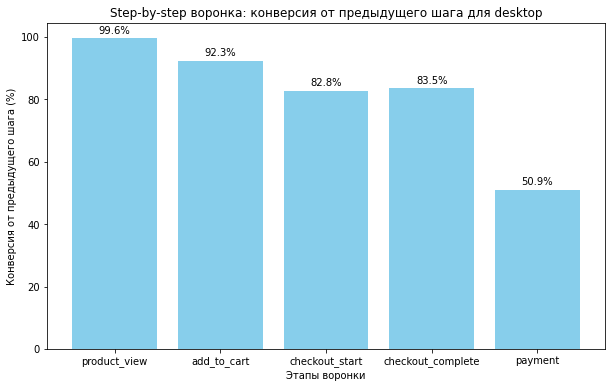

In [ ]:
# Визуализируем Step-by-step воронку для desktop
plt.figure(figsize=(10, 6))
# Строим barplot

bars = plt.bar(funnel_compare['step'][1:], funnel_compare['conversion_from_previous_desktop_%'][1:], color='skyblue')

# Добавляем подписи значений на каждый столбец
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,   
        height + 1,                          
        f'{height:.1f}%',                    
        ha='center', va='bottom', fontsize=10
    )

plt.title('Step-by-step воронка: конверсия от предыдущего шага для desktop')
plt.ylabel('Конверсия от предыдущего шага (%)')
plt.xlabel('Этапы воронки')
plt.show()

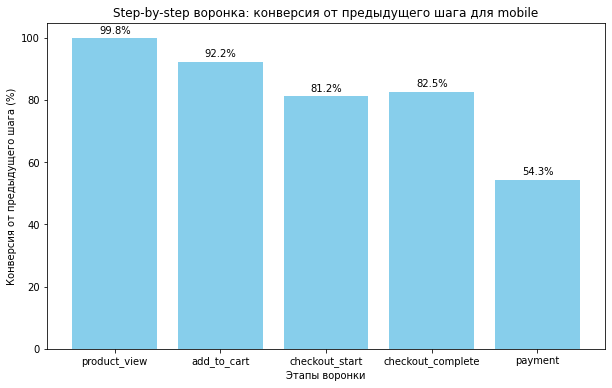

In [ ]:
# Визуализируем Step-by-step воронку для mobile
plt.figure(figsize=(10, 6))
# Строим barplot

bars = plt.bar(funnel_compare['step'][1:], funnel_compare['conversion_from_previous_mobile_%'][1:], color='skyblue')

# Добавляем подписи значений на каждый столбец
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,   
        height + 1,                          
        f'{height:.1f}%',                    
        ha='center', va='bottom', fontsize=10
    )

plt.title('Step-by-step воронка: конверсия от предыдущего шага для mobile')
plt.ylabel('Конверсия от предыдущего шага (%)')
plt.xlabel('Этапы воронки')
plt.show()

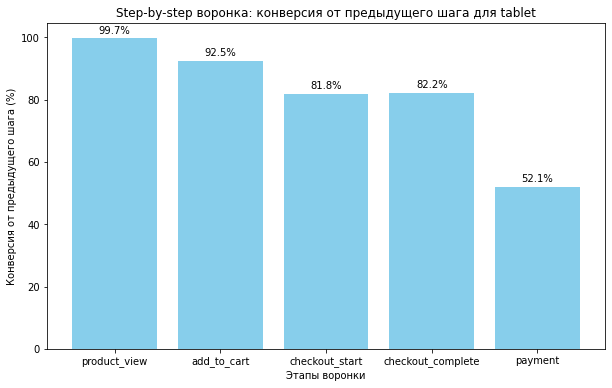

In [ ]:
# Визуализируем Step-by-step воронку для mobile
plt.figure(figsize=(10, 6))
# Строим barplot

bars = plt.bar(funnel_compare['step'][1:], funnel_compare['conversion_from_previous_tablet_%'][1:], color='skyblue')

# Добавляем подписи значений на каждый столбец
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,   
        height + 1,                          
        f'{height:.1f}%',                    
        ha='center', va='bottom', fontsize=10
    )

plt.title('Step-by-step воронка: конверсия от предыдущего шага для tablet')
plt.ylabel('Конверсия от предыдущего шага (%)')
plt.xlabel('Этапы воронки')
plt.show()

На всех типах устройств только половина пользователей оплачивают заказ после оформления.

Проверим конверсию по каналам

In [ ]:
# Объединяем все события с каналами
events_with_channels = events_reg_pay.merge(
    pa_diploma_users[['user_id', 'acq_channel']],
    on='user_id',
    how='left'
)

# Убираем пропущенные каналы, если такие есть
events_with_channels = events_with_channels.dropna(subset=['acq_channel'])

# Порядок шагов воронки
funnel_steps = ['registration', 'product_view', 'add_to_cart', 'checkout_start', 'checkout_complete', 'payment']

# Фильтруем нужные события
filtered = events_with_channels[events_with_channels['event_type'].isin(funnel_steps)]

# Группируем: сколько уникальных пользователей на каждом шаге по каждому каналу
funnel_by_channel = filtered.groupby(['acq_channel', 'event_type'])['user_id'].nunique().unstack(fill_value=0).reindex(columns=funnel_steps)

# Конверсия от первого шага (registration)
for step in funnel_steps:
    funnel_by_channel[f'{step}_conv_from_reg_%'] = (
        funnel_by_channel[step] / funnel_by_channel['registration'] * 100
    ).round(1)

# Конверсия от предыдущего шага
for i in range(1, len(funnel_steps)):
    curr, prev = funnel_steps[i], funnel_steps[i - 1]
    funnel_by_channel[f'{curr}_conv_from_prev_%'] = (
        funnel_by_channel[curr] / funnel_by_channel[prev] * 100
    ).round(1)

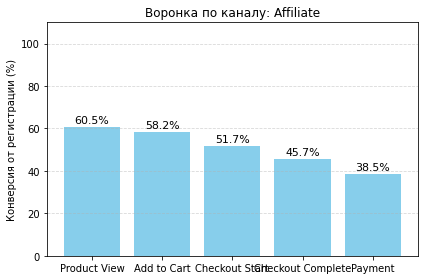

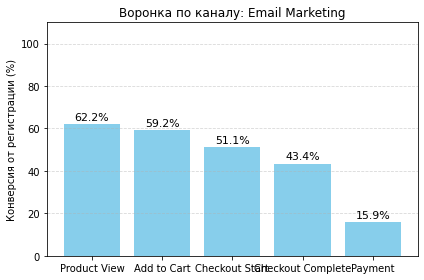

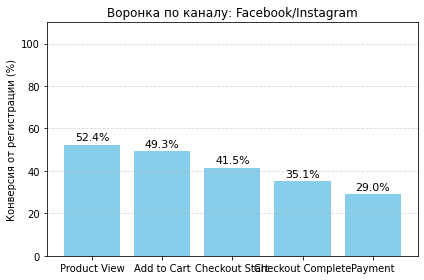

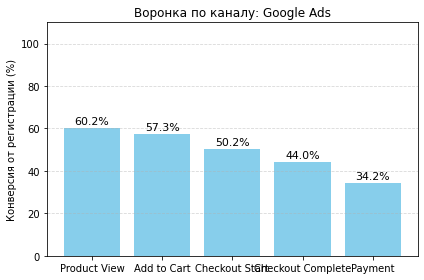

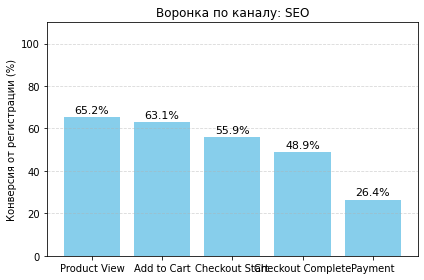

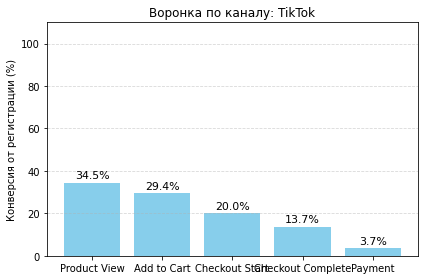

In [ ]:
# Шаги воронки
funnel_steps = [
    'product_view_conv_from_reg_%',
    'add_to_cart_conv_from_reg_%',
    'checkout_start_conv_from_reg_%',
    'checkout_complete_conv_from_reg_%',
    'payment_conv_from_reg_%'
]

# Подписи для оси X
step_labels = [
    'Product View',
    'Add to Cart',
    'Checkout Start',
    'Checkout Complete',
    'Payment'
]

# Размер шрифта
label_fontsize = 11

# строим графики для каналов
for channel in funnel_by_channel.index:
    values = funnel_by_channel.loc[channel, funnel_steps].values

    plt.figure(figsize=(6, 4))
    bars = plt.bar(step_labels, values, color='skyblue')

    # Подписи значений
    for bar, value in zip(bars, values):
        plt.text(bar.get_x() + bar.get_width() / 2, value + 1, f"{value:.1f}%", 
                 ha='center', va='bottom', fontsize=label_fontsize)

    plt.ylim(0, 110)
    plt.title(f'Воронка по каналу: {channel}', fontsize=12)
    plt.ylabel('Конверсия от регистрации (%)')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

- Affiliate, Google Ads — самые эффективные каналы: более 30% пользователей, пришедших через них, доходят до оплаты.
- Email Marketing и SEO — средние показатели.
- TikTok — крайне низкая конверсия (3,7%), скорее всего приходит нецелевая аудитория.

<div class="alert"
     style="background-color: #e7eedd; padding: 15px;
            border-radius: 5px; border: 1px solid #2d3e16;
            color: #2d3e16;">

<font color='#2d3e16'>**Комментарий ревьюера v.2**
    
<font color='#2d3e16'>Молодец, что смотришь воронку от регистрации - хорошо видно, что идет падение на первой активности + любимый маркетологами ТикТок показывает откровенно плохие результаты.
</div>

## Выводы по углубленному анализу

**Эффективность каналов привлечения**

Эффективныее каналы:

- Google Ads: максимальная выручка, число заказов, платящих пользователей и высокая конверсия. Однако — резкий спад с августа и отсутствие данных за ноябрь–декабрь. LTV стабильно выше CAC.

- Affiliate: высокая выручка, самая высокая конверсия и ROI, но с июня спад всех ключевых метрик.

Неэффективные каналы:

- TikTok: взрывной рост новых пользователей с июня, но самая низкая конверсия (3,7%) и LTV стабильно ниже CAC — аудитория нецелевой характер.

- Email Marketing: нестабильная конверсия и ARPPU, LTV редко выше CAC. Однако в декабре — подъем ARPPU.

**Воронки**

Основная потеря — на старте: половина пользователей не взаимодействует с товарами после регистрации. 

Возможные причины:
- плохой онбординг
- нет персональных рекомендаций
- случайная регистрация, регистрация чтобы просто посмотреть

Хорошая вовлеченность: 92,5% просмотревших товары, добавляют их в корзину.

- Значительная потеря при оплате (−38% после оформления заказа):
- возможно проблемы с пользовательским интерфейсом, оплатой, неожиданной итоговой стоимостью
- наличие фейковых/тестовых заказов, накруток

**Поведение по сегментам**
- Регулярные покупатели приносят основную выручку и количество заказов. И именно здесь — самая выраженная просадка с августа.
- Категории с дорогими товарами (мебель, техника, украшения) дают больше всего выручки — здесь тоже наблюдается спад с августа.
- TikTok-привлечённые пользователи почти не конвертируются в покупку. Возможно, приходит не та аудитория.
- Возрастной сегмент 36–50 лет - основные покупатели. Младшие группы менее активны, у старших убывающая активность.

**Гипотезы для развития продукта**

1. Если восстановить данные и работу канала Google Ads, то выручка и количество заказов могут вернуться к прежним уровням.

- Основание: хорошая выручка до августа, резкое снижение показателей с августа и отсутствие данных после октября.

2. Если предложить персональные рекомендации и онбординг сразу после регистрации, то доля пользователей, переходящих к просмотру товаров, вырастет.

- Основание: 50% не взаимодействуют с товарами - это слишком много для маркетплйса.

3. Если улучшить пользовательский интерфейс оформления и оплаты заказа, можно сократить потери пользователей на этапе оплаты заказа.

- Основание: 38% пользователей после оформления не оплачивают заказ.

4. Если отключить или изменить рекламу в TikTok, то окупаемость канала может вырасти.

- Основание: резкий рост новых пользователей и заказов без роста выручки, самая низкая конверсия, LTV значительно ниже CAC.


**Можно улучшить:**

1. Запустить акцию/кампанию на пользователей из когорт первого полугодия.

- Основание: пользователи из первых когорт активнее совершают покупки.

2. Если провести акцию/кампанию направленную на регулярных покупателей, можно удержать основную часть выручки.

- Основание: эта группа приносит больше всего дохода, но показывает самый сильный спад с августа.

## 5. Подготовка эксперимента и подведение его результатов

### Данные для A/B теста: 

```python
pa_diploma_events_AB = pd.read_csv('https://........./pa_diploma_events_AB.csv') 
pa_diploma_orders_AB = pd.read_csv('https://........./pa_diploma_orders_AB.csv') 
pa_diploma_sessions_AB = pd.read_csv('https://........./pa_diploma_sessions_AB.csv') 
pa_diploma_users_AB = pd.read_csv('https://........./pa_diploma_users_AB.csv')
```

### Результаты сплита лежат в таблице: 

```python 
pa_diploma_AB_split_users = pd.read_csv('https://........./pa_diploma_AB_split_users.csv')
```

* user_id – id клиента 
* group – группа, в которую попал клиент 

## Дизайн эксперимента: 

**Бонус на первую покупку для пользователей TikTok**

### 1. Контекст и цель эксперимента

- **Бизнес-контекст:** Команда продукта запускает эксперимент, направленный на повышение конверсии среди пользователей, привлечённых через канал TikTok. Для стимулирования первой покупки пользователям будет предоставлен бонус на первую покупку.  
- **Цель:** Проверить, влияет ли предоставление бонуса на первую покупку на конверсию и выручку среди пользователей TikTok.  
- **Гипотеза:** Предоставление бонуса на первую покупку новым пользователям, привлеченным через TikTok, приведет к увеличению конверсии в первую покупку

---

### 2. Формат эксперимента

- **Тип эксперимента:** Сплит-роллинг (rolling split)  
- **Канал:** Только пользователи, пришедшие с TikTok  
- **Группы:**  
  - **Контрольная (A):** пользователи TikTok без бонуса  
  - **Тестовая (B):** пользователи TikTok с бонусом на первую покупку  
- **Распределение:** Равномерное распределение новых пользователей TikTok между группами по дате регистрации  
- **Период проведения:** 3 недели (фиксировано)

---

### 3. Ключевые метрики

#### Основная метрика

- **Конверсия в первую покупку** — доля пользователей, зарегистрировавшихся с TikTok и совершивших первую покупку  
  - *Цель:* увеличить конверсию с помощью бонуса  
  - *Критерий успеха:* статистически значимый рост конверсии в тестовой группе

#### Вспомогательные метрики

- **ARPU** (средняя выручка на пользователя TikTok)  
- **ARPPU** (средняя выручка на покупателя TikTok)  
- **AOV** (средний чек TikTok)

#### Барьерная метрика

- **Общая выручка от пользователей TikTok**

---

### 4. Размеры групп и запуск

- **Целевая аудитория:** только пользователи TikTok  
- **Размеры групп:** определяются по фактическому трафику TikTok за период эксперимента  
- **Комментарий:** запуск без предварительного расчёта мощности и MDE из-за срочности задачи


**Формируем датафреймы из csv-файлов.**

In [ ]:
pa_diploma_events_AB = pd.read_csv('https://........../pa_diploma_events_AB.csv') 
pa_diploma_orders_AB = pd.read_csv('https://........../pa_diploma_orders_AB.csv') 
pa_diploma_sessions_AB = pd.read_csv('https://........../pa_diploma_sessions_AB.csv') 
pa_diploma_users_AB = pd.read_csv('https://........../pa_diploma_users_AB.csv')

pa_diploma_AB_split_users = pd.read_csv('https://........../pa_diploma_AB_split_users.csv')

**Выводим основную информацию и проверяем наличие пропусков и дубликатов в датафреймах**

In [ ]:
# Запишем базовую часть в переменную 
base_url = "https://.........."
# Создаем список названий файлов
filenames = ['pa_diploma_orders_AB.csv', 'pa_diploma_sessions_AB.csv', 'pa_diploma_users_AB.csv', 'pa_diploma_events_AB.csv', 'pa_diploma_AB_split_users.csv']
# Создаем список датафреймов
dfs = {file: pd.read_csv(base_url + file) for file in filenames}


def lookup_datasets(dfs, filenames=None):
    """
    Выводит информацию о датасетах из списка

    Parameters:
        dfs (list of pd.DataFrame): Список датафреймов для обработки.
        filenames (list of str): Список названий файлов (имена для отображения).
    """
    if filenames is None:
        filenames = [f"df_{i + 1}" for i in range(len(dfs))]

    for df, df_name in zip(dfs, filenames):
        print('-'*10,' '*5, df_name, ' '*5, '-'*10)

        # Пропущенные значения
        missing_data = df.isna().mean()
        missing_data_result = missing_data.apply(lambda x: f'{x:.2%}' if x > 0 else "")
        missing_data_name = "Пропущено" if missing_data.sum() > 0 else ""
        missing_data_result.name = missing_data_name

        # Типы данных
        dtypes_result = df.dtypes
        dtypes_result.name = "Тип данных колонки"
        fewest_nans_row = df.iloc[1:-1].isna().sum(axis=1).idxmin()

        values_type = df.loc[fewest_nans_row].map(type).T
        values_type.name = "Тип значения"

        # Объединяем результаты и пример данных
        result = pd.concat([
            dtypes_result, # типы
            values_type, # типы значений
            missing_data_result, # пропущенные значения
            df.iloc[0, :], # первая строка
            df.loc[fewest_nans_row].T, # полная строка
            df.iloc[-1, :] # последняя строка
        ], axis=1)

        display(result)

        # Проверка на полные дубликаты
        duplicates = df.duplicated().mean()
        if duplicates > 0:
            print(f'Полных дубликатов: {duplicates:.2%}')

        print()

# Проводим автоматический осмотр данных
column_counts = lookup_datasets(dfs.values(), dfs.keys())

----------       pa_diploma_orders_AB.csv       ----------


,Тип данных колонки,Тип значения,,0,1,33279
order_id,int64,<class 'numpy.int64'>,,1,2,22889
user_id,int64,<class 'numpy.int64'>,,3,3,20796
order_date,object,<class 'str'>,,2024-01-19 01:52:52.000,2024-01-19 01:52:52.000,2025-01-26 23:07:50
product_name,object,<class 'str'>,,Шуруповерт,Молоток слесарный,Витамины комплекс
quantity,int64,<class 'numpy.int64'>,,2,1,2
unit_price,float64,<class 'numpy.float64'>,,5539.13,11340.38,2345.46
total_price,float64,<class 'numpy.float64'>,,11078.26,11340.38,4690.92
category_name,object,<class 'str'>,,Инструменты и садовый инвентарь,Инструменты и садовый инвентарь,Медицинские товары
order_week,object,<class 'str'>,,2024-01-15,2024-01-15,2025-01-20
order_month,object,<class 'str'>,,2024-01-01,2024-01-01,2025-01-01



----------       pa_diploma_sessions_AB.csv       ----------


,Тип данных колонки,Тип значения,Пропущено,0,1,127406
session_id,int64,<class 'numpy.int64'>,,705,706,98151
user_id,int64,<class 'numpy.int64'>,,160,160,26244
session_start,object,<class 'str'>,,2024-01-12 02:30:37.000,2024-01-10 06:04:41.000,2025-01-26 23:58:24
os,object,<class 'str'>,,Windows,Windows,macOS
device,object,<class 'str'>,,mobile,mobile,mobile
region,object,<class 'str'>,,Москва,Москва,Москва
browser,object,<class 'str'>,,Safari,Safari,Firefox
country,object,<class 'str'>,,Россия,Россия,Россия
entry_path,object,<class 'str'>,,/home,/home,/product
path_start,object,<class 'str'>,,/recommend/10,/sale/2,/recommend/4



----------       pa_diploma_users_AB.csv       ----------


,Тип данных колонки,Тип значения,,0,1,22195
user_id,int64,<class 'numpy.int64'>,,18,22,48907
registration_date,object,<class 'str'>,,2024-01-01 05:26:00,2024-01-01 17:13:00,2025-01-26 04:58:00
os,object,<class 'str'>,,Android,iOS,macOS
age,int64,<class 'numpy.int64'>,,49,50,69
device,object,<class 'str'>,,mobile,tablet,tablet
gender,object,<class 'str'>,,M,M,F
region,object,<class 'str'>,,Екатеринбург,Санкт-Петербург,Московская область
browser,object,<class 'str'>,,Edge,Chrome,Safari
country,object,<class 'str'>,,Россия,Россия,Россия
acq_channel,object,<class 'str'>,,TikTok,TikTok,TikTok



----------       pa_diploma_events_AB.csv       ----------


,Тип данных колонки,Тип значения,Пропущено,0,1,831230
event_id,int64,<class 'numpy.int64'>,,3132,3133,623181
session_id,int64,<class 'numpy.int64'>,,479,479,98151
user_id,int64,<class 'numpy.int64'>,,100,100,26244
event_date,object,<class 'str'>,,2024-01-01 15:23:56,2024-01-01 15:24:01,2025-01-26 23:59:34
event_type,object,<class 'str'>,,page_view,product_view,product_view
os,object,<class 'str'>,,iOS,iOS,macOS
device,object,<class 'str'>,,mobile,mobile,mobile
event_index,int64,<class 'numpy.int64'>,,1,2,2
user_segment,object,<class 'str'>,,regular,regular,regular
product_name,object,<class 'str'>,50.79%,NaN,Шорты для тренировок,Стиральная машина



----------       pa_diploma_AB_split_users.csv       ----------


,Тип данных колонки,Тип значения,,0,1,2967
user_id,int64,<class 'numpy.int64'>,,44965,44967,48907
group,object,<class 'str'>,,control,control,treatment


В датафрейме `pa_diploma_orders_AB` содержится информация о заказах

- order_id - идентификатор заказа
- user_id - идентификатор пользователя, который сделал заказ (внешний ключ на Users)
- order_date - дата и время оформления заказа. 
- product_name - наимнование продукта
- quantity - количество единиц в заказе
- unit_price - цена за одну единицу товара на момент заказа
- total_price - общая стоимость позиции в заказе (quantity × unit_price)
- category_name - наименование категории товара
- order_week - неделя заказа
- order_month - месяц заказа

Всего 33279 строк, 10 столбцов.  Столбцы с датами имеют тип ‘str’, тип данных лучше привести к дате для удобства анализа. Идентификаторы и количество единиц в звказк имеют тип ‘int’, тип данных  корректен. Цены и выручка имеют тип ‘float’, тип данных  корректен. Пропусков нет. Дубликатов нет

В датафрейме  `pa_diploma_sessions_АВ` содержится информация о сессиях

- session_id - идентификатор сессии
- user_id - идентификатор пользователя
- session_start - дата и время начала сессии
- os	- операционная система (например, macOS)
- device	- тип устройства, на котором началась сессия (например, desktop)
- region	-	регион или город (например, Москва)
- browser	-	браузер пользователя (например, Firefox)
- country	-	страна пользователя (например, Россия)
- entry_path - страница входа в сессию (например, /product, /promo, /checkout)
- path_start	- первая страница или путь кампании, из которой пришёл пользователь (например, /campaign/5, /sale/13, /campaign/18)
- utm_source	- источник трафика из UTM-меток (например, direct)
- screen_size	- разрешение экрана пользователя (например, 1920×1080, 1366×768) screen_size
- scroll_depth - глубина прокрутки страницы в процентах (например, 96, 80, 30)
- user_segment - сегмент пользователя (например, regular)
- utm_campaign_id	- идентификатор кампании из UTM (например, 39)
- session_week	- неделя сессии
- session_month	- месяц сессии

Всего 127406 строк, 17 столбцов. Типы данных корректны, кроме столбцов с датами. Пропусков 0,26% в столбце utm_campaign_id. Дубликатов нет.

В датафрейме  `pa_diploma_users_АВ` содержится информация о пользователях

- user_id - идентификатор пользователя
- registration_date - дата регистрации пользователя
- os	- операционная система (Windows, macOS, iOS, Android)
- age	- возраст
- device	- тип устройства (desktop, mobile, tablet)
- gender	- пол (M, F)
- region	- регион
- browser	- браузер (Chrome, Firefox, Safari, Edge)
- country	- страна
- acq_channel	- канал привлечения
- campaign_id - идентификатор рекламной кампании (если применимо, иначе null)
- user_segment - пользовательский сегмент (новичок, активный, VIP, спящий)
- buyer_segment	- сегмент покупателя
- cohort_week	- неделя регистрации пользователя
- cohort_month -	месяц регистрации пользователя

Всего 22196 строк, 15 столбцов. Типы данных корректны, кроме столбцов с датами. Пропусков и дубликатов нет. 

В датафрейме  `pa_diploma_events_АВ` содержится информация о событиях

- event_id	- уникальный идентификатор события
- session_id	- идентификатор сессии пользователя, во время которой произошло событие
- user_id	- уникальный идентификатор пользователя
- event_date	- время и дата события
- event_type	- тип события (например, вход пользователя, просмотр страницы, просмотр товара, добавление в корзину)
- os	- операционная система (macOS, Windows, iOS, Android и другие)
- device	- тип устройства, на котором произошло событие
- event_index	-  порядковый номер события в текущей сессии
- user_segment	- сегмент пользователя (например, новичок, активный, VIP и т. п.), для которого может строиться персонализация или сегментация поведения
- product_name	- наименование продукта
- event_week	- неделя события
- event_month - месяц события

Описание событий (столбец event_type)

- page_view	- открытие любой страницы сайта или приложения пользователем.
- product_view - просмотр страницы конкретного товара.
- product_click	- клик по товару (например, из списка товаров или на баннере).
- add_to_cart	- добавление товара в корзину.
- remove_from_cart	- удаление товара из корзины.
- search - выполнение поиска по сайту или приложению.
- filter_apply	- применение фильтра (например, по цене, бренду, категории).
- checkout_start	- начало оформления заказа (переход к оформлению корзины).
- checkout_complete	- завершение оформления заказа (не гарантирует покупку, покупка зависит от факта оплаты).
- user_login	- вход пользователя в личный кабинет или аккаунт.
- user_logout	- выход пользователя из аккаунта.
- wishlist_add	- добавление товара в список желаемого (wishlist).
- category_view	- просмотр страницы категории товаров.
- banner_click	- клик по рекламному баннеру на сайте или в приложении.
- promo_view	- просмотр промо-акции или специального предложения.


Всего 831230 строк, 12 столбцов. . Типы данных корректны, кроме столбцов с датами. Пропуски в столбце `product_name` - 50.79%. Дубликатов нет.

В датафрейме `pa_diploma_AB_split_users` содержится информация о распределении пользователей по группам эксперимента

- user_id	- уникальный идентификатор пользователя
- group - группа эксперимента

Всего 2967 строк, 2 столбца

Проверим диапазоны дат в таблицах

In [ ]:
# Выведем период анализа данных заказов
print(pa_diploma_orders_AB['order_date'].min())
print(pa_diploma_orders_AB['order_date'].max())

2024-01-01 08:03:45.000
2025-01-26 23:07:50


In [ ]:
# Выведем период анализа данных по сессиям
print(pa_diploma_sessions_AB['session_start'].min())
print(pa_diploma_sessions_AB['session_start'].max())

2024-01-01 08:34:27.000
2025-01-26 23:58:24


In [ ]:
# Выведем период анализа данных пользователей
print(pa_diploma_users_AB['registration_date'].min())
print(pa_diploma_users_AB['registration_date'].max())

2024-01-01 01:13:00
2025-01-26 23:41:00


In [ ]:
# Выведем период анализа событий
print(pa_diploma_events_AB['event_date'].min())
print(pa_diploma_events_AB['event_date'].max())

2024-01-01 15:23:56
2025-01-26 23:59:34


Диапазон дат на 5 дней больше 3 недель, зафиксированных в эксперименте

**Преобразуем формат дат**

In [ ]:
# Преобразуем время событий в формат date для анализа данных 
pa_diploma_orders_AB['order_date'] = pd.to_datetime(pa_diploma_orders_AB['order_date'])
pa_diploma_orders_AB['order_week'] = pd.to_datetime(pa_diploma_orders_AB['order_week'])
pa_diploma_orders_AB['order_month'] = pd.to_datetime(pa_diploma_orders_AB['order_month'])

pa_diploma_sessions_AB['session_start'] = pd.to_datetime(pa_diploma_sessions_AB['session_start'])
pa_diploma_sessions_AB['session_week'] = pd.to_datetime(pa_diploma_sessions_AB['session_week'])
pa_diploma_sessions_AB['session_month'] = pd.to_datetime(pa_diploma_sessions_AB['session_month'])

pa_diploma_users_AB['registration_date'] = pd.to_datetime(pa_diploma_users_AB['registration_date'])
pa_diploma_users_AB['cohort_week'] = pd.to_datetime(pa_diploma_users_AB['cohort_week'])
pa_diploma_users_AB['cohort_month'] = pd.to_datetime(pa_diploma_users_AB['cohort_month'])

pa_diploma_events_AB['event_date'] = pd.to_datetime(pa_diploma_events_AB['event_date'])
pa_diploma_events_AB['event_week'] = pd.to_datetime(pa_diploma_events_AB['event_week'])
pa_diploma_events_AB['event_month'] = pd.to_datetime(pa_diploma_events_AB['event_month'])

In [ ]:
# Проверим на неявные дубликаты таблицу с сессиями
pa_diploma_sessions_AB.duplicated(subset=['user_id', 'session_id', 'session_start']).sum()

0

In [ ]:
# Проверим на неявные дубликаты таблицу с покупками
pa_diploma_orders_AB.duplicated(subset=['user_id', 'order_id']).sum()

0

In [ ]:
# Проверим на неявные дубликаты таблицу с событиями
pa_diploma_events_AB.duplicated(subset=['user_id', 'event_id', 'session_id']).sum()

0

Период анализа данных с 2024-01-01 по 2025-01-26. Чуть больше, чем 3 недели, выделенные на эксперимент.

В ходе предобработки данных изменены типы данных в столбцах с датами. Данные проверены на пропуски, дубликаты и выбросы.

Данные хорошего качества и подготовлены к работе.

**Проверим эксперементальные группы**

In [ ]:
# Проверим, есть ли пользователи попавшие в обе группы
group_treatment = pa_diploma_AB_split_users[pa_diploma_AB_split_users['group'] == 'treatment']['user_id']
group_control = pa_diploma_AB_split_users[pa_diploma_AB_split_users['group'] == 'control']['user_id']

# Выведем список совпадающих пользователей
intersection = list(set(group_treatment) & set(group_control))
print(intersection) 

[]


Спсок пуст. Пользователей, попавших в обе группы нет. Данные распределены корректно.

In [ ]:
# Рассчитаем количество уникальных пользователей в каждой из экспериментальных групп
group_treatment = pa_diploma_AB_split_users.groupby(pa_diploma_AB_split_users['group'] == 'treatment')['user_id'].nunique()
group_control = pa_diploma_AB_split_users.groupby(pa_diploma_AB_split_users['group'] == 'control')['user_id'].nunique()
display(group_treatment, group_control)

group
False    1503
True     1465
Name: user_id, dtype: int64

group
False    1465
True     1503
Name: user_id, dtype: int64

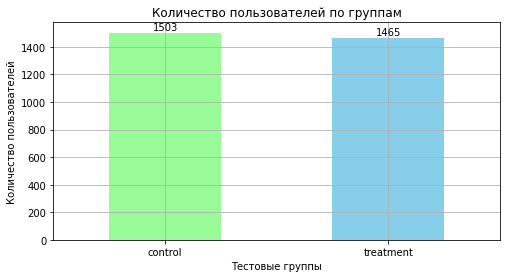

In [ ]:
# Построим столбчатую диаграмму по количеству пользователей в тестовых группах
plt.figure(figsize=(8,8))
bars = pa_diploma_AB_split_users.groupby('group')['user_id'].nunique().plot(kind='bar',
               title=f'Количество пользователей по группам',
               ylabel='Количество пользователей',
               xlabel='Тестовые группы',
               rot=0,
               color=['palegreen', 'skyblue'],                                         
               figsize=(8, 4))
plt.grid()

# Добавим подписи над столбцами
for bar in bars.containers[0]:
    height = bar.get_height()
    bars.annotate(f'{height:.0f}', 
                  xy=(bar.get_x() + bar.get_width() / 2, height),
                  xytext=(0, 1), 
                  textcoords="offset points",
                  ha='center', va='bottom')
plt.show()

In [ ]:
# Посчитаем процентную разницу между группами control и treatment
difference = 100 * (group_control - group_treatment) / group_control
display(difference)

group
False   -2.593857
True     2.528277
Name: user_id, dtype: float64

Разница между группами 2,5%. Можем считать тестовые группы равнозначными

In [ ]:
# Проверим, что в данных только пользователи Tik Tok
display(pa_diploma_users_AB['acq_channel'].unique())

array(['TikTok'], dtype=object)

Среди пользователей только пользователи Tik Tok

In [ ]:
# Фильтруем пользователей и заказы по датам эксперимента
users_AB = pa_diploma_users_AB[pa_diploma_users_AB['registration_date'] > '2024-12-31']
orders_AB = pa_diploma_orders_AB[pa_diploma_orders_AB['order_date'] > '2024-12-31']

# Присоединим группы к пользователям
users_AB = users_AB.merge(pa_diploma_AB_split_users, on='user_id')

# Соединим заказы и пользователей
orders_users_AB = orders_AB.merge(users_AB, on='user_id', how='left')

# Фильтруем заказы только в Tik Tok
orders_users_AB = orders_users_AB[orders_users_AB['acq_channel'] ==  'TikTok']

**Посмотрим на количество пользователей по дням**

In [ ]:
# Соединим событияи и группы
events_AB = pa_diploma_events_AB.merge(pa_diploma_AB_split_users, on='user_id', how='left')

# Выберем только события в датах эксперимента
events_AB = events_AB[events_AB['event_date'] > '2024-12-31']

# Преобразуем время событий в формат date для анализа данных 
events_AB['event_day'] = events_AB['event_date'].dt.date

# Посчитаем DAU (по дням)
DAU_AB = events_AB.groupby('event_day')['user_id'].nunique().reset_index(name='DAU')

# Посчитаем DAU по группам
DAU_AB_group = events_AB.groupby(['event_day', 'group'])['user_id'].nunique().reset_index(name='DAU_AB_group')

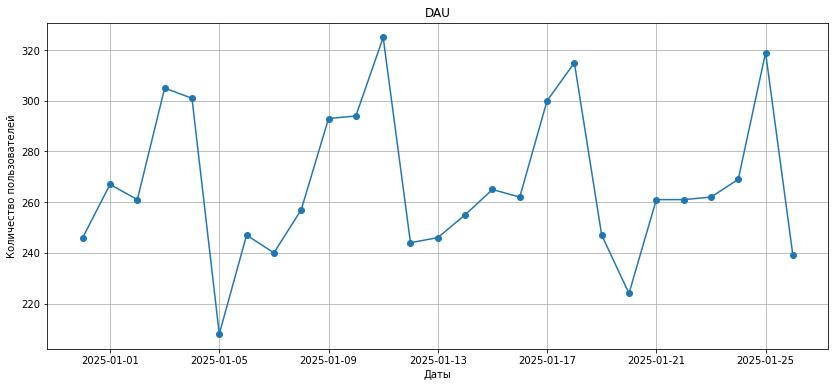

In [ ]:
# Строим график DAU
plt.figure(figsize=(14,6))
plt.plot(DAU_AB['event_day'], DAU_AB['DAU'], marker='o')
plt.title('DAU')
plt.grid(True)
plt.xlabel('Даты')
plt.ylabel('Количество пользователей');

В дневном количестве пользователей видна недельная цикличность данных - в субботу резкий скачок до максимального числа пользователей, в воскресенье спад до минимального количества и плавный подьем до пятницы. Поэтому в таком случае тест лучше проводить кратное неделе количество дней, поскольу в разные дни недели может быть разное количество пользователей и их поведение может различаться.

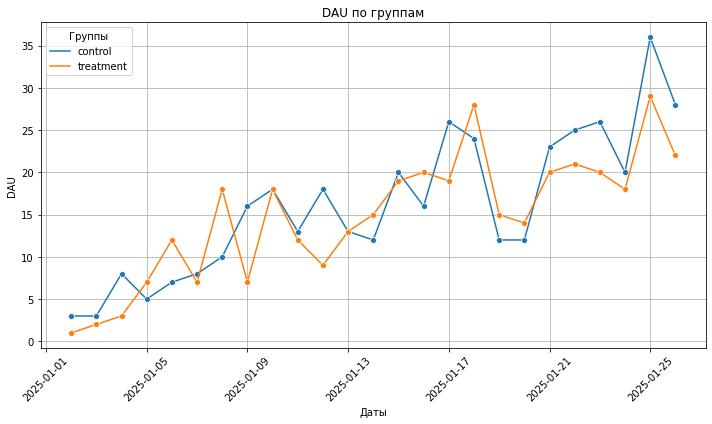

In [ ]:
# Строим графики DAU по группам
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=DAU_AB_group,
    x='event_day',
    y='DAU_AB_group',
    hue='group',
    marker='o'
)

plt.title('DAU по группам')
plt.xlabel('Даты')
plt.ylabel('DAU')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend(title='Группы')
plt.tight_layout()
plt.show()

- В контрольной группе в первые дни эксперимента плавное увеличение числа пользователей. С 13.01 видна цикличность, как в исторических данных.
- В тестовой группе в первые дни эксперимента неравномерное увеличение числа пользователей. С 13.01 видна цикличность, как в исторических данных.

Начало эксперемента совпало с новогодними праздничными днями. Поведение пользователей в эти дни нетипично. По окончании праздников поверение пользователей возвращается к типичному по историческим данным.

**Посмотрим как распределились пользователи тестовых групп по воронкам**

In [ ]:
# Объединяем события с регистрацией и оплатой
registration_events_AB = users_AB[['user_id', 'registration_date', 'group']].copy()
registration_events_AB['event_type'] = 'registration'
registration_events_AB.rename(columns={'registration_date': 'event_date'}, inplace=True)

payment_events_AB = orders_users_AB[['user_id', 'order_date', 'group']].copy()
payment_events_AB['event_type'] = 'payment'
payment_events_AB.rename(columns={'order_date': 'event_date'}, inplace=True)

In [ ]:
# Приведение к общему формату
event_columns_AB = ['user_id', 'event_date', 'event_type', 'group']
registration_events_AB = registration_events_AB[event_columns_AB]
payment_events_AB = payment_events_AB[event_columns_AB]
events_base_AB = pa_diploma_events_AB.merge(users_AB[['user_id', 'group']], on='user_id', how='left')

In [ ]:
events_reg_pay_AB = pd.concat([events_base_AB[event_columns_AB], registration_events_AB, payment_events_AB], ignore_index=True)

# Этапы воронки
funnel_steps_AB = ['registration', 'product_view', 'add_to_cart', 'checkout_start', 'checkout_complete', 'payment']

# Фильтруем события для нужных шагов
funnel_df_steps_AB = events_reg_pay_AB[events_reg_pay_AB['event_type'].isin(funnel_steps_AB)]

# Функция подсчёта воронки по группе
def build_funnel(df, group_name):
    group_df = df[df['group'] == group_name]
    funnel_counts = group_df.groupby('event_type')['user_id'].nunique().reindex(funnel_steps_AB)
    funnel_data = pd.DataFrame({
        'step': funnel_steps_AB,
        'users': funnel_counts.values
    })
    funnel_data['conversion_from_first_%'] = (funnel_data['users'] / funnel_data['users'].iloc[0] * 100).round(1)
    funnel_data['conversion_from_previous_%'] = (funnel_data['users'] / funnel_data['users'].shift(1) * 100).round(1)
    return funnel_data

# Строим воронки для групп A/B
funnel_control_AB = build_funnel(funnel_df_steps_AB, 'control')
funnel_treatment_AB = build_funnel(funnel_df_steps_AB, 'treatment')


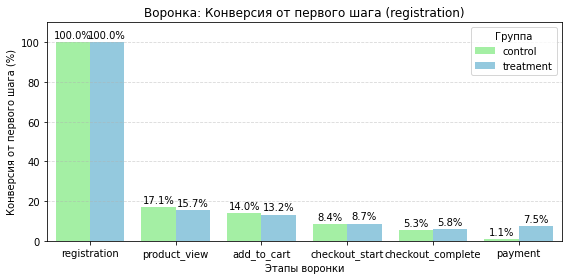

In [ ]:
# Объединяем данные контрольной и тестовой групп в один DataFrame
funnel_control_AB['group'] = 'control'
funnel_treatment_AB['group'] = 'treatment'
funnel_all = pd.concat([funnel_control_AB, funnel_treatment_AB], ignore_index=True)

plt.figure(figsize=(8, 4))

# Строим barplot
ax = sns.barplot(data=funnel_all, x='step', y='conversion_from_first_%', hue='group', palette=['palegreen','skyblue'])

# Добавляем подписи значений над столбцами
for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2,
        height + 1,
        f'{height:.1f}%',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title('Воронка: Конверсия от первого шага (registration)')
plt.ylabel('Конверсия от первого шага (%)')
plt.xlabel('Этапы воронки')
plt.ylim(0, 110)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='Группа')
plt.tight_layout()
plt.show()

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


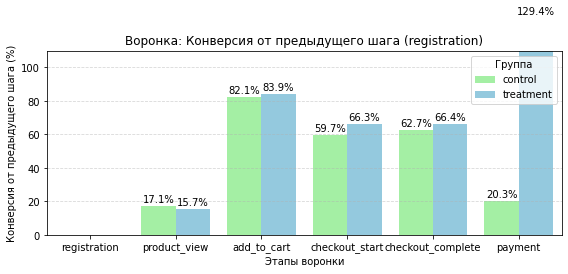

In [ ]:
plt.figure(figsize=(8, 4))

# Строим barplot
ax = sns.barplot(data=funnel_all, x='step', y='conversion_from_previous_%', hue='group', palette=['palegreen','skyblue'])

# Добавляем подписи значений над столбцами
for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2,
        height + 1,
        f'{height:.1f}%',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title('Воронка: Конверсия от предыдущего шага (registration)')
plt.ylabel('Конверсия от предыдущего шага (%)')
plt.xlabel('Этапы воронки')
plt.ylim(0, 110)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='Группа')
plt.tight_layout()
plt.show()

Похоже, что введение бонуса положительно повлияло на конверсию в покупку. Проверим ключевую, вспомогательные и барьерную метрику.

**Ключевая метрика**

**Конверсия в покупку по группам по когортам регистрации**

In [ ]:
# Кол-во пользователей в каждой группе
users_per_group = users_AB.groupby('group')['user_id'].nunique()

# Кол-во покупателей в каждой группе 
buyers_per_group = orders_users_AB[['user_id', 'group']].drop_duplicates().groupby('group')['user_id'].nunique()

# Конверсия
conversion_per_group = buyers_per_group / users_per_group
print(conversion_per_group)

group
control      0.010645
treatment    0.075085
Name: user_id, dtype: float64


Конверся в тестовой группе в 7 раз выше, чем в контрольной. Проверим насколько статистически значимы эти различия. Проведем z-тест пропорций.

Для оценки влияния бонуса на конверсию в покупку, проведем z-тест пропорций.

Мы проверям одностороннюю альтернативную гипотезу:

- H0 (нулевая гипотеза): конверсия в покупку в тестовой группе не больше, чем в контрольной группе.
- H1 (альтернативная гипотеза): конверсия в покупку в тестовой группе больше, чем в контрольной группе.

**Z-тест пропорций (односторонний)**

In [ ]:
count = buyers_per_group#.reindex(group_order).values
nobs = users_per_group#.reindex(group_order).values

# Z-тест

z_stat, p_value = proportions_ztest(count, nobs, alternative='larger')

print(f"Z-статистика: {z_stat:.4f}")
print(f"p-value: {p_value:.4f}")

if p_value < 0.05:
    print("Различие статистически значимо — введение бонуса работает.")
else:
    print("Нет статистически значимого улучшения.")

Z-статистика: -8.7054
p-value: 1.0000
Нет статистически значимого улучшения.


Введение бонуса действительно дало статистически значимый рост конверсии в тестовой группе.

Выведем количество покупателей по группам, чтобы оценить размер выборок для дальнейшего анализа

In [ ]:
# Кол-во покупателей по группам
print(f"Количество покупателей в контрольной группе – {buyers_per_group['control']}")
print(f"Количество покупателей в тестовой группе – {buyers_per_group['treatment']}")

Количество покупателей в контрольной группе – 16
Количество покупателей в тестовой группе – 110


**Количество значений в контрольной группе невелико, всего 16. В такой ситуации можно использовать бутстрап как альтернативу классическим тестам.**

**Проверим вспомогательную метрику - ARPU** (средняя выручка на пользователя TikTok)

**ARPU**

In [ ]:
# Добавим выручку к заказам
orders_users_AB['revenue'] = orders_users_AB['total_price'] * 0.05

In [ ]:
# Считаем выручку на пользователя
revenue_per_user = orders_users_AB.groupby(['group', 'user_id'])['revenue'].sum().reset_index()
revenue_per_user.columns = ['group', 'user_id', 'user_revenue']

# Добавляем в таблицу всех пользователей, включая тех, кто не сделал покупок
user_revenue_all = users_AB.merge(revenue_per_user, on=['group', 'user_id'], how='left')
user_revenue_all['user_revenue'] = user_revenue_all['user_revenue'].fillna(0)

# Считаем ARPU по группам
ARPU = user_revenue_all.groupby('group')['user_revenue'].mean()
print("ARPU по группам:\n", ARPU)

ARPU по группам:
 group
control       12.587255
treatment    131.249045
Name: user_revenue, dtype: float64


In [ ]:
# Подготовка выборок для теста Манна–Уитни
arpu_control = user_revenue_all[user_revenue_all['group'] == 'control']['user_revenue']
arpu_treatment = user_revenue_all[user_revenue_all['group'] == 'treatment']['user_revenue']


Проверим распределение по группам перед проведением теста.

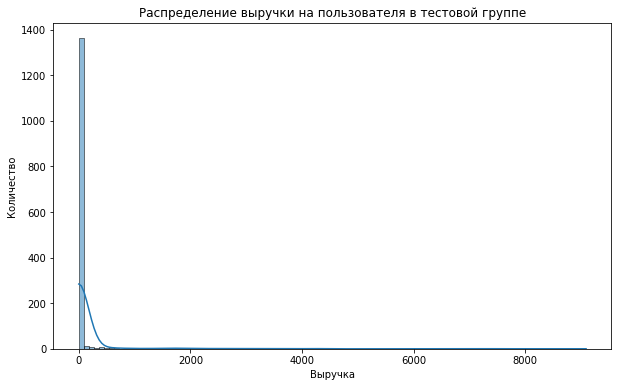

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(arpu_treatment, bins=100, alpha=0.5, edgecolor='black', kde=True)
plt.title('Распределение выручки на пользователя в тестовой группе')
plt.xlabel('Выручка')
plt.ylabel('Количество');

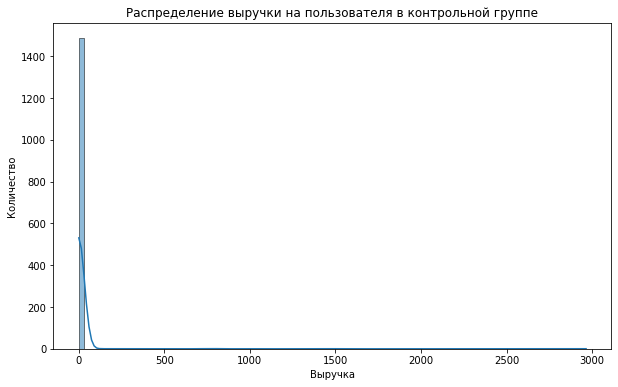

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(arpu_control, bins=100, alpha=0.5, edgecolor='black', kde=True)
plt.title('Распределение выручки на пользователя в контрольной группе')
plt.xlabel('Выручка')
plt.ylabel('Количество');

Данные распределены не нормально, сильно скошены. Для проверки статистической значимости отличий в средней выручке на пользователя ARPU используем тест Манна-Уитни.

Проверим одностороннюю гипотезу:

- H0: ARPU в тестовой группе не больше, чем в контрольной (бонус не влияет на метрику)
- H1: ARPU в тестовой группе больше, чем в контрольной (бонус повышает метрику)

In [ ]:
# Проверка односторонней гипотезы (тестовая > контрольной)
alpha = 0.05
mw_test = mannwhitneyu(
    arpu_control,
    arpu_treatment,
    alternative='less'  # контроль < тест
)

if mw_test.pvalue > alpha:
    print(f'pvalue={mw_test.pvalue:.4e} > {alpha}')
    print('Нет статистически значимого увеличения ARPU — гипотеза не подтвердилась.')
else:
    print(f'pvalue={mw_test.pvalue:.4e} < {alpha}')
    print('ARPU в тестовой группе статистически значимо выше — бонус сработал.')

pvalue=1.7663e-18 < 0.05
ARPU в тестовой группе статистически значимо выше — бонус сработал.


Проверим с помощью бутстрап

Среднее ARPU контроль: 12.59
Среднее ARPU тест: 131.25
Разница средних: 118.61
95% ДИ: [81.78, 159.68]
p-value: 0.0000


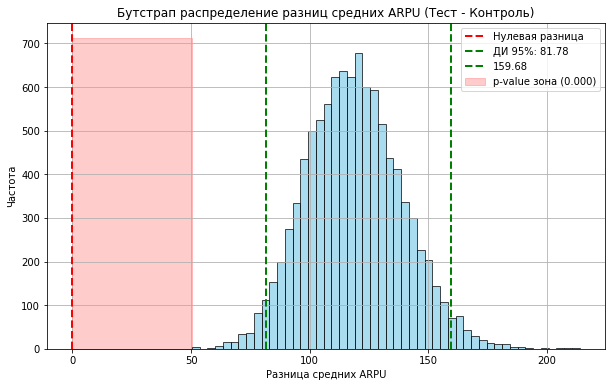

In [ ]:
# Функция бутстрапа
def bootstrap_mean_diff(data1, data2, n_bootstrap=10000, seed=42):
    np.random.seed(seed)
    diffs = []
    for _ in range(n_bootstrap):
        sample1 = np.random.choice(data1, size=len(data1), replace=True)
        sample2 = np.random.choice(data2, size=len(data2), replace=True)
        diffs.append(sample2.mean() - sample1.mean())  # тест - контроль
    return np.array(diffs)

# Получаем массивы ARPU для групп
arpu_control = user_revenue_all[user_revenue_all['group'] == 'control']['user_revenue'].values
arpu_treatment = user_revenue_all[user_revenue_all['group'] == 'treatment']['user_revenue'].values

# Запускаем бутстрап
bootstrap_diffs = bootstrap_mean_diff(arpu_control, arpu_treatment)

# Доверительный интервал 95%
ci_lower, ci_upper = np.percentile(bootstrap_diffs, [2.5, 97.5])

# p-value (односторонняя гипотеза: тест > контроль)
p_value = (bootstrap_diffs <= 0).mean()

print(f"Среднее ARPU контроль: {arpu_control.mean():.2f}")
print(f"Среднее ARPU тест: {arpu_treatment.mean():.2f}")
print(f"Разница средних: {bootstrap_diffs.mean():.2f}")
print(f"95% ДИ: [{ci_lower:.2f}, {ci_upper:.2f}]")
print(f"p-value: {p_value:.4f}")

# ======== ВИЗУАЛИЗАЦИЯ ========
plt.figure(figsize=(10, 6))
plt.hist(bootstrap_diffs, bins=50, color='skyblue', edgecolor='black', alpha=0.7)

# Линия для нуля
plt.axvline(0, color='red', linestyle='--', linewidth=2, label='Нулевая разница')

# Доверительный интервал
plt.axvline(ci_lower, color='green', linestyle='--', linewidth=2, label=f'ДИ 95%: {ci_lower:.2f}')
plt.axvline(ci_upper, color='green', linestyle='--', linewidth=2, label=f'{ci_upper:.2f}')

# Подсветка области p-value (где diff <= 0)
plt.fill_betweenx(
    y=[0, plt.gca().get_ylim()[1]],
    x1=min(bootstrap_diffs),
    x2=0,
    color='red',
    alpha=0.2,
    label=f'p-value зона ({p_value:.3f})'
)

plt.title('Бутстрап распределение разниц средних ARPU (Тест - Контроль)')
plt.xlabel('Разница средних ARPU')
plt.ylabel('Частота')
plt.legend()
plt.grid(True)
plt.show()

Весь диапазон доверительных интервалов лежит выше нуля, p-value < 0,05. Разница в ARPU между контрольной и тестовой группой статистически значима - бонус сработал.

**Проверим вспомогательную метрику - ARPPU** (средняя выручка на покупателя TikTok)

**ARPPU**

In [ ]:
# Выручка на покупателя 
revenue_per_user = orders_users_AB.groupby(['group', 'user_id'])['revenue'].sum().reset_index(name='bayer_revenue')

# ARPPU по группам — средняя выручка на покупателя
arppu_by_group = revenue_per_user.groupby('group')['bayer_revenue'].mean()
print("ARPPU по группам:\n", arppu_by_group)

# Подготовим выборки для статистического теста
arppu_control = revenue_per_user[revenue_per_user['group'] == 'control']['bayer_revenue']
arppu_treatment = revenue_per_user[revenue_per_user['group'] == 'treatment']['bayer_revenue']


ARPPU по группам:
 group
control      1182.415312
treatment    1747.998650
Name: bayer_revenue, dtype: float64


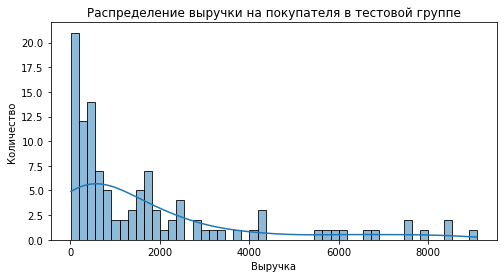

In [ ]:
plt.figure(figsize=(8, 4))
sns.histplot(arppu_treatment, bins=50, alpha=0.5, edgecolor='black', kde=True)
plt.title('Распределение выручки на покупателя в тестовой группе')
plt.xlabel('Выручка')
plt.ylabel('Количество');

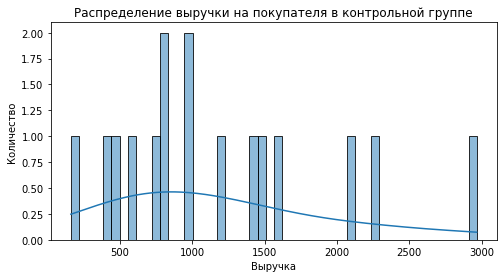

In [ ]:
plt.figure(figsize=(8, 4))
sns.histplot(arppu_control, bins=50, alpha=0.5, edgecolor='black', kde=True)
plt.title('Распределение выручки на покупателя в контрольной группе')
plt.xlabel('Выручка')
plt.ylabel('Количество');

Данные распределены не нормально, сильно скошены. Для проверки статистической значимости отличий в средней выручке на покупателя ARPPU используем тест Манна-Уитни.

Проверим одностороннюю гипотезу:

- H0: ARPPU в тестовой группе не больше, чем в контрольной (бонус не влияет на метрику)
- H1: ARPPU в тестовой группе больше, чем в контрольной (бонус повышает метрику)

In [ ]:
alpha = 0.05
mw_test = mannwhitneyu(
    arppu_control, # Выборка значений метрики для группы А
    arppu_treatment, # Выборка значений метрики для группы B
    alternative='less' # alternative='less' соответствует альтернативной гипотезе: Dist(a)<Dist(b)
                       # alternative='greater' соответствует альтернативной гипотезе: Dist(a)>Dist(b)
)
if mw_test.pvalue > alpha:
    print(f'pvalue={mw_test.pvalue:.4e} > {alpha}')
    print('Нет статистически значимого увеличения ARPPU — гипотеза о различии не подтвердилась.')
else:
    print(f'pvalue={mw_test.pvalue:.4e} < {alpha}')
    print('ARPPU в тестовой группе статистически значимо выше — бонус сработал.')


pvalue=6.8955e-01 > 0.05
Нет статистически значимого увеличения ARPPU — гипотеза о различии не подтвердилась.


Введение бонуса не привело к статистически значимому увеличению ARPPU

Среднее ARPU контроль: 1182.42
Среднее ARPU тест: 1748.00
Разница средних: 569.01
95% ДИ: [13.47, 1119.79]
p-value: 0.0225


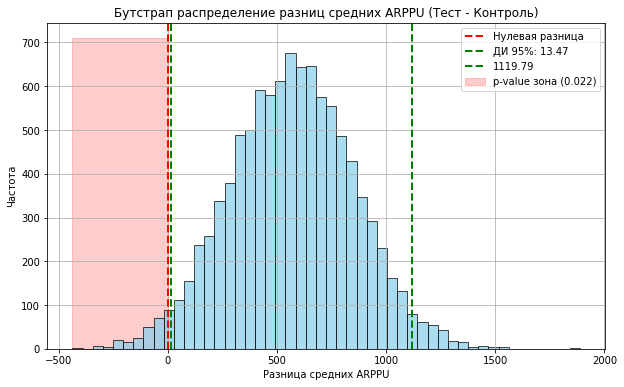

In [ ]:
# Функция бутстрапа
def bootstrap_mean_diff(data1, data2, n_bootstrap=10000, seed=42):
    np.random.seed(seed)
    diffs = []
    for _ in range(n_bootstrap):
        sample1 = np.random.choice(data1, size=len(data1), replace=True)
        sample2 = np.random.choice(data2, size=len(data2), replace=True)
        diffs.append(sample2.mean() - sample1.mean())  # тест - контроль
    return np.array(diffs)

# Получаем массивы ARPPU для групп
arppu_control = revenue_per_user[revenue_per_user['group'] == 'control']['bayer_revenue'].values
arppu_treatment = revenue_per_user[revenue_per_user['group'] == 'treatment']['bayer_revenue'].values

# Запускаем бутстрап
bootstrap_diffs = bootstrap_mean_diff(arppu_control, arppu_treatment)

# Доверительный интервал 95%
ci_lower, ci_upper = np.percentile(bootstrap_diffs, [2.5, 97.5])

# p-value (односторонняя гипотеза: тест > контроль)
p_value = (bootstrap_diffs <= 0).mean()

print(f"Среднее ARPU контроль: {arppu_control.mean():.2f}")
print(f"Среднее ARPU тест: {arppu_treatment.mean():.2f}")
print(f"Разница средних: {bootstrap_diffs.mean():.2f}")
print(f"95% ДИ: [{ci_lower:.2f}, {ci_upper:.2f}]")
print(f"p-value: {p_value:.4f}")

# ======== ВИЗУАЛИЗАЦИЯ ========
plt.figure(figsize=(10, 6))
plt.hist(bootstrap_diffs, bins=50, color='skyblue', edgecolor='black', alpha=0.7)

# Линия для нуля
plt.axvline(0, color='red', linestyle='--', linewidth=2, label='Нулевая разница')

# Доверительный интервал
plt.axvline(ci_lower, color='green', linestyle='--', linewidth=2, label=f'ДИ 95%: {ci_lower:.2f}')
plt.axvline(ci_upper, color='green', linestyle='--', linewidth=2, label=f'{ci_upper:.2f}')

# Подсветка области p-value (где diff <= 0)
plt.fill_betweenx(
    y=[0, plt.gca().get_ylim()[1]],
    x1=min(bootstrap_diffs),
    x2=0,
    color='red',
    alpha=0.2,
    label=f'p-value зона ({p_value:.3f})'
)

plt.title('Бутстрап распределение разниц средних ARPPU (Тест - Контроль)')
plt.xlabel('Разница средних ARPPU')
plt.ylabel('Частота')
plt.legend()
plt.grid(True)
plt.show()

Весь диапазон доверительных интервалов лежит выше нуля, p-value < 0,05. Разница в ARPPU между контрольной и тестовой группой статистически значима - бонус сработал.

**Проверим вспомогательную метрику - AOV** (средний чек TikTok)

**AOV**

In [ ]:
# Посчитаем средний чек по группам
# Получим выборки всех заказов по группам
aov_control = orders_users_AB[orders_users_AB['group'] == 'control']['total_price']
aov_treatment = orders_users_AB[orders_users_AB['group'] == 'treatment']['total_price']


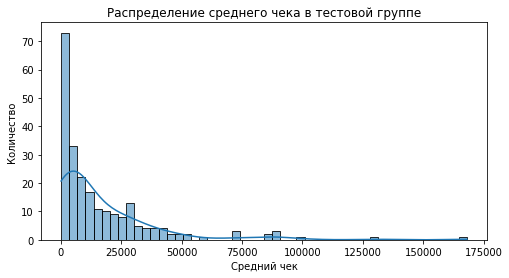

In [ ]:
plt.figure(figsize=(8, 4))
sns.histplot(aov_treatment, bins=50, alpha=0.5, edgecolor='black', kde=True)
plt.title('Распределение среднего чека в тестовой группе')
plt.xlabel('Средний чек')
plt.ylabel('Количество');

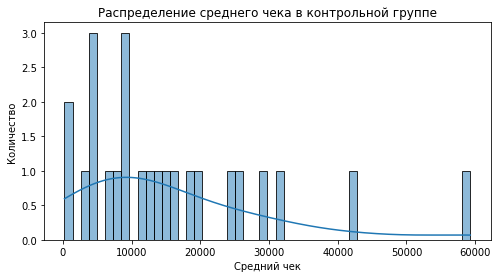

In [ ]:
plt.figure(figsize=(8, 4))
sns.histplot(aov_control, bins=50, alpha=0.5, edgecolor='black', kde=True)
plt.title('Распределение среднего чека в контрольной группе')
plt.xlabel('Средний чек')
plt.ylabel('Количество');

Данные распределены не нормально, сильно скошены. Для проверки статистической значимости отличий в среднем чеке AOV используем тест Манна-Уитни.

Проверим одностороннюю гипотезу:

- H0: ARPPU в тестовой группе не больше, чем в контрольной (бонус не влияет на метрику)
- H1: ARPPU в тестовой группе больше, чем в контрольной (бонус повышает метрику)

In [ ]:
alpha = 0.05
mw_test = mannwhitneyu(
    aov_control, # Выборка значений метрики для группы А
    aov_treatment, # Выборка значений метрики для группы B
    alternative='less' # alternative='less' соответствует альтернативной гипотезе: Dist(a)<Dist(b)
                       # alternative='greater' соответствует альтернативной гипотезе: Dist(a)>Dist(b)
)
if mw_test.pvalue > alpha:
    print(f'pvalue={mw_test.pvalue:.4e} > {alpha}')
    print('Нет статистически значимого увеличения AOV — гипотеза о различии не подтвердилась.')
else:
    print(f'pvalue={mw_test.pvalue:.4e} < {alpha}')
    print('AOV в тестовой группе статистически значимо выше — бонус сработал.')


pvalue=8.6478e-01 > 0.05
Нет статистически значимого увеличения AOV — гипотеза о различии не подтвердилась.


Введение бонуса не привело к статистически значимому увеличению AOV

**Проверим барьерную метрику - общую выручку от пользователей TikTok**

**Общая выручка от пользователей TikTok**

In [ ]:
# Считаем выручку на пользователя
total_revenue_by_group = orders_users_AB.groupby('group')['revenue'].sum()
print(total_revenue_by_group)


group
control       18918.6450
treatment    192279.8515
Name: revenue, dtype: float64


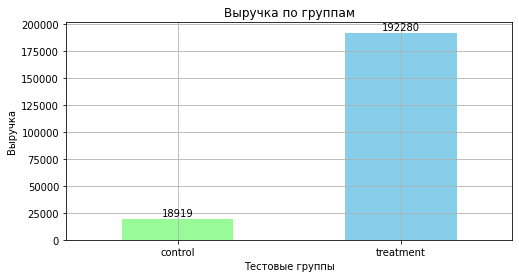

In [ ]:
# Построим столбчатую диаграмму по количеству пользователей в тестовых группах
plt.figure(figsize=(8,8))
bars = total_revenue_by_group = orders_users_AB.groupby('group')['revenue'].sum().plot(kind='bar',
               title=f'Выручка по группам',
               ylabel='Выручка',
               xlabel='Тестовые группы',
               rot=0,
               color=['palegreen', 'skyblue'],                                         
               figsize=(8, 4))
plt.grid()

# Добавим подписи над столбцами
for bar in bars.containers[0]:
    height = bar.get_height()
    bars.annotate(f'{height:.0f}', 
                  xy=(bar.get_x() + bar.get_width() / 2, height),
                  xytext=(0, 1), 
                  textcoords="offset points",
                  ha='center', va='bottom')
plt.show()

В тестовой группе выручка с канала в 10 раз больше, чем в контрольной. 

Барьерная метрика в тестовой группе не уменьшилась. 

**Спрогнозируем ROI при новом LTV после внедрения бонуса** 

In [ ]:
# LTV
# Приведем дату регистрации к периоду день
users_AB['cohort_day'] = users_AB['registration_date'].dt.to_period('D')
# Присоединим день регистрации к заказам
orders_users_AB = orders_users_AB.merge(users_AB[['user_id', 'cohort_day']], on='user_id')

# Считаем выручку по каналу Tik Tok в тестовой группе
revenue_treatment_tiktok = orders_users_AB[orders_users_AB['group'] == 'treatment']
revenue_treatment_tiktok = revenue_treatment_tiktok.groupby('cohort_day')['revenue'].sum().reset_index()

# Считаем число уникальных пользователей в тестовой группе канала Tik Tok
users_treatment_tiktok = users_AB[users_AB['group'] == 'treatment']
users_treatment_tiktok = users_treatment_tiktok.groupby('cohort_day')['user_id'].nunique().reset_index(name='users')

# считаем LTV  в тестовой группе канала Tik Tok
ltv_treatment_tiktok = pd.merge(revenue_treatment_tiktok, users_treatment_tiktok, on='cohort_day')
ltv_treatment_tiktok['ltv'] = ltv_treatment_tiktok['revenue'] / ltv_treatment_tiktok['users']

Считаем САС по каналу Tik Tok в тестовой группе постоянным, равным 340 рублей. Так как нет данных о расходах на канал за период тестирования бонуса.

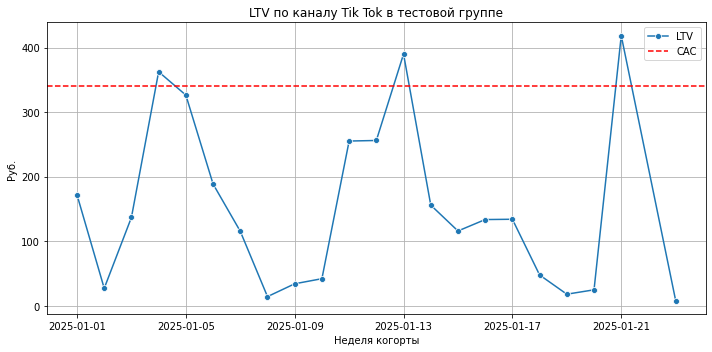

In [ ]:
ltv_treatment_tiktok['cohort_day'] = ltv_treatment_tiktok['cohort_day'].dt.to_timestamp()

plt.figure(figsize=(10, 5))
sns.lineplot(data=ltv_treatment_tiktok, x='cohort_day', y='ltv', marker='o', label='LTV')
plt.axhline(340, color='red', linestyle='--', label='CAC')
plt.title('LTV по каналу Tik Tok в тестовой группе')
plt.xlabel('Неделя когорты')
plt.ylabel('Руб.')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Считаем ROI при постоянном САС
ltv_treatment_tiktok['roi'] = (ltv_treatment_tiktok['ltv'] - 340) / 340

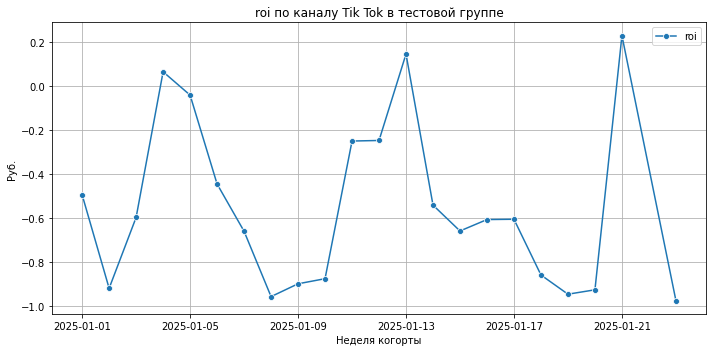

In [ ]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=ltv_treatment_tiktok, x='cohort_day', y='roi', label='roi', marker='o')
plt.title('roi по каналу Tik Tok в тестовой группе')
plt.xlabel('Неделя когорты')
plt.ylabel('Руб.')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Не смотря на значительное увеличение конверсии в покупку в канале Tik Tok, LTV в тестовой группе превышает САС только в пиковых значениях раз в неделю. При введении бонуса нужно учесть, что привлечение новых пользователей за бонус увеличит стоимость привлечения и, возможно, канал так и не выйдет на окупаемость.

**Посчитаем кумулятивную выручку по дням жизни пользователей**

In [ ]:
# Кол-во пользователей в каждой когорте (фиксированное)
cohort_users = users_AB[users_AB['group'] == 'treatment'].groupby('cohort_day')['user_id'].nunique().reset_index(name='users_total')
cohort_users['cohort_day'] = cohort_users['cohort_day'].dt.to_timestamp()
# Выручка по когортам пользователей
daily_revenue = orders_users_AB[orders_users_AB['group'] == 'treatment'].groupby(['cohort_day', 'order_date'])['revenue'].sum().reset_index()

# Дни жизни пользователя
daily_revenue['cohort_day'] = daily_revenue['cohort_day'].dt.to_timestamp()
# Приведем дату заказа к периоду день
daily_revenue['order_date'] = daily_revenue['order_date'].dt.to_period('D')
daily_revenue['order_date'] = daily_revenue['order_date'].dt.to_timestamp()

daily_revenue['days_since_reg'] = (daily_revenue['order_date'] - daily_revenue['cohort_day']).dt.days

# Кумулятивная выручка по дням жизни
daily_revenue = daily_revenue.sort_values(['cohort_day', 'order_date'])
daily_revenue['cum_revenue'] = daily_revenue.groupby('days_since_reg')['revenue'].cumsum()

# Добавляем кол-во пользователей и считаем LTV
ltv_cum = daily_revenue.merge(cohort_users, on='cohort_day')
ltv_cum['ltv_cum'] = ltv_cum['cum_revenue'] / ltv_cum['users_total']

# Средний LTV по дням жизни (агрегируем по всем когортам)
ltv_by_day = ltv_cum.groupby('days_since_reg')['ltv_cum'].mean().reset_index()

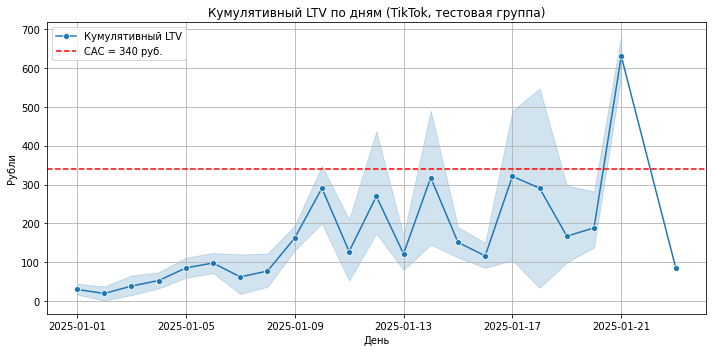

In [ ]:
# Построение графика
CAC = 340  # постоянный CAC в рублях

plt.figure(figsize=(10, 5))
sns.lineplot(data=ltv_cum, x='cohort_day', y='ltv_cum', marker='o', label='Кумулятивный LTV')
plt.axhline(CAC, color='red', linestyle='--', label=f'CAC = {CAC} руб.')
plt.title('Кумулятивный LTV по дням (TikTok, тестовая группа)')
plt.xlabel('День')
plt.ylabel('Рубли')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

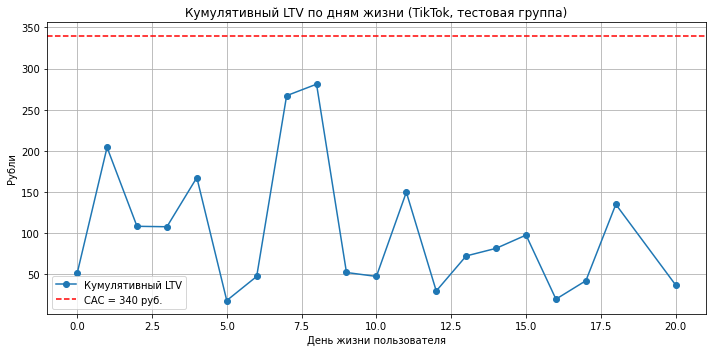

In [ ]:
# График кумулятивного LTV по дням жизни
plt.figure(figsize=(10, 5))
plt.plot(ltv_by_day['days_since_reg'], ltv_by_day['ltv_cum'], marker='o', label='Кумулятивный LTV')
plt.axhline(CAC, color='red', linestyle='--', label=f'CAC = {CAC} руб.')
plt.title('Кумулятивный LTV по дням жизни (TikTok, тестовая группа)')
plt.xlabel('День жизни пользователя')
plt.ylabel('Рубли')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Кумулятивная выручка так же не превышает САС, кроме пикового значения 21.01 после которого спад до минимума.

## Выводы по A/B тестированию

**Выводы:**

В результате введения бонуса:

- Конверсия в первую покупку статистически значимо увеличилась. Бонус эффективно стимулирует первую покупку.

- ARPU (выручка на пользователя) статистически значимо выше в тестовой группе.

- ARPPU (выручка на покупателя). Различий между группами нет — покупатели тратят столько же, просто их стало больше.

-  AOV (средний чек). Бонус не повлиял на средний чек.

- Барьерная метрика — Общая выручка не снизилась. Бонус прошёл барьерную метрику с большим запасом.



**Таким образом бонус за первую покупку для пользователей TikTok:**

- Увеличил долю покупателей (CR)

- Принёс рост выручки на пользователя (ARPU)

- Существенно увеличил общую выручку

- Не изменил поведение уже купивших пользователей (ARPPU, AOV)

**Рекомендация:**
- Масштабировать бонус или протестировать его оптимальную величину и условия.

**Проблемы в эксперименте**

- Эксперимент задуман как 3-недельный, но данные охватывают на 5 дней больше. Если в последние5 дней бонус не предоставлялся, а данные собирались, то это исказит статистику
- Начало эксперимента попало на праздничный период (1–8 января). Поведение пользователей в праздники не типичное, что так же может исказить результаты эксперимента